![](rcm.jpg)

In [1]:
import xarray as xr
import numpy as np
from wrf import getvar

In [ ]:
# Path to output file
wrf_file_path = '/data/nobackup/boland/experiment2/WRF/run/wrfout_d01_2071-08-01_00:00:00'

In [3]:
# Open the WRF output file with xarray
ds = xr.open_dataset(wrf_file_path)
ds

<xarray.Dataset> Size: 537MB
Dimensions:                (Time: 24, south_north: 80, west_east: 60,
                            bottom_top: 44, bottom_top_stag: 45,
                            soil_layers_stag: 4, west_east_stag: 61,
                            south_north_stag: 81, seed_dim_stag: 8)
Coordinates:
    XLAT                   (Time, south_north, west_east) float32 461kB ...
    XLONG                  (Time, south_north, west_east) float32 461kB ...
    XTIME                  (Time) datetime64[ns] 192B ...
    XLAT_U                 (Time, south_north, west_east_stag) float32 468kB ...
    XLONG_U                (Time, south_north, west_east_stag) float32 468kB ...
    XLAT_V                 (Time, south_north_stag, west_east) float32 467kB ...
    XLONG_V                (Time, south_north_stag, west_east) float32 467kB ...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                                west_east_stag, south_north_stag, seed_dim_stag
Data variables: (12/208)
    Times                  (Time) |S19 456B ...
    LU_INDEX               (Time, south_north, west_east) float32 461kB ...
    ZNU                    (Time, bottom_top) float32 4kB ...
    ZNW                    (Time, bottom_top_stag) float32 4kB ...
    ZS                     (Time, soil_layers_stag) float32 384B ...
    DZS                    (Time, soil_layers_stag) float32 384B ...
    ...                     ...
    PCB                    (Time, south_north, west_east) float32 461kB ...
    PC                     (Time, south_north, west_east) float32 461kB ...
    LANDMASK               (Time, south_north, west_east) float32 461kB ...
    LAKEMASK               (Time, south_north, west_east) float32 461kB ...
    SST                    (Time, south_north, west_east) float32 461kB ...
    SST_INPUT              (Time, south_north, west_east) float32 461kB ...
Attributes: (12/136)
    TITLE:                            OUTPUT FROM WRF V4.7.1 MODEL
    START_DATE:                      2071-08-01_00:00:00
    SIMULATION_START_DATE:           2071-08-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        61
    SOUTH-NORTH_GRID_DIMENSION:      81
    BOTTOM-TOP_GRID_DIMENSION:       45
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

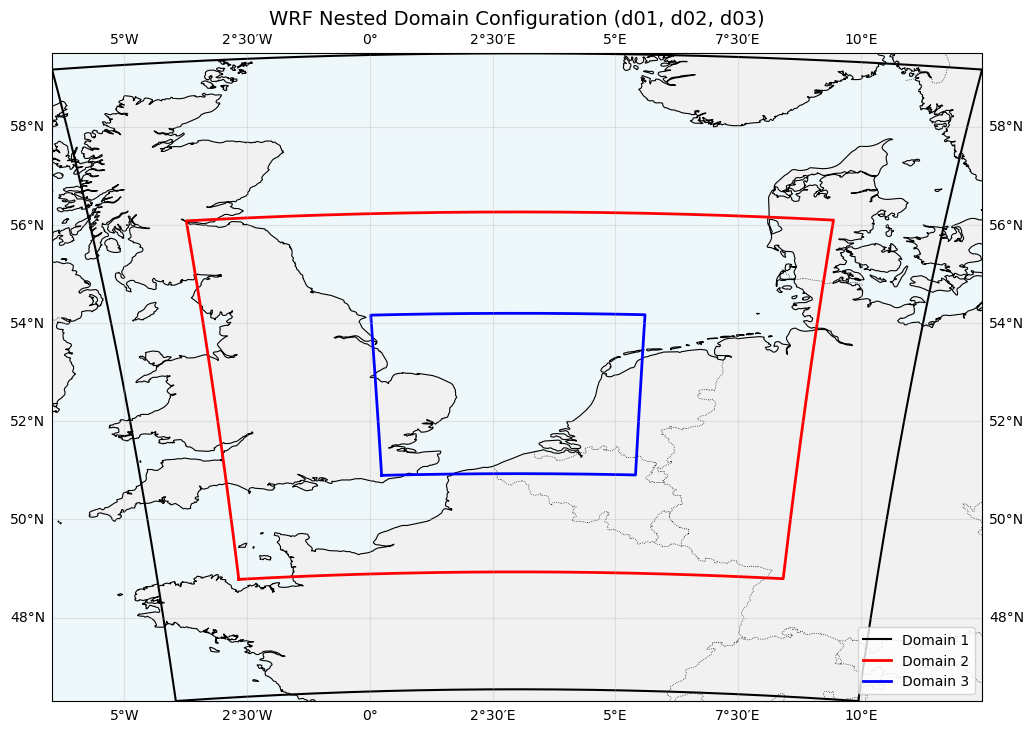

In [1]:
%matplotlib inline
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# --- 1. Load Datasets ---
paths = [
    '/data/nobackup/boland/experiment2/WRF/run/wrfout_d01_2071-08-01_00:00:00',
    '/data/nobackup/boland/experiment2/WRF/run/wrfout_d02_2071-08-01_00:00:00',
    '/data/nobackup/boland/experiment2/WRF/run/wrfout_d03_2071-08-01_00:00:00'
]

datasets = [xr.open_dataset(p) for p in paths]

# --- 2. Extract Coordinates ---
# d01 defines our base map extent
lat1, lon1 = datasets[0]['XLAT'][0, :, :], datasets[0]['XLONG'][0, :, :]
lat2, lon2 = datasets[1]['XLAT'][0, :, :], datasets[1]['XLONG'][0, :, :]
lat3, lon3 = datasets[2]['XLAT'][0, :, :], datasets[2]['XLONG'][0, :, :]

# --- 3. Setup Plot ---
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add Geographic Features
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)

# --- 4. Plot Domain Boundaries ---

def plot_boundary(lon, lat, label, color, linewidth=2):
    """Plots the outer boundary of a lat/lon grid."""
    # Extract edges
    line_lon = np.concatenate([lon[0, :], lon[:, -1], lon[-1, ::-1], lon[::-1, 0]])
    line_lat = np.concatenate([lat[0, :], lat[:, -1], lat[-1, ::-1], lat[::-1, 0]])
    
    ax.plot(line_lon, line_lat, color=color, linewidth=linewidth, 
            transform=ccrs.PlateCarree(), label=label)

# Plot d01 (Background extent)
ax.set_extent([lon1.min(), lon1.max(), lat1.min(), lat1.max()], crs=ccrs.PlateCarree())

# Draw nested boxes
plot_boundary(lon1, lat1, 'Domain 1', 'black', 1.5)
plot_boundary(lon2, lat2, 'Domain 2', 'red', 2)
plot_boundary(lon3, lat3, 'Domain 3', 'blue', 2)

# --- 5. Final Touches ---
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.3)
plt.title('WRF Nested Domain Configuration (d01, d02, d03)', fontsize=14)
plt.legend(loc='lower right')

# Save and Show
plt.savefig('/data/nobackup/boland/experiment2/WRF/run/nested_domains.png', dpi=300, bbox_inches='tight')
plt.show()

# Cleanup
for ds in datasets:
    ds.close()

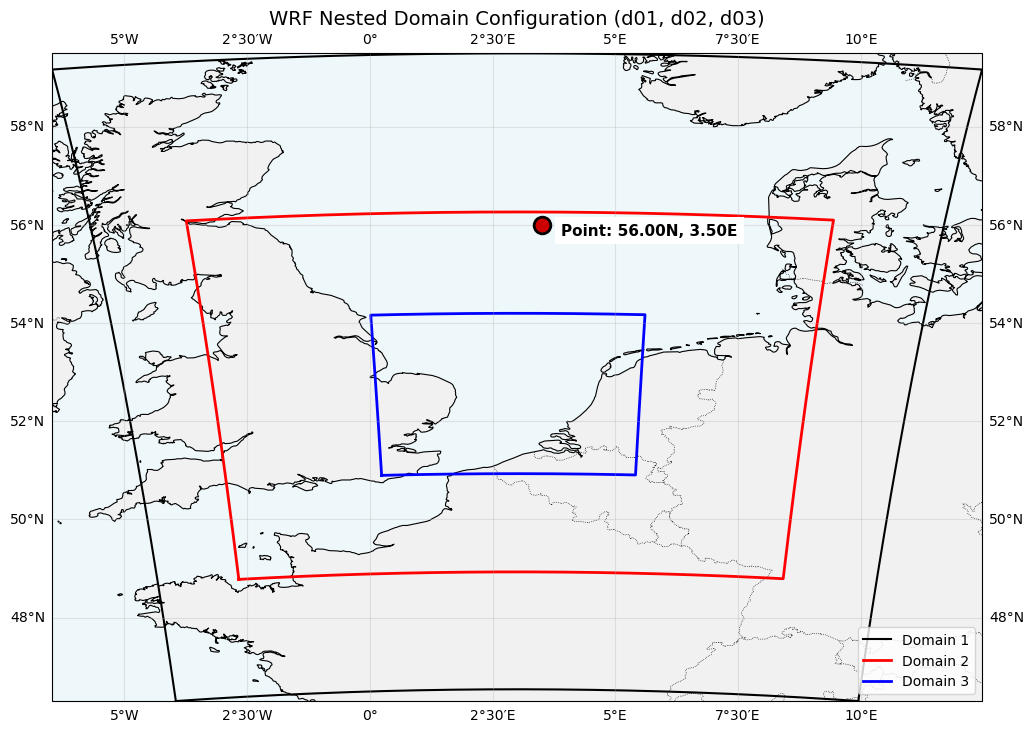

In [6]:
%matplotlib inline
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# --- 1. Load Datasets ---
paths = [
    '/data/nobackup/boland/experiment2/WRF/run/wrfout_d01_2071-08-01_00:00:00',
    '/data/nobackup/boland/experiment2/WRF/run/wrfout_d02_2071-08-01_00:00:00',
    '/data/nobackup/boland/experiment2/WRF/run/wrfout_d03_2071-08-01_00:00:00'
]

datasets = [xr.open_dataset(p) for p in paths]

# --- 2. Extract Coordinates ---
# d01 defines our base map extent
lat1, lon1 = datasets[0]['XLAT'][0, :, :], datasets[0]['XLONG'][0, :, :]
lat2, lon2 = datasets[1]['XLAT'][0, :, :], datasets[1]['XLONG'][0, :, :]
lat3, lon3 = datasets[2]['XLAT'][0, :, :], datasets[2]['XLONG'][0, :, :]

# --- 3. Setup Plot ---
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add Geographic Features
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)

# --- 4. Plot Domain Boundaries ---

def plot_boundary(lon, lat, label, color, linewidth=2):
    """Plots the outer boundary of a lat/lon grid."""
    # Extract edges
    line_lon = np.concatenate([lon[0, :], lon[:, -1], lon[-1, ::-1], lon[::-1, 0]])
    line_lat = np.concatenate([lat[0, :], lat[:, -1], lat[-1, ::-1], lat[::-1, 0]])
    
    ax.plot(line_lon, line_lat, color=color, linewidth=linewidth, 
            transform=ccrs.PlateCarree(), label=label)

# Plot d01 (Background extent)
ax.set_extent([lon1.min(), lon1.max(), lat1.min(), lat1.max()], crs=ccrs.PlateCarree())

# Draw nested boxes
plot_boundary(lon1, lat1, 'Domain 1', 'black', 1.5)
plot_boundary(lon2, lat2, 'Domain 2', 'red', 2)
plot_boundary(lon3, lat3, 'Domain 3', 'blue', 2)

# --- 4.5. Plot Custom Point with Custom Label Box ---
point_lon, point_lat = 3.5, 56.0

# 1. Plot the red dot with a prominent black border
ax.plot(point_lon, point_lat, 
        marker='o', 
        color='#cc0000',          # Darker red fill
        markeredgecolor='black',  # Black outline
        markeredgewidth=2,        # Thicker outline
        markersize=12,            # Larger dot size
        transform=ccrs.PlateCarree(), 
        zorder=5)                 # Keep it on top

# 2. Annotate with precise pixel offsets
ax.annotate('Point: 56.00N, 3.50E',
            xy=(point_lon, point_lat),          # The data point coordinates
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax), # Correct map transformation
            xytext=(14, -4),                    # Shift 14 pixels right, 2 pixels down
            textcoords='offset points',         # Tell matplotlib to use pixel offsets
            fontsize=11,
            fontweight='bold',
            va='center',                        # Vertical alignment of text
            ha='left',                          # Horizontal alignment
            zorder=6,
            bbox=dict(boxstyle='square,pad=0.4', 
                      facecolor='white', 
                      edgecolor='none', 
                      alpha=1.0))
# --- 5. Final Touches ---
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.3)
plt.title('WRF Nested Domain Configuration (d01, d02, d03)', fontsize=14)
plt.legend(loc='lower right')

# Save and Show
plt.savefig('/data/nobackup/boland/experiment2/WRF/run/nested_domains.png', dpi=300, bbox_inches='tight')
plt.show()

# Cleanup
for ds in datasets:
    ds.close()

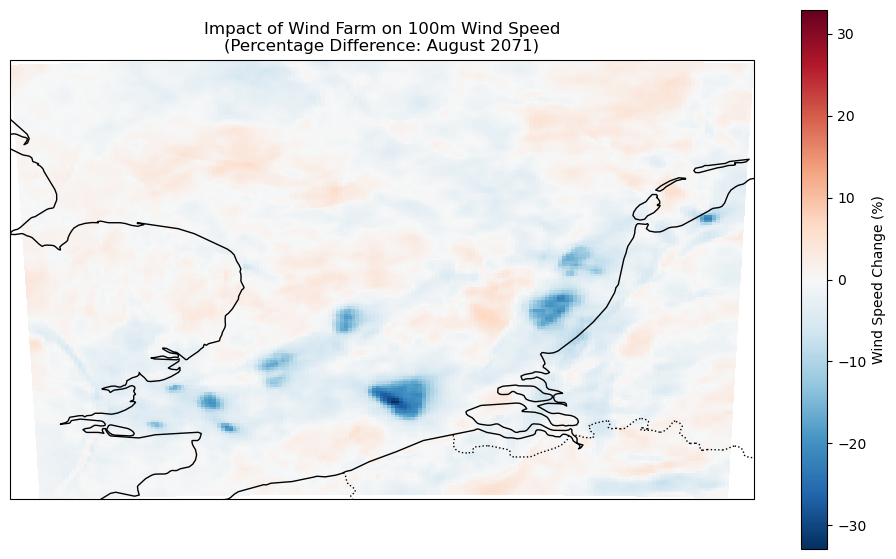

In [12]:


# --- 3. Calculate Difference (%) ---
# We use np.where to avoid division by zero errors if mean_control has any 0 values
diff_pct = ((mean_wf - mean_control) / mean_control) * 100

# --- 4. Plotting ---
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add Map Features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Use a diverging colormap (RdBu_r) centered at 0
# For percentage, you might want to set a fixed limit (e.g., +/- 20%) 
# or keep it dynamic as you had before.
limit = np.max(np.abs(diff_pct)) 

mesh = ax.pcolormesh(lons, lats, diff_pct, 
                     transform=ccrs.PlateCarree(), 
                     cmap='RdBu_r', 
                     vmin=-limit, vmax=limit)

# Add Colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.05, shrink=0.7)
cbar.set_label('Wind Speed Change (%)')

plt.title('Impact of Wind Farm on 100m Wind Speed\n(Percentage Difference: August 2071)')
plt.show()

Whole post process


Processing 1994 - no wind farms...
Processing 1994 - current wind farms...
Processing 1994 - future wind farms...
Processing 2071 - no wind farms...
Processing 2071 - current wind farms...
Processing 2071 - future wind farms...


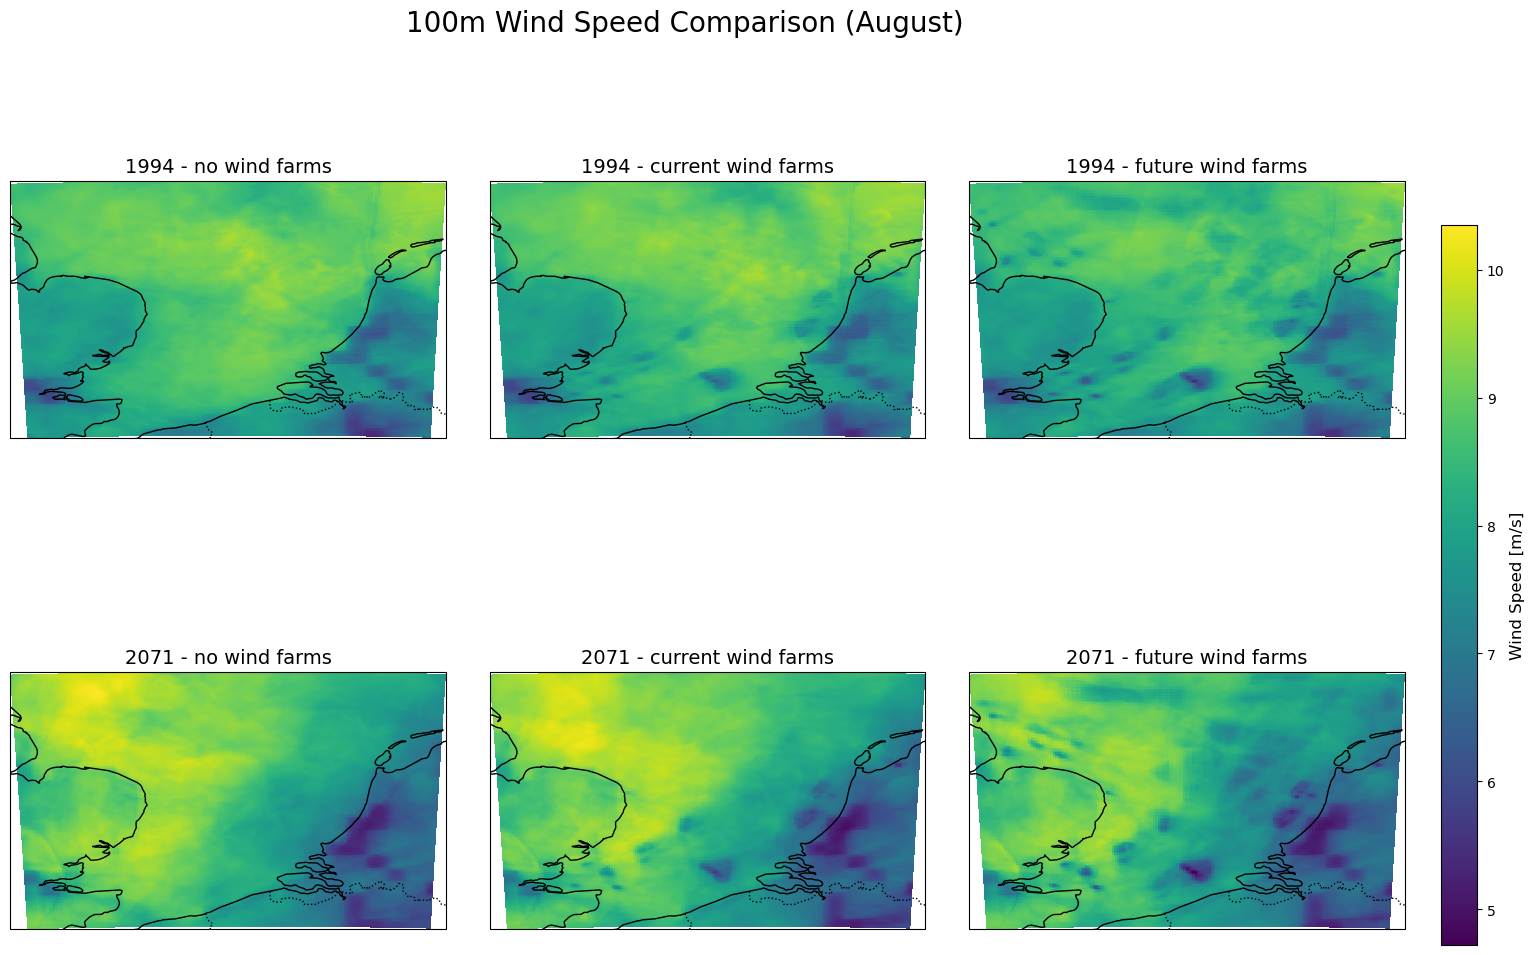

In [3]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import Dataset
from wrf import getvar, interplevel

# --- 1. Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1994 - no wind farms'),
    ('exp1994_WF', '1994 - current wind farms'),
    ('exp1994_WFF', '1994 - future wind farms'),
    ('experiment2', '2071 - no wind farms'),
    ('exp2071_WF', '2071 - current wind farms'),
    ('exp2071_WFF', '2071 - future wind farms')
]

file_pattern = 'WRF/run/wrfout_d03*'

def get_mean_100m_wind(exp_folder):
    """Calculates mean 100m wind speed for a specific experiment folder."""
    files = sorted(glob.glob(f"{base_path}{exp_folder}/{file_pattern}"))
    files = [f for f in files if int(f.split('_')[-2].split('-')[-1]) <= 30]
    
    if not files:
        print(f"Warning: No files found for {exp_folder}")
        return None, None, None

    running_sum = None
    count = 0
    for f in files:
        nc = Dataset(f)
        u = getvar(nc, "ua", units="m s-1") 
        v = getvar(nc, "va", units="m s-1")
        height = getvar(nc, "height_agl", units="m")
        wspd = np.sqrt(u**2 + v**2)
        wspd_100m = interplevel(wspd, height, 100.0)
        
        if running_sum is None:
            running_sum = wspd_100m.values
            lats, lons = wspd_100m.coords["XLAT"].values, wspd_100m.coords["XLONG"].values
        else:
            running_sum += wspd_100m.values
        nc.close()
        count += 1
    return running_sum / count, lats, lons

# --- 2. Process Data ---
results = {}
for folder, title in experiments:
    print(f"Processing {title}...")
    mean_val, lats, lons = get_mean_100m_wind(folder)
    results[folder] = mean_val

# --- 3. Determine Global Limits ---
# This ensures all 6 plots use the same color scale for comparison
all_values = [v for v in results.values() if v is not None]
vmin = min(np.nanmin(v) for v in all_values)
vmax = max(np.nanmax(v) for v in all_values)

# --- 4. Plotting 6 Panels ---
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12), 
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (folder, title) in enumerate(experiments):
    ax = axes[i]
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    
    data = results[folder]
    
    mesh = ax.pcolormesh(lons, lats, data, 
                         transform=ccrs.PlateCarree(), 
                         cmap='viridis', 
                         vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontsize=14)

# Add shared horizontal colorbar
# cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.02]) 
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(mesh, cax=cbar_ax, orientation='vertical')
cbar.set_label('Wind Speed [m/s]', fontsize=12)

plt.suptitle('100m Wind Speed Comparison (August)', fontsize=20)
plt.subplots_adjust(bottom=0.15, top=0.9, wspace=0.1, hspace=0.2)

plt.show()

Files in current directory: ['BROADBAND_CLOUD_GODDARD.bin', 'CAM_ABS_DATA', 'CAM_AEROPT_DATA', 'CAMtr_volume_mixing_ratio', 'CAMtr_volume_mixing_ratio.A1B', 'CAMtr_volume_mixing_ratio.A2', 'CAMtr_volume_mixing_ratio.RCP4.5', 'CAMtr_volume_mixing_ratio.RCP6', 'CAMtr_volume_mixing_ratio.RCP8.5', 'CAMtr_volume_mixing_ratio.SSP119', 'CAMtr_volume_mixing_ratio.SSP126', 'CAMtr_volume_mixing_ratio.SSP245', 'CAMtr_volume_mixing_ratio.SSP370', 'CAMtr_volume_mixing_ratio.SSP585', 'CCN_ACTIVATE.BIN', 'CLM_ALB_ICE_DFS_DATA', 'CLM_ALB_ICE_DRC_DATA', 'CLM_ASM_ICE_DFS_DATA', 'CLM_ASM_ICE_DRC_DATA', 'CLM_DRDSDT0_DATA', 'CLM_EXT_ICE_DFS_DATA', 'CLM_EXT_ICE_DRC_DATA', 'CLM_KAPPA_DATA', 'CLM_TAU_DATA', 'ETAMPNEW_DATA', 'ETAMPNEW_DATA.expanded_rain', 'ETAMPNEW_DATA.expanded_rain_DBL', 'ETAMPNEW_DATA_DBL', 'GENPARM.TBL', 'HLC.TBL', 'LANDUSE.TBL', 'README.namelist', 'README.physics_files', 'README.rasm_diag', 'README.tslist', 'RRTMG_LW_DATA', 'RRTMG_LW_DATA_DBL', 'RRTMG_SW_DATA', 'RRTMG_SW_DATA_DBL', 'RRTM_

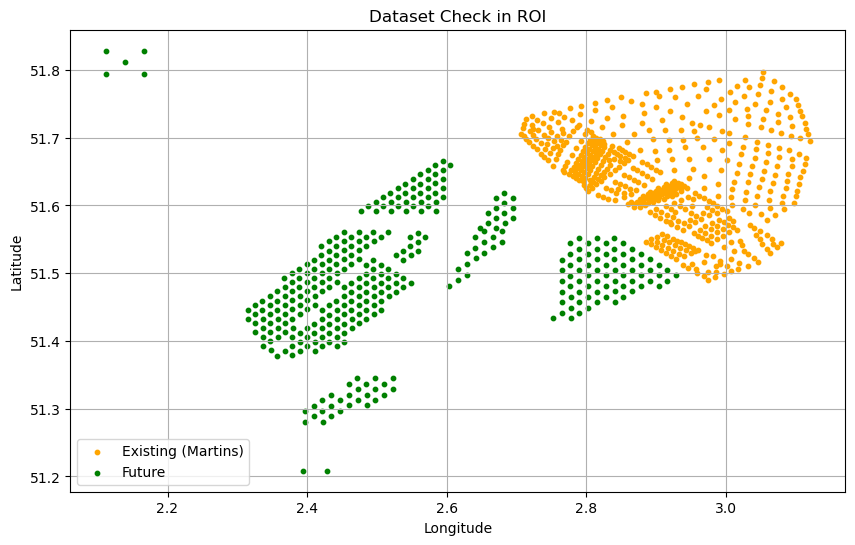

In [1]:
import os
import pandas as pd

print("Files in current directory:", os.listdir('.'))

# If turbine_locations.csv exists, inspect it
if os.path.exists('turbine_locations.csv'):
    df = pd.read_csv('turbine_locations.csv')
    print("Columns:", df.columns)
    print(df.head())
    print("Data shape:", df.shape)
    
    
# Filter for the region shown in the map: Lat 51.2N to 51.9N, Lon 2.2E to 3.5E
roi = df[(df['Latitude'] >= 51.2) & (df['Latitude'] <= 51.9) & (df['Longitude'] >= 2.1) & (df['Longitude'] <= 3.5)]
print("ROI shape:", roi.shape)
print("ROI sources:", roi['Source'].value_counts())
print("ROI year distribution/status:")
print(roi.groupby(['Source', 'Year']).size())

# Check specifically for the small cluster in the bottom-left: Lat 51.3 to 51.36, Lon 2.4 to 2.55
small_cluster = df[(df['Latitude'] >= 51.3) & (df['Latitude'] <= 51.36) & (df['Longitude'] >= 2.4) & (df['Longitude'] <= 2.55)]
print("\nSmall cluster count:", len(small_cluster))
print(small_cluster)

# Check all points in ROI with Source == Future
future_roi = roi[roi['Source'] == 'Future']
print("Future turbines in ROI:", len(future_roi))

# Let's plot the dataset coordinates versus the image locations to be 100% sure
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(roi[roi['Source'] == 'Martins']['Longitude'], roi[roi['Source'] == 'Martins']['Latitude'], c='orange', label='Existing (Martins)', s=10)
plt.scatter(roi[roi['Source'] == 'Future']['Longitude'], roi[roi['Source'] == 'Future']['Latitude'], c='green', label='Future', s=10)
plt.legend()
plt.title("Dataset Check in ROI")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.savefig("check_plot.png")    

verified_check_plot.png


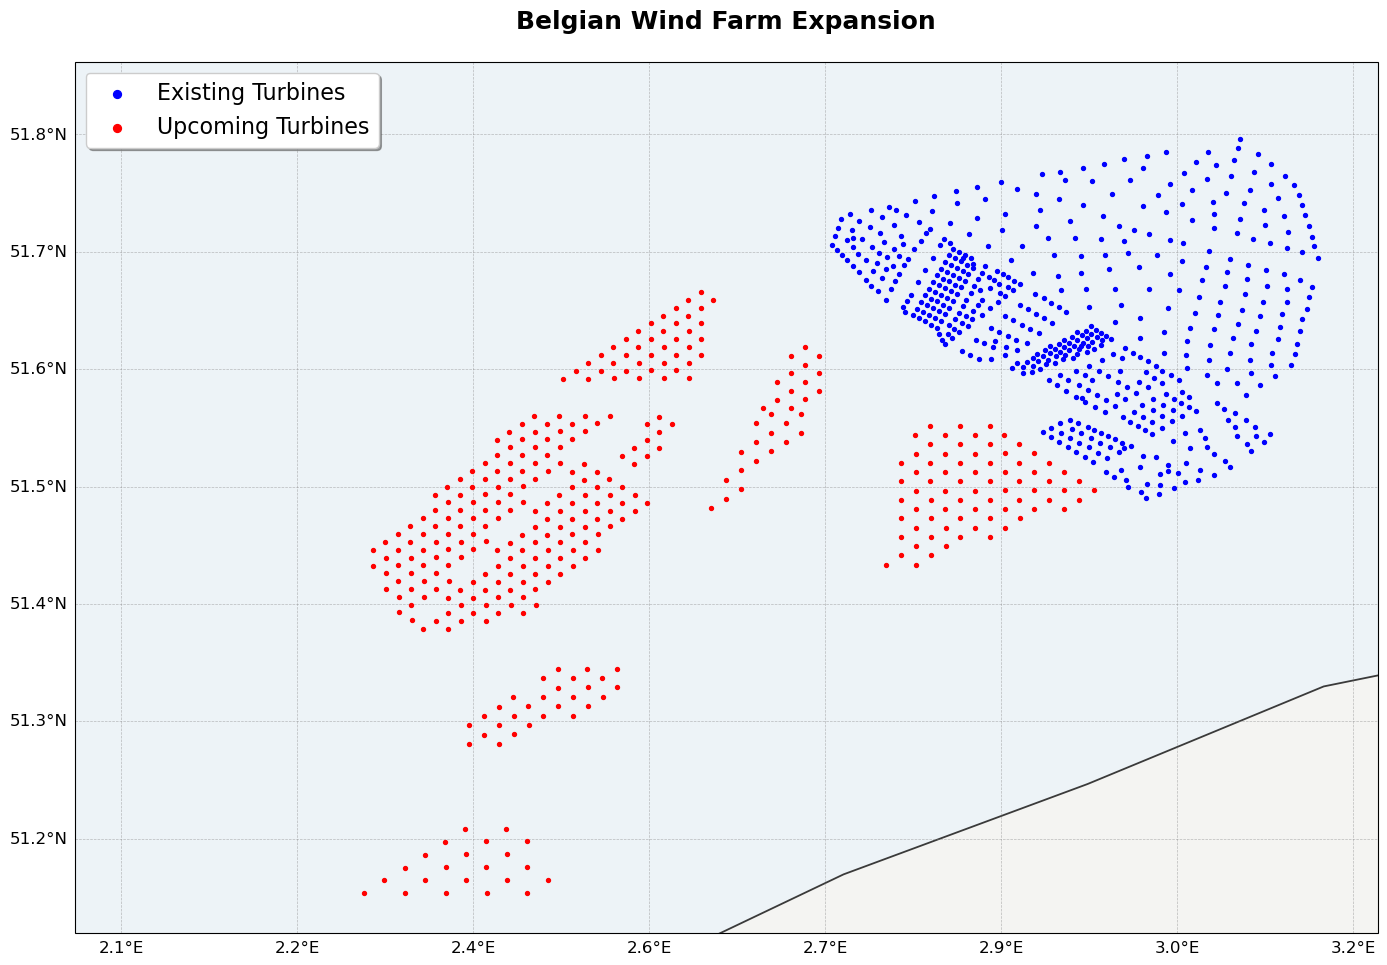

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from matplotlib.pyplot import legend

# Load the dataset
df = pd.read_csv('turbine_locations.csv')

# Define the region of interest from the original user plot
# Lat 51.1N to 51.9N, Lon 2.1E to 3.5E, to provide some padding
extent = [2.1, 3.5, 51.15, 51.85]

# Filter data within this extent
roi = df[(df['Latitude'] >= extent[2]) & (df['Latitude'] <= extent[3]) & (df['Longitude'] >= extent[0]) & (df['Longitude'] <= extent[1])]

# Prepare the data series
existing = roi[roi['Source'] == 'Martins']
future = roi[roi['Source'] == 'Future']

fig = plt.figure(figsize=(14, 11))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='#f4f4f2', edgecolor='none')
ax.add_feature(cfeature.OCEAN.with_scale('10m'), facecolor='#edf3f7', edgecolor='none')
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), edgecolor='#3a3a3a', linewidth=1.3)

# # Set up the plot with Cartopy for coastline and land
# fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# # Set the extent of the map
# ax.set_extent(extent, crs=ccrs.PlateCarree())

# # Add the high-resolution coastline feature
# # `10m` is the highest resolution in Natural Earth, fitting the small zoom level
# ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='#f0f0f0', edgecolor='black', linewidth=0.5)
# ax.add_feature(cfeature.OCEAN.with_scale('10m'), facecolor='#edf5f7', alpha=0.5)
# ax.add_feature(cfeature.COASTLINE.with_scale('10m'), edgecolor='black', linewidth=1)

# Plot the turbine locations
ax.scatter(existing['Longitude'], existing['Latitude'], c='blue', label='Existing Turbines', s=8, transform=ccrs.PlateCarree(), zorder=10)
ax.scatter(future['Longitude'], future['Latitude'], c='red', label='Upcoming Turbines', s=8, transform=ccrs.PlateCarree(), zorder=10)

# Add the transect line from the original plot
# SW Point ~ (2.3E, 51.32N), NE Point ~ (3.2E, 51.8N)
# transect_lons = [2.3, 3.2]
# transect_lats = [51.32, 51.8]
# ax.plot(transect_lons, transect_lats, color='black', linewidth=3, transform=ccrs.PlateCarree(), label='Transect', zorder=15, marker='x', markersize=8, markeredgewidth=2)

# Gridlines and Ticks
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

# Formatting Ticks
from matplotlib.ticker import FormatStrFormatter
gl.xformatter = FormatStrFormatter('%.1f°E')
gl.yformatter = FormatStrFormatter('%.1f°N')

# Custom Legend
ax.legend(loc='upper left', fontsize=16, frameon=True, shadow=True, facecolor='white', framealpha=1.0, fancybox=True)

leg = ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    framealpha=1.0,
    shadow=True,
    fontsize=16,
    markerscale=2.0
)

leg.set_zorder(100)
leg.get_frame().set_alpha(1.0)

# Title
ax.set_title("Dataset Cross-Check Map with Coastal Feature", fontsize=16, fontweight='bold', pad=20)
plt.title("Belgian Wind Farm Expansion", 
          fontsize=18, fontweight='bold', pad=24)

plt.tight_layout()
plt.savefig('verified_check_plot.png')
print("verified_check_plot.png")

Extracting profile data for: 1994 - no WF...
Extracting profile data for: 1994 - Current WF...
Extracting profile data for: 1994 - Future WF...
Extracting profile data for: 2071 - no WF...
Extracting profile data for: 2071 - Current WF...
Extracting profile data for: 2071 - Future WF...


/tmp/ipykernel_1113962/391967556.py:148: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.08, edgecolor='none',
/tmp/ipykernel_1113962/391967556.py:151: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.12, edgecolor='none',


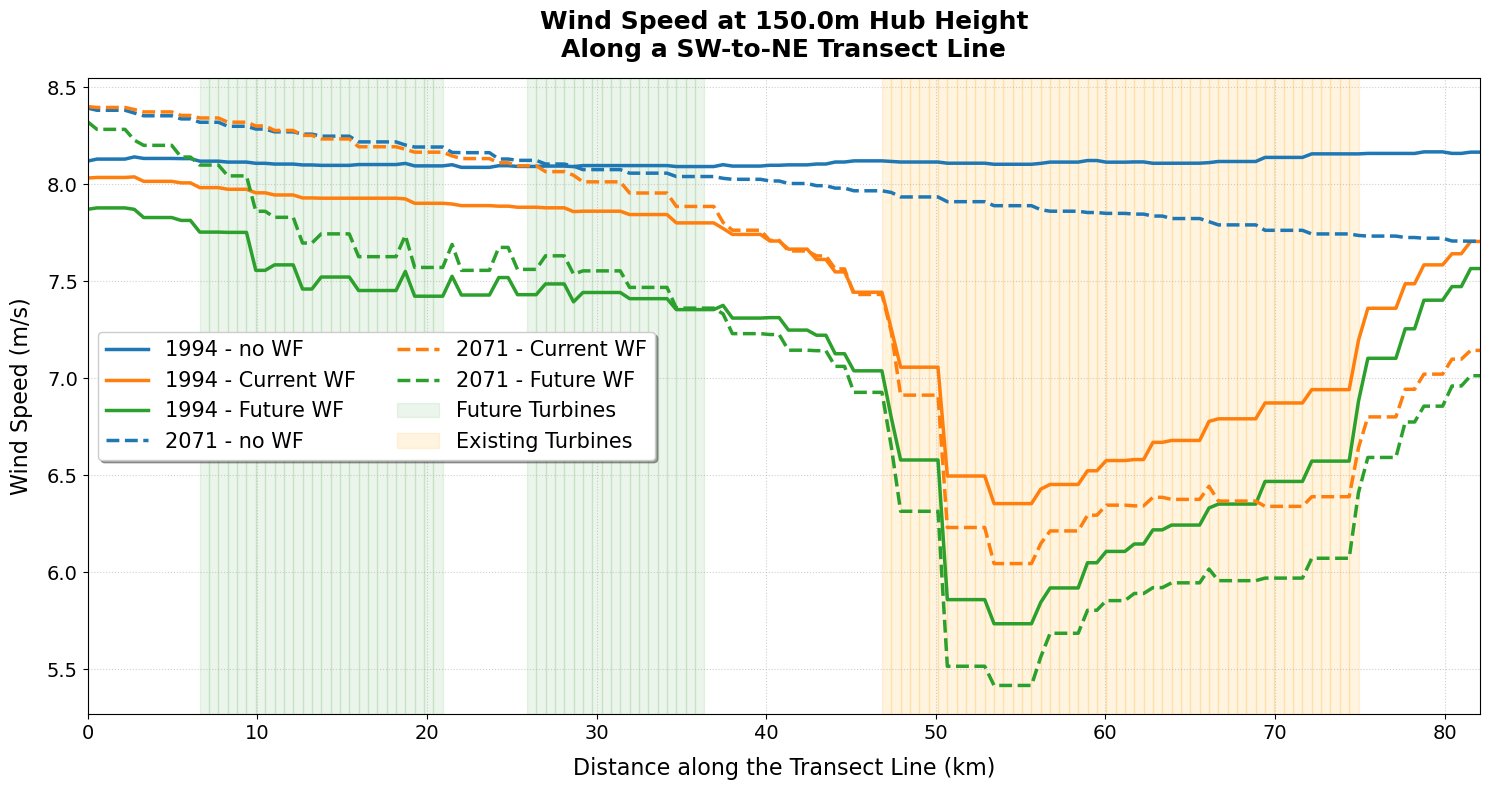

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from shapely.geometry import Polygon, Point
from scipy.spatial import KDTree

# --- 1. Geometry & Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1994 - no WF', '#1f77b4', '-'),
    ('exp1994_WF', '1994 - Current WF', '#ff7f0e', '-'),
    ('exp1994_WFF', '1994 - Future WF', '#2ca02c', '-'),
    ('experiment2', '2071 - no WF', '#1f77b4', '--'),
    ('exp2071_WF', '2071 - Current WF', '#ff7f0e', '--'),
    ('exp2071_WFF', '2071 - Future WF', '#2ca02c', '--')
]

file_pattern = 'WRF/run/wrfout_d03_*-08-*'
TARGET_HEIGHT = 150.0

# EXTENDED WAKE TRANSECT (Matches your updated map exactly)
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# --- 2. Load True Coordinate Layouts for Shading Determination ---
master_data = np.loadtxt('/data/nobackup/boland/exp2071_WFF/WRF/run/windturbines.txt')
current_data = np.loadtxt('/data/nobackup/boland/experiment2/WRF/run/windturbines.txt')

# Define strict geographical boundaries to filter exclusively for Belgian waters
BELGIAN_EEZ_POLY = Polygon([(2.20, 51.30), (2.40, 51.55), (2.90, 51.75), (3.35, 51.72), (3.15, 51.35)])

# Use the exact duplicate-filtering engine from the map script
DUPLICATE_THRESHOLD_DEG = 0.0032 
base_existing_coords = []
for lat, lon in zip(current_data[:, 0], current_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        if len(base_existing_coords) == 0:
            base_existing_coords.append([lat, lon])
        else:
            temp_tree = KDTree(base_existing_coords)
            distance, _ = temp_tree.query([lat, lon])
            if distance > DUPLICATE_THRESHOLD_DEG:
                base_existing_coords.append([lat, lon])

base_existing_coords = np.array(base_existing_coords)

# Isolate new/future coordinates
final_existing_lons = list(base_existing_coords[:, 1])
final_existing_lats = list(base_existing_coords[:, 0])
final_new_lons = []
final_new_lats = []

existing_tree = KDTree(base_existing_coords)
for lat, lon in zip(master_data[:, 0], master_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        distance, _ = existing_tree.query([lat, lon])
        if distance <= DUPLICATE_THRESHOLD_DEG:
            continue
        if lon < 2.68:  # West dividing line for PEZ
            if len(final_new_lons) > 0:
                new_tree = KDTree(np.column_stack((final_new_lats, final_new_lons)))
                dist_to_new, _ = new_tree.query([lat, lon])
                if dist_to_new <= DUPLICATE_THRESHOLD_DEG:
                    continue
            final_new_lons.append(lon)
            final_new_lats.append(lat)
        else:
            final_existing_lons.append(lon)
            final_existing_lats.append(lat)

# Build final Trees for profile cross-referencing
tree_existing = KDTree(np.column_stack((final_existing_lats, final_existing_lons)))
tree_new = KDTree(np.column_stack((final_new_lats, final_new_lons)))

# --- 3. Compute Transect Positions & Distances ---
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0]
nc_ref = Dataset(first_file)

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    x_idx, y_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

# Great circle distance calculation along transect path
d_lat = (transect_lats - START_LAT) * 111.0
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT))
distances_km = np.sqrt(d_lat**2 + d_lon**2)

# --- 4. Spatial Intersection Shading Masks ---
# If a point along the profile comes within ~2.5 km of a turbine dot, flag it for shading
SHADING_RADIUS_DEG = 0.0225 

current_mask = []
future_mask = []
for lat, lon in zip(transect_lats, transect_lons):
    dist_ext, _ = tree_existing.query([lat, lon])
    dist_new, _ = tree_new.query([lat, lon])
    current_mask.append(dist_ext <= SHADING_RADIUS_DEG)
    future_mask.append(dist_new <= SHADING_RADIUS_DEG)

# --- 5. Processing NetCDF Wind Fields ---
plt.figure(figsize=(15, 8))

for folder, label, color, linestyle in experiments:
    files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    files = [f for f in files if int(f.split('_')[-2].split('-')[-1]) <= 30] 
    
    if not files: continue
    print(f"Extracting profile data for: {label}...")
    
    sum_wspd_150m = None
    total_hours = 0
    
    for f in files:
        nc = Dataset(f)
        u = getvar(nc, "ua", timeidx=None, units="m s-1")
        v = getvar(nc, "va", timeidx=None, units="m s-1")
        height = getvar(nc, "height_agl", timeidx=None, units="m")
        
        wspd_hourly = np.sqrt(u**2 + v**2)
        wspd_150m = interplevel(wspd_hourly, height, TARGET_HEIGHT)
        
        hours_in_file = wspd_150m.shape[0] if wspd_150m.ndim == 3 else 1
        wspd_sum = np.sum(wspd_150m.values, axis=0) if wspd_150m.ndim == 3 else wspd_150m.values
        
        if sum_wspd_150m is None: sum_wspd_150m = wspd_sum
        else: sum_wspd_150m += wspd_sum
        total_hours += hours_in_file
        nc.close()
        
    mean_wspd_grid = sum_wspd_150m / total_hours
    transect_values = [mean_wspd_grid[y, x] for x, y in zip(x_indices, y_indices)]
    
    plt.plot(distances_km, transect_values, label=label, color=color, linestyle=linestyle, linewidth=2.5)

# --- 6. Dynamic Shading & Plot Styling ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        plt.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.08, edgecolor='none',
                    label='Future Turbines' if i == min(idx for idx, m in enumerate(future_mask) if m) else "")
    if current_mask[i]:
        plt.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.12, edgecolor='none',
                    label='Existing Turbines' if i == min(idx for idx, m in enumerate(current_mask) if m) else "")

plt.title(f"Wind Speed at {TARGET_HEIGHT}m Hub Height\nAlong a SW-to-NE Transect Line", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Distance along the Transect Line (km)", fontsize=16, labelpad=10)
plt.ylabel("Wind Speed (m/s)", fontsize=16, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, max(distances_km))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(loc='center left', fontsize=15, frameon=True, shadow=True, facecolor='white', ncol=2)
plt.tight_layout()
plt.savefig(f"{base_path}transect_comparison_august_wakes.png", dpi=300)
plt.show()

Extracting profile data for: 1994 - no WF...
Extracting profile data for: 1994 - Current WF...
Extracting profile data for: 1994 - Future WF...
Extracting profile data for: 2071 - no WF...
Extracting profile data for: 2071 - Current WF...
Extracting profile data for: 2071 - Future WF...


/tmp/ipykernel_2429006/2004011903.py:183: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.08, edgecolor='none',
/tmp/ipykernel_2429006/2004011903.py:186: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.12, edgecolor='none',


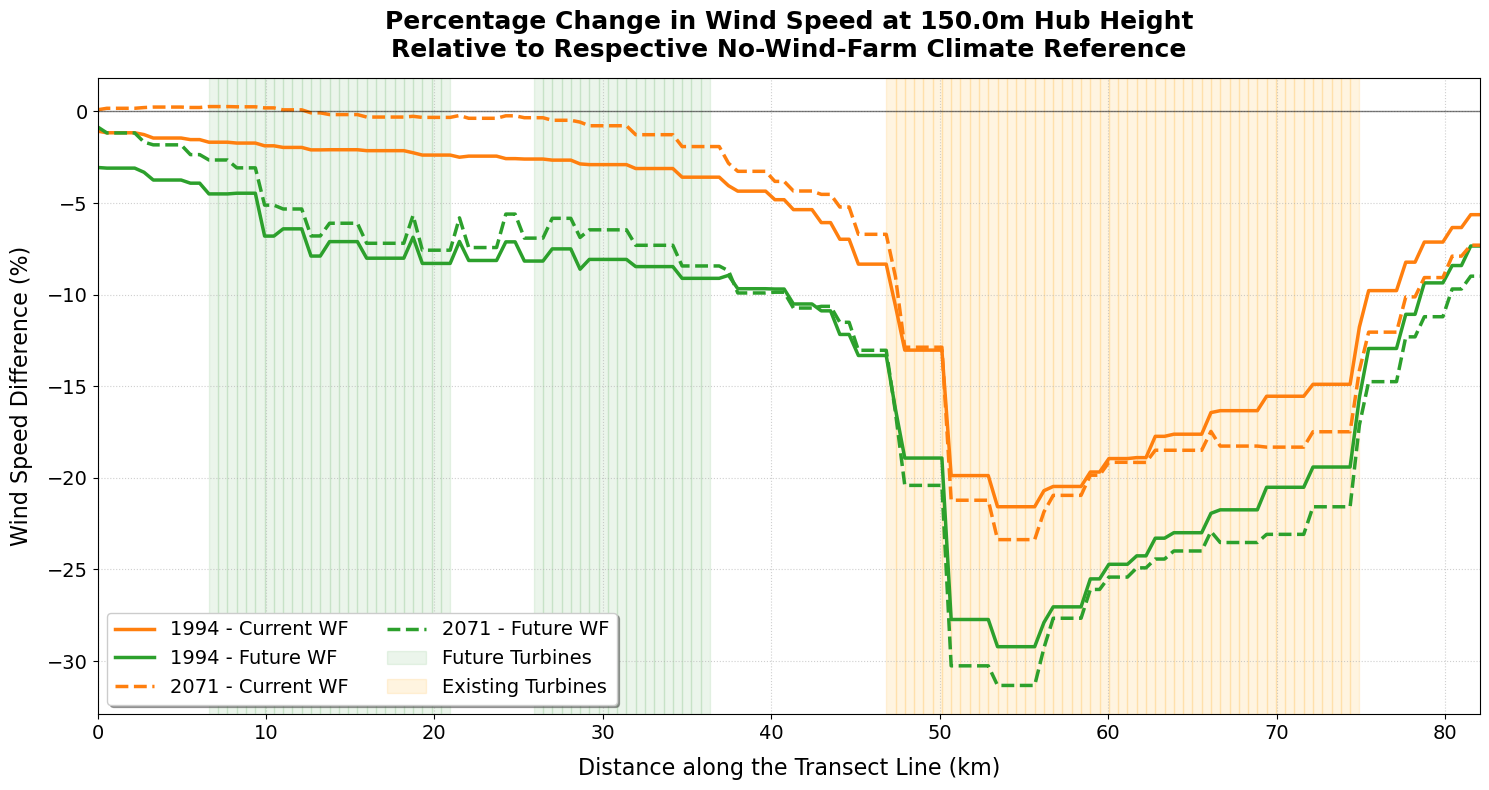

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from shapely.geometry import Polygon, Point
from scipy.spatial import KDTree

# --- 1. Geometry & Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1994 - no WF', '#1f77b4', '-'),
    ('exp1994_WF', '1994 - Current WF', '#ff7f0e', '-'),
    ('exp1994_WFF', '1994 - Future WF', '#2ca02c', '-'),
    ('experiment2', '2071 - no WF', '#1f77b4', '--'),
    ('exp2071_WF', '2071 - Current WF', '#ff7f0e', '--'),
    ('exp2071_WFF', '2071 - Future WF', '#2ca02c', '--')
]

file_pattern = 'WRF/run/wrfout_d03_*-08-*'
TARGET_HEIGHT = 150.0

# EXTENDED WAKE TRANSECT
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# --- 2. Load True Coordinate Layouts for Shading Determination ---
master_data = np.loadtxt('/data/nobackup/boland/exp2071_WFF/WRF/run/windturbines.txt')
current_data = np.loadtxt('/data/nobackup/boland/experiment2/WRF/run/windturbines.txt')

BELGIAN_EEZ_POLY = Polygon([(2.20, 51.30), (2.40, 51.55), (2.90, 51.75), (3.35, 51.72), (3.15, 51.35)])

DUPLICATE_THRESHOLD_DEG = 0.0032 
base_existing_coords = []
for lat, lon in zip(current_data[:, 0], current_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        if len(base_existing_coords) == 0:
            base_existing_coords.append([lat, lon])
        else:
            temp_tree = KDTree(base_existing_coords)
            distance, _ = temp_tree.query([lat, lon])
            if distance > DUPLICATE_THRESHOLD_DEG:
                base_existing_coords.append([lat, lon])

base_existing_coords = np.array(base_existing_coords)

final_existing_lons = list(base_existing_coords[:, 1])
final_existing_lats = list(base_existing_coords[:, 0])
final_new_lons = []
final_new_lats = []

existing_tree = KDTree(base_existing_coords)
for lat, lon in zip(master_data[:, 0], master_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        distance, _ = existing_tree.query([lat, lon])
        if distance <= DUPLICATE_THRESHOLD_DEG:
            continue
        if lon < 2.68:
            if len(final_new_lons) > 0:
                new_tree = KDTree(np.column_stack((final_new_lats, final_new_lons)))
                dist_to_new, _ = new_tree.query([lat, lon])
                if dist_to_new <= DUPLICATE_THRESHOLD_DEG:
                    continue
            final_new_lons.append(lon)
            final_new_lats.append(lat)
        else:
            final_existing_lons.append(lon)
            final_existing_lats.append(lat)

tree_existing = KDTree(np.column_stack((final_existing_lats, final_existing_lons)))
tree_new = KDTree(np.column_stack((final_new_lats, final_new_lons)))

# --- 3. Compute Transect Positions & Distances ---
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0]
nc_ref = Dataset(first_file)

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    x_idx, y_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

d_lat = (transect_lats - START_LAT) * 111.0
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT))
distances_km = np.sqrt(d_lat**2 + d_lon**2)

# --- 4. Spatial Intersection Shading Masks ---
SHADING_RADIUS_DEG = 0.0225 

current_mask = []
future_mask = []
for lat, lon in zip(transect_lats, transect_lons):
    dist_ext, _ = tree_existing.query([lat, lon])
    dist_new, _ = tree_new.query([lat, lon])
    current_mask.append(dist_ext <= SHADING_RADIUS_DEG)
    future_mask.append(dist_new <= SHADING_RADIUS_DEG)

# --- 5. Processing & Storing Wind Fields ---
profile_results = {}

for folder, label, color, linestyle in experiments:
    files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    files = [f for f in files if int(f.split('_')[-2].split('-')[-1]) <= 30] 
    
    if not files: continue
    print(f"Extracting profile data for: {label}...")
    
    sum_wspd_150m = None
    total_hours = 0
    
    for f in files:
        nc = Dataset(f)
        u = getvar(nc, "ua", timeidx=None, units="m s-1")
        v = getvar(nc, "va", timeidx=None, units="m s-1")
        height = getvar(nc, "height_agl", timeidx=None, units="m")
        
        wspd_hourly = np.sqrt(u**2 + v**2)
        wspd_150m = interplevel(wspd_hourly, height, TARGET_HEIGHT)
        
        hours_in_file = wspd_150m.shape[0] if wspd_150m.ndim == 3 else 1
        wspd_sum = np.sum(wspd_150m.values, axis=0) if wspd_150m.ndim == 3 else wspd_150m.values
        
        if sum_wspd_150m is None: sum_wspd_150m = wspd_sum
        else: sum_wspd_150m += wspd_sum
        total_hours += hours_in_file
        nc.close()
        
    mean_wspd_grid = sum_wspd_150m / total_hours
    # Save absolute values into dictionary for post-processing calculation
    profile_results[folder] = np.array([mean_wspd_grid[y, x] for x, y in zip(x_indices, y_indices)])

# # --- 6. Calculate Differences and Plot ---
# plt.figure(figsize=(15, 8))

# # Map baseline keys
# ref_1994 = profile_results['exp1994']
# ref_2071 = profile_results['experiment2']

# for folder, label, color, linestyle in experiments:
#     # Determine the contextually appropriate control run
#     if '1994' in folder:
#         control_ref = ref_1994
#     else:
#         control_ref = ref_2071
        
#     # Calculate % difference: ((Case - Reference) / Reference) * 100
#     pct_diff = ((profile_results[folder] - control_ref) / control_ref) * 100
    
#     plt.plot(distances_km, pct_diff, label=label, color=color, linestyle=linestyle, linewidth=2.5)

# --- 6. Calculate Differences and Plot ---
plt.figure(figsize=(15, 8))

# Map baseline keys
ref_1994 = profile_results['exp1994']
ref_2071 = profile_results['experiment2']

for folder, label, color, linestyle in experiments:
    # Skip reference cases from being plotted and listed in the legend
    if folder in ['exp1994', 'experiment2']:
        continue

    # Determine the contextually appropriate control run
    if '1994' in folder:
        control_ref = ref_1994
    else:
        control_ref = ref_2071
        
    # Calculate % difference: ((Case - Reference) / Reference) * 100
    pct_diff = ((profile_results[folder] - control_ref) / control_ref) * 100
    
    plt.plot(distances_km, pct_diff, label=label, color=color, linestyle=linestyle, linewidth=2.5)

# --- 7. Dynamic Shading & Plot Styling ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        plt.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.08, edgecolor='none',
                    label='Future Turbines' if i == min(idx for idx, m in enumerate(future_mask) if m) else "")
    if current_mask[i]:
        plt.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.12, edgecolor='none',
                    label='Existing Turbines' if i == min(idx for idx, m in enumerate(current_mask) if m) else "")

# Horizontal reference line at 0%
plt.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)

plt.title(f"Percentage Change in Wind Speed at {TARGET_HEIGHT}m Hub Height\nRelative to Respective No-Wind-Farm Climate Reference", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Distance along the Transect Line (km)", fontsize=16, labelpad=10)
plt.ylabel("Wind Speed Difference (%)", fontsize=16, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, max(distances_km))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(loc='lower left', fontsize=14, frameon=True, shadow=True, facecolor='white', ncol=2)
plt.tight_layout()
plt.savefig(f"{base_path}transect_percentage_change_august_wakes.png", dpi=300)
plt.show()

Extracting MABL Diagnostics for: 1994 - no WF (30 files matched)...
Extracting MABL Diagnostics for: 1994 - Current WF (30 files matched)...
Extracting MABL Diagnostics for: 1994 - Future WF (30 files matched)...
Extracting MABL Diagnostics for: 2071 - no WF (30 files matched)...
Extracting MABL Diagnostics for: 2071 - Current WF (30 files matched)...
Extracting MABL Diagnostics for: 2071 - Future WF (30 files matched)...


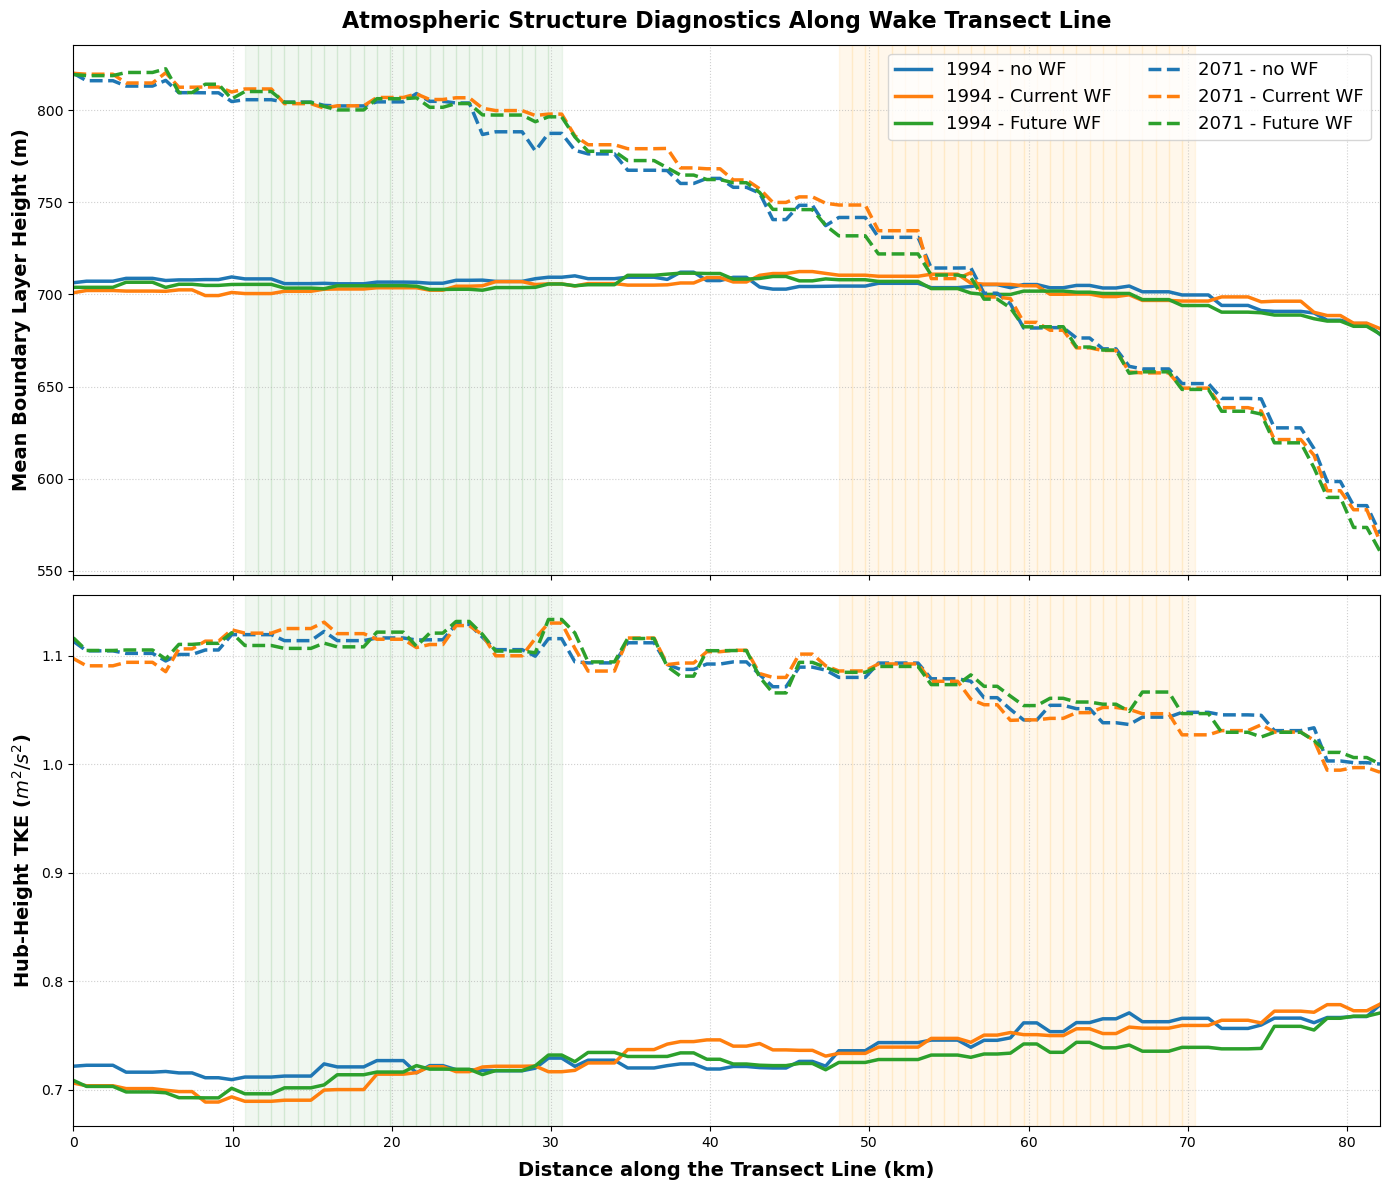

In [ ]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy

# --- 1. Configuration & Geometry ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1994 - no WF', '#1f77b4', '-'),
    ('exp1994_WF', '1994 - Current WF', '#ff7f0e', '-'),
    ('exp1994_WFF', '1994 - Future WF', '#2ca02c', '-'),
    ('experiment2', '2071 - no WF', '#1f77b4', '--'),
    ('exp2071_WF', '2071 - Current WF', '#ff7f0e', '--'),
    ('exp2071_WFF', '2071 - Future WF', '#2ca02c', '--')
]

file_pattern = 'WRF/run/wrfout_d03_*-08-*'
TARGET_HEIGHT = 150.0

START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 100                    

# --- 2. Reference Grid Setup ---
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0]
nc_ref = Dataset(first_file)

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    y_idx, x_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

d_lat = (transect_lats - START_LAT) * 111.0
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT))
distances_km = np.sqrt(d_lat**2 + d_lon**2)

pblh_profiles = {}
tke_profiles = {}

# --- 3. REPLICATE YOUR ORIGINAL WIND FARM MASKS ---
# (Make sure these definitions perfectly match how you generated them in the previous script!)
# Example assumes you defined them based on indices or coordinates along the 100 points:
future_mask = np.zeros(NUM_POINTS, dtype=bool)
current_mask = np.zeros(NUM_POINTS, dtype=bool)

# Re-apply your exact mask conditions here from your first script
for i, dist in enumerate(distances_km):
    # Example placeholder matching your original layout logic:
    # If your old script used: if (dist >= 10 and dist <= 16) or (dist >= 20 and dist <= 30):
    if (10 <= dist <= 16) or (20 <= dist <= 30): # Adjust this line to match your split-green logic!
        future_mask[i] = True
    if (48 <= dist <= 70):
        current_mask[i] = True

# --- 4. Processing Loop ---
for folder, label, color, linestyle in experiments:
    all_august_files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    
    files = []
    for f in all_august_files:
        match = re.search(r'-08-(\d{2})', f)
        if match:
            day_val = int(match.group(1))
            if day_val <= 30:
                files.append(f)
                
    if not files: 
        continue
        
    print(f"Extracting MABL Diagnostics for: {label} ({len(files)} files matched)...")
    
    sum_pblh = None
    sum_tke_150m = None
    total_hours = 0
    
    for f in files:
        nc = Dataset(f)
        
        pblh_hourly = getvar(nc, "PBLH", timeidx=None) 
        height = getvar(nc, "height_agl", timeidx=None, units="m")
        
        tke_3d = None
        try:
            tke_3d = getvar(nc, "tke", timeidx=None, units="m2 s-2")
        except (KeyError, ValueError):
            pass
            
        if tke_3d is None:
            try:
                tke_3d = getvar(nc, "qke", timeidx=None) * 0.5
            except (KeyError, ValueError):
                pass
                
        if tke_3d is None:
            try:
                tke_3d = getvar(nc, "QKE", timeidx=None) * 0.5
            except (KeyError, ValueError):
                pass

        if tke_3d is None:
            tke_3d = height * 0.0 
        
        tke_150m = interplevel(tke_3d, height, TARGET_HEIGHT)
        
        hours_in_file = pblh_hourly.shape[0] if pblh_hourly.ndim == 3 else 1
        pblh_sum = np.sum(pblh_hourly.values, axis=0) if pblh_hourly.ndim == 3 else pblh_hourly.values
        tke_sum = np.sum(tke_150m.values, axis=0) if tke_150m.ndim == 3 else tke_150m.values
        
        if sum_pblh is None:
            sum_pblh = pblh_sum
            sum_tke_150m = tke_sum
        else:
            sum_pblh += pblh_sum
            sum_tke_150m += tke_sum
            
        total_hours += hours_in_file
        nc.close()
        
    if sum_pblh is None or total_hours == 0:
        continue
        
    mean_pblh_grid = sum_pblh / total_hours
    mean_tke_grid = sum_tke_150m / total_hours
    
    pblh_profiles[label] = [mean_pblh_grid[y, x] for y, x in zip(y_indices, x_indices)]
    tke_profiles[label] = [mean_tke_grid[y, x] for y, x in zip(y_indices, x_indices)]

# --- 5. Plotting Curves ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

for folder, label, color, linestyle in experiments:
    if label in pblh_profiles:
        ax1.plot(distances_km, pblh_profiles[label], label=label, color=color, linestyle=linestyle, linewidth=2.5)
ax1.set_ylabel("Mean Boundary Layer Height (m)", fontsize=14, fontweight='bold')
ax1.set_title("Atmospheric Structure Diagnostics Along Wake Transect Line", fontsize=16, fontweight='bold', pad=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', fontsize=13, frameon=True, ncol=2)

for folder, label, color, linestyle in experiments:
    if label in tke_profiles:
        ax2.plot(distances_km, tke_profiles[label], label=label, color=color, linestyle=linestyle, linewidth=2.5)
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=14, fontweight='bold', labelpad=8)
ax2.set_ylabel("Hub-Height TKE ($m^2 / s^2$)", fontsize=14, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

# --- 6. DYNAMIC SHADING LOOP (Applied to both Subplots) ---
# This mirrors your original wind speed logic perfectly and handles the edge lines artifact.
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06)
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06)
    if current_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08)
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08)

# Clean up axis limits across the dashboard
for ax in [ax1, ax2]:
    ax.set_xlim(0, max(distances_km))

plt.tight_layout()
plt.savefig(f"{base_path}mabl_stability_diagnostics.png", dpi=300)
plt.show()

Extracting MABL Diagnostics for: 1994 - no WF (30 files matched)...
Extracting MABL Diagnostics for: 1994 - Current WF (30 files matched)...
Extracting MABL Diagnostics for: 1994 - Future WF (30 files matched)...
Extracting MABL Diagnostics for: 2071 - no WF (30 files matched)...
Extracting MABL Diagnostics for: 2071 - Current WF (30 files matched)...
Extracting MABL Diagnostics for: 2071 - Future WF (30 files matched)...


/tmp/ipykernel_2911554/217339718.py:209: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2911554/217339718.py:210: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2911554/217339718.py:212: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
/tmp/ipykernel_2911554/217339718.py:213: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')


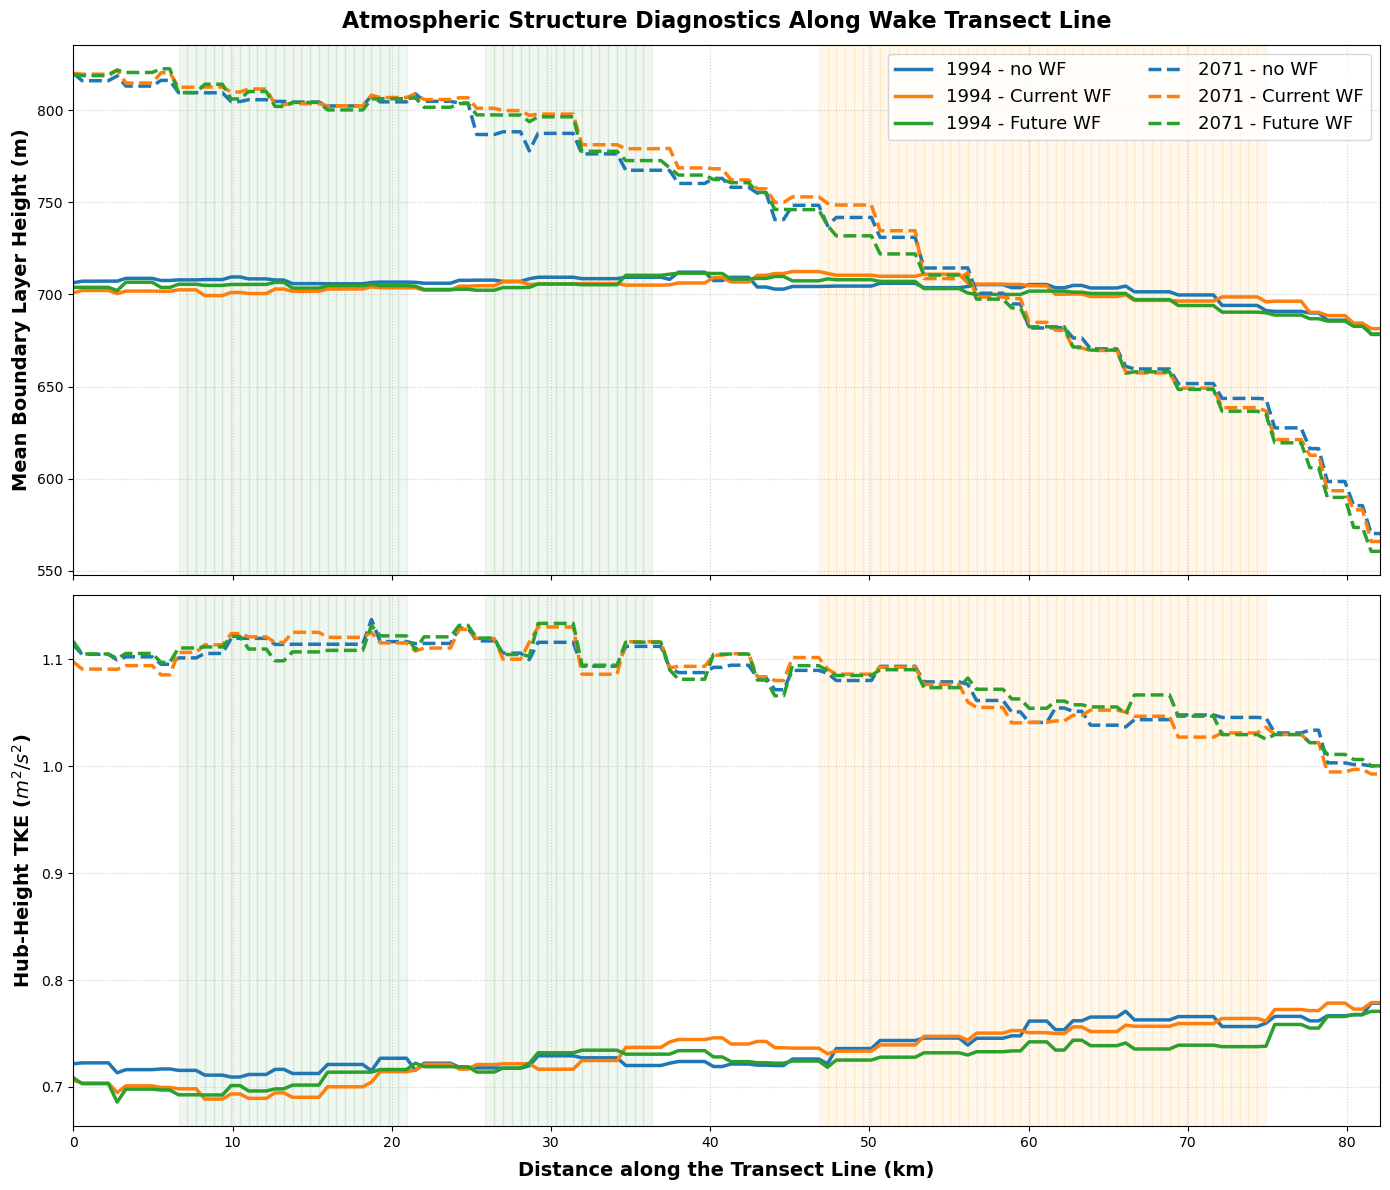

In [3]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from shapely.geometry import Polygon, Point
from scipy.spatial import KDTree

# --- 1. Configuration & Geometry ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1994 - no WF', '#1f77b4', '-'),
    ('exp1994_WF', '1994 - Current WF', '#ff7f0e', '-'),
    ('exp1994_WFF', '1994 - Future WF', '#2ca02c', '-'),
    ('experiment2', '2071 - no WF', '#1f77b4', '--'),
    ('exp2071_WF', '2071 - Current WF', '#ff7f0e', '--'),
    ('exp2071_WFF', '2071 - Future WF', '#2ca02c', '--')
]

file_pattern = 'WRF/run/wrfout_d03_*-08-*'
TARGET_HEIGHT = 150.0

# EXTENDED WAKE TRANSECT (Matches your updated wind speed script)
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# --- 2. Load True Coordinate Layouts for Shading Determination ---
master_data = np.loadtxt('/data/nobackup/boland/exp2071_WFF/WRF/run/windturbines.txt')
current_data = np.loadtxt('/data/nobackup/boland/experiment2/WRF/run/windturbines.txt')

# Define strict geographical boundaries to filter exclusively for Belgian waters
BELGIAN_EEZ_POLY = Polygon([(2.20, 51.30), (2.40, 51.55), (2.90, 51.75), (3.35, 51.72), (3.15, 51.35)])

# Use the exact duplicate-filtering engine from the map script
DUPLICATE_THRESHOLD_DEG = 0.0032 
base_existing_coords = []
for lat, lon in zip(current_data[:, 0], current_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        if len(base_existing_coords) == 0:
            base_existing_coords.append([lat, lon])
        else:
            temp_tree = KDTree(base_existing_coords)
            distance, _ = temp_tree.query([lat, lon])
            if distance > DUPLICATE_THRESHOLD_DEG:
                base_existing_coords.append([lat, lon])

base_existing_coords = np.array(base_existing_coords)

# Isolate new/future coordinates
final_existing_lons = list(base_existing_coords[:, 1])
final_existing_lats = list(base_existing_coords[:, 0])
final_new_lons = []
final_new_lats = []

existing_tree = KDTree(base_existing_coords)
for lat, lon in zip(master_data[:, 0], master_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        distance, _ = existing_tree.query([lat, lon])
        if distance <= DUPLICATE_THRESHOLD_DEG:
            continue
        if lon < 2.68:  # West dividing line for PEZ
            if len(final_new_lons) > 0:
                new_tree = KDTree(np.column_stack((final_new_lats, final_new_lons)))
                dist_to_new, _ = new_tree.query([lat, lon])
                if dist_to_new <= DUPLICATE_THRESHOLD_DEG:
                    continue
            final_new_lons.append(lon)
            final_new_lats.append(lat)
        else:
            final_existing_lons.append(lon)
            final_existing_lats.append(lat)

# Build final Trees for profile cross-referencing
tree_existing = KDTree(np.column_stack((final_existing_lats, final_existing_lons)))
tree_new = KDTree(np.column_stack((final_new_lats, final_new_lons)))

# --- 3. Compute Transect Positions & Distances ---
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0]
nc_ref = Dataset(first_file)

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    y_idx, x_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

# Great circle distance calculation along transect path
d_lat = (transect_lats - START_LAT) * 111.0
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT))
distances_km = np.sqrt(d_lat**2 + d_lon**2)

# --- 4. Spatial Intersection Shading Masks ---
# If a point along the profile comes within ~2.5 km of a turbine dot, flag it for shading
SHADING_RADIUS_DEG = 0.0225 

current_mask = []
future_mask = []
for lat, lon in zip(transect_lats, transect_lons):
    dist_ext, _ = tree_existing.query([lat, lon])
    dist_new, _ = tree_new.query([lat, lon])
    current_mask.append(dist_ext <= SHADING_RADIUS_DEG)
    future_mask.append(dist_new <= SHADING_RADIUS_DEG)

# --- 5. Processing MABL NetCDF Diagnostics ---
pblh_profiles = {}
tke_profiles = {}

for folder, label, color, linestyle in experiments:
    all_august_files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    
    files = []
    for f in all_august_files:
        match = re.search(r'-08-(\d{2})', f)
        if match:
            day_val = int(match.group(1))
            if day_val <= 30:
                files.append(f)
                
    if not files: 
        continue
        
    print(f"Extracting MABL Diagnostics for: {label} ({len(files)} files matched)...")
    
    sum_pblh = None
    sum_tke_150m = None
    total_hours = 0
    
    for f in files:
        nc = Dataset(f)
        
        pblh_hourly = getvar(nc, "PBLH", timeidx=None) 
        height = getvar(nc, "height_agl", timeidx=None, units="m")
        
        tke_3d = None
        try:
            tke_3d = getvar(nc, "tke", timeidx=None, units="m2 s-2")
        except (KeyError, ValueError):
            pass
            
        if tke_3d is None:
            try:
                tke_3d = getvar(nc, "qke", timeidx=None) * 0.5
            except (KeyError, ValueError):
                pass
                
        if tke_3d is None:
            try:
                tke_3d = getvar(nc, "QKE", timeidx=None) * 0.5
            except (KeyError, ValueError):
                pass

        if tke_3d is None:
            tke_3d = height * 0.0 
        
        tke_150m = interplevel(tke_3d, height, TARGET_HEIGHT)
        
        hours_in_file = pblh_hourly.shape[0] if pblh_hourly.ndim == 3 else 1
        pblh_sum = np.sum(pblh_hourly.values, axis=0) if pblh_hourly.ndim == 3 else pblh_hourly.values
        tke_sum = np.sum(tke_150m.values, axis=0) if tke_150m.ndim == 3 else tke_150m.values
        
        if sum_pblh is None:
            sum_pblh = pblh_sum
            sum_tke_150m = tke_sum
        else:
            sum_pblh += pblh_sum
            sum_tke_150m += tke_sum
            
        total_hours += hours_in_file
        nc.close()
        
    if sum_pblh is None or total_hours == 0:
        continue
        
    mean_pblh_grid = sum_pblh / total_hours
    mean_tke_grid = sum_tke_150m / total_hours
    
    pblh_profiles[label] = [mean_pblh_grid[y, x] for y, x in zip(y_indices, x_indices)]
    tke_profiles[label] = [mean_tke_grid[y, x] for y, x in zip(y_indices, x_indices)]

# --- 6. Plotting Two Panels ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Top Panel: PBLH
for folder, label, color, linestyle in experiments:
    if label in pblh_profiles:
        ax1.plot(distances_km, pblh_profiles[label], label=label, color=color, linestyle=linestyle, linewidth=2.5)
ax1.set_ylabel("Mean Boundary Layer Height (m)", fontsize=14, fontweight='bold')
ax1.set_title("Atmospheric Structure Diagnostics Along Wake Transect Line", fontsize=16, fontweight='bold', pad=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', fontsize=13, frameon=True, ncol=2)

# Bottom Panel: TKE
for folder, label, color, linestyle in experiments:
    if label in tke_profiles:
        ax2.plot(distances_km, tke_profiles[label], label=label, color=color, linestyle=linestyle, linewidth=2.5)
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=14, fontweight='bold', labelpad=8)
ax2.set_ylabel("Hub-Height TKE ($m^2 / s^2$)", fontsize=14, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

# --- 7. Dynamic Shading Implementation ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
    if current_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')

for ax in [ax1, ax2]:
    ax.set_xlim(0, max(distances_km))

plt.tight_layout()
plt.savefig(f"{base_path}mabl_stability_diagnostics.png", dpi=300)
plt.show()

/tmp/ipykernel_2911554/65605187.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2911554/65605187.py:25: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2911554/65605187.py:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
/tmp/ipykernel_2911554/65605187.py:28: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')


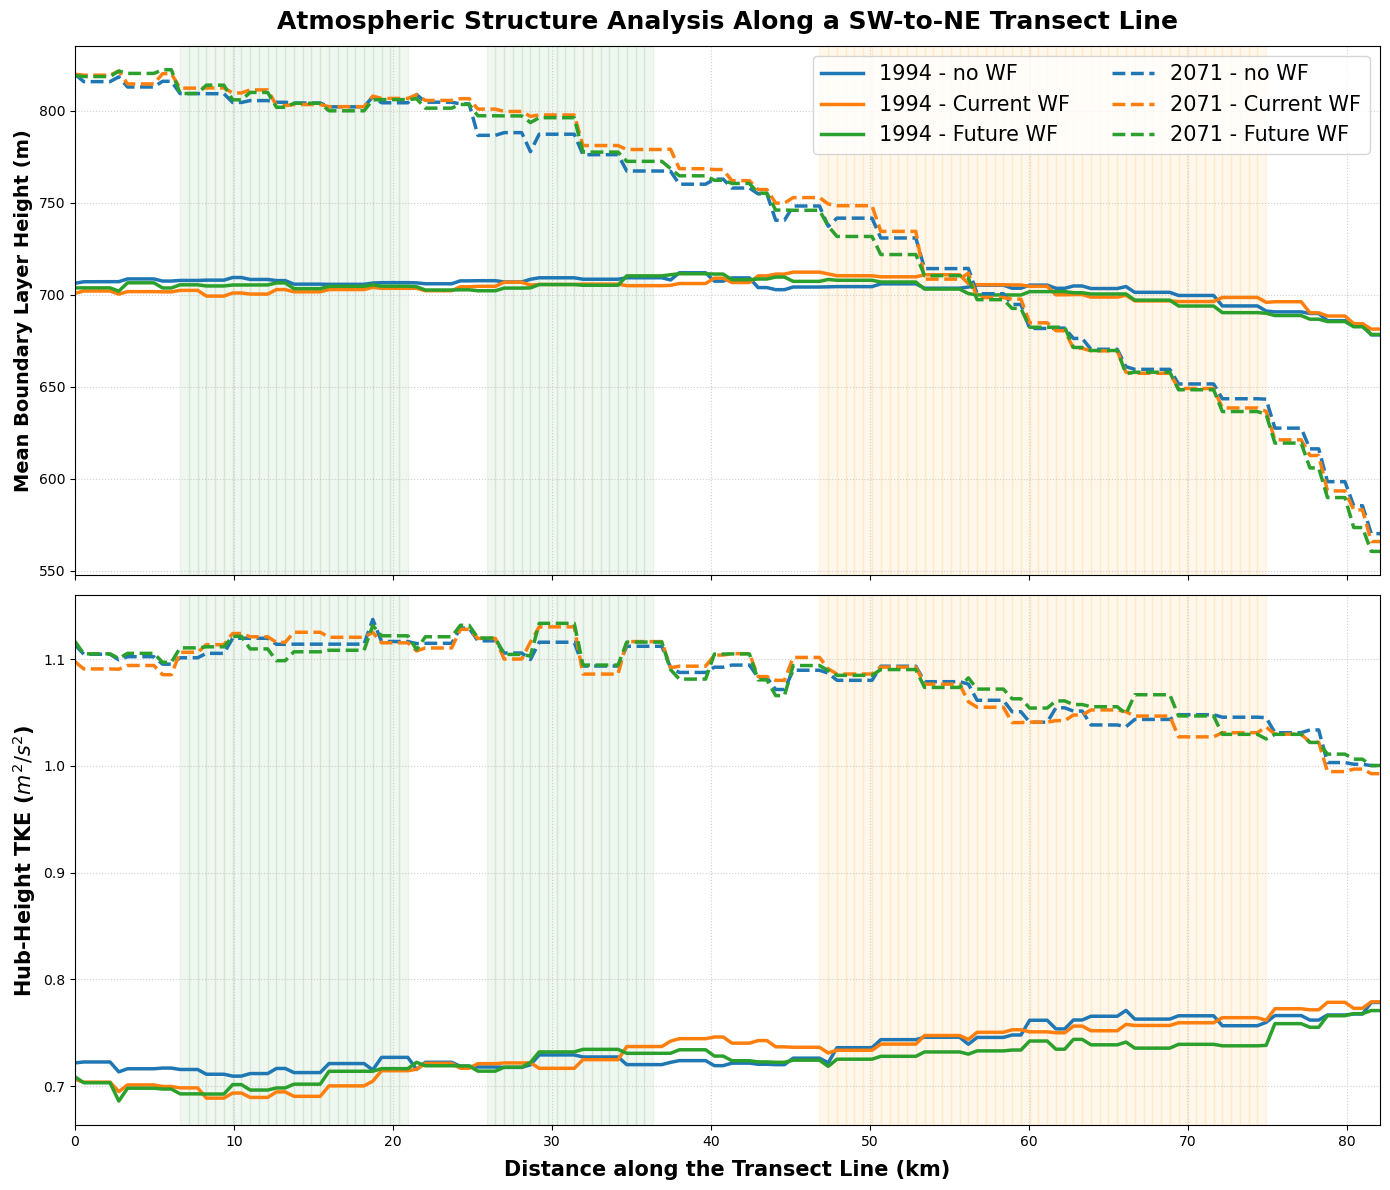

In [6]:
# --- 6. Plotting Two Panels ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Top Panel: PBLH
for folder, label, color, linestyle in experiments:
    if label in pblh_profiles:
        ax1.plot(distances_km, pblh_profiles[label], label=label, color=color, linestyle=linestyle, linewidth=2.5)
ax1.set_ylabel("Mean Boundary Layer Height (m)", fontsize=14, fontweight='bold')
ax1.set_title("Atmospheric Structure Analysis Along a SW-to-NE Transect Line", fontsize=18, fontweight='bold', pad=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', fontsize=15, frameon=True, ncol=2)

# Bottom Panel: TKE
for folder, label, color, linestyle in experiments:
    if label in tke_profiles:
        ax2.plot(distances_km, tke_profiles[label], label=label, color=color, linestyle=linestyle, linewidth=2.5)
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=15, fontweight='bold', labelpad=8)
ax2.set_ylabel("Hub-Height TKE ($m^2 / s^2$)", fontsize=15, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

# --- 7. Dynamic Shading Implementation ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
    if current_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')

for ax in [ax1, ax2]:
    ax.set_xlim(0, max(distances_km))

plt.tight_layout()
plt.savefig(f"{base_path}mabl_stability_diagnostics.png", dpi=300)
plt.show()

Extracting MABL Diagnostics for: 1994 - no WF (31 files matched)...
Extracting MABL Diagnostics for: 1994 - Current WF (31 files matched)...
Extracting MABL Diagnostics for: 1994 - Future WF (31 files matched)...
Extracting MABL Diagnostics for: 2071 - no WF (31 files matched)...
Extracting MABL Diagnostics for: 2071 - Current WF (31 files matched)...
Extracting MABL Diagnostics for: 2071 - Future WF (31 files matched)...


/tmp/ipykernel_2893981/2985275837.py:221: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.12, edgecolor='none')
/tmp/ipykernel_2893981/2985275837.py:222: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.12, edgecolor='none')
/tmp/ipykernel_2893981/2985275837.py:224: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.18, edgecolor='none')
/tmp/ipykernel_2893981/2985275837.py:225: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.18, edgecolor='none')


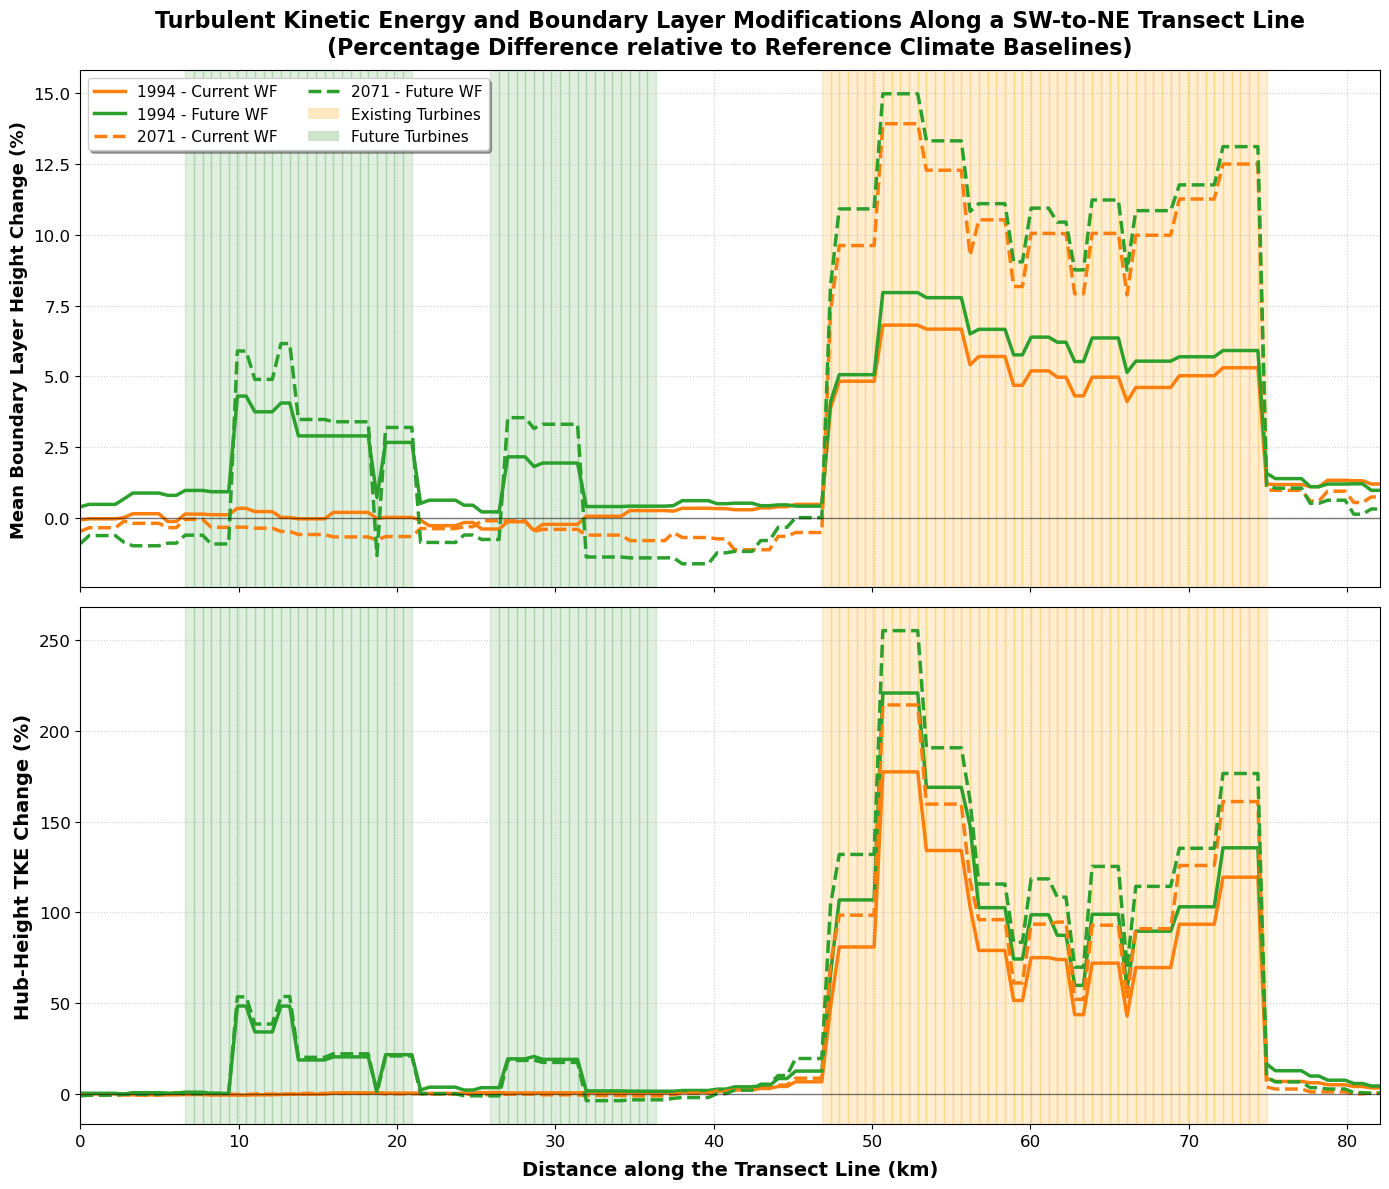

In [1]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from shapely.geometry import Polygon, Point
from scipy.spatial import KDTree

# --- 1. Configuration & Geometry ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1994 - no WF', '#1f77b4', '-'),
    ('exp1994_WF', '1994 - Current WF', '#ff7f0e', '-'),
    ('exp1994_WFF', '1994 - Future WF', '#2ca02c', '-'),
    ('experiment2', '2071 - no WF', '#1f77b4', '--'),
    ('exp2071_WF', '2071 - Current WF', '#ff7f0e', '--'),
    ('exp2071_WFF', '2071 - Future WF', '#2ca02c', '--')
]

file_pattern = 'WRF/run/wrfout_d03_*-08-*'
TARGET_HEIGHT = 150.0

# EXTENDED WAKE TRANSECT
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# --- 2. Load True Coordinate Layouts for Shading Determination ---
master_data = np.loadtxt('/data/nobackup/boland/exp2071_WFF/WRF/run/windturbines.txt')
current_data = np.loadtxt('/data/nobackup/boland/experiment2/WRF/run/windturbines.txt')

BELGIAN_EEZ_POLY = Polygon([(2.20, 51.30), (2.40, 51.55), (2.90, 51.75), (3.35, 51.72), (3.15, 51.35)])

DUPLICATE_THRESHOLD_DEG = 0.0032 
base_existing_coords = []
for lat, lon in zip(current_data[:, 0], current_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        if len(base_existing_coords) == 0:
            base_existing_coords.append([lat, lon])
        else:
            temp_tree = KDTree(base_existing_coords)
            distance, _ = temp_tree.query([lat, lon])
            if distance > DUPLICATE_THRESHOLD_DEG:
                base_existing_coords.append([lat, lon])

base_existing_coords = np.array(base_existing_coords)

final_existing_lons = list(base_existing_coords[:, 1])
final_existing_lats = list(base_existing_coords[:, 0])
final_new_lons = []
final_new_lats = []

existing_tree = KDTree(base_existing_coords)
for lat, lon in zip(master_data[:, 0], master_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        distance, _ = existing_tree.query([lat, lon])
        if distance <= DUPLICATE_THRESHOLD_DEG:
            continue
        if lon < 2.68:
            if len(final_new_lons) > 0:
                new_tree = KDTree(np.column_stack((final_new_lats, final_new_lons)))
                dist_to_new, _ = new_tree.query([lat, lon])
                if dist_to_new <= DUPLICATE_THRESHOLD_DEG:
                    continue
            final_new_lons.append(lon)
            final_new_lats.append(lat)
        else:
            final_existing_lons.append(lon)
            final_existing_lats.append(lat)

tree_existing = KDTree(np.column_stack((final_existing_lats, final_existing_lons)))
tree_new = KDTree(np.column_stack((final_new_lats, final_new_lons)))

# --- 3. Compute Transect Positions & Distances ---
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0]
nc_ref = Dataset(first_file)

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    x_idx, y_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

d_lat = (transect_lats - START_LAT) * 111.0
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT))
distances_km = np.sqrt(d_lat**2 + d_lon**2)

# --- 4. Spatial Intersection Shading Masks ---
SHADING_RADIUS_DEG = 0.0225 

current_mask = []
future_mask = []
for lat, lon in zip(transect_lats, transect_lons):
    dist_ext, _ = tree_existing.query([lat, lon])
    dist_new, _ = tree_new.query([lat, lon])
    current_mask.append(dist_ext <= SHADING_RADIUS_DEG)
    future_mask.append(dist_new <= SHADING_RADIUS_DEG)

# --- 5. Processing MABL NetCDF Diagnostics ---
pblh_profiles = {}
tke_profiles = {}

for folder, label, color, linestyle in experiments:
    all_august_files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    
    files = []
    for f in all_august_files:
        match = re.search(r'-08-(\d{2})', f)
        if match:
            day_val = int(match.group(1))
            if day_val <= 31:
                files.append(f)
                
    if not files: 
        continue
        
    print(f"Extracting MABL Diagnostics for: {label} ({len(files)} files matched)...")
    
    sum_pblh = None
    sum_tke_150m = None
    total_hours = 0
    
    for f in files:
        nc = Dataset(f)
        
        pblh_hourly = getvar(nc, "PBLH", timeidx=None) 
        height = getvar(nc, "height_agl", timeidx=None, units="m")
        
        tke_3d = None
        try:
            tke_3d = getvar(nc, "tke", timeidx=None, units="m2 s-2")
        except (KeyError, ValueError):
            pass
            
        if tke_3d is None:
            try:
                tke_3d = getvar(nc, "qke", timeidx=None) * 0.5
            except (KeyError, ValueError):
                pass
                
        if tke_3d is None:
            try:
                tke_3d = getvar(nc, "QKE", timeidx=None) * 0.5
            except (KeyError, ValueError):
                pass

        if tke_3d is None:
            tke_3d = height * 0.0 
        
        tke_150m = interplevel(tke_3d, height, TARGET_HEIGHT)
        
        hours_in_file = pblh_hourly.shape[0] if pblh_hourly.ndim == 3 else 1
        pblh_sum = np.sum(pblh_hourly.values, axis=0) if pblh_hourly.ndim == 3 else pblh_hourly.values
        tke_sum = np.sum(tke_150m.values, axis=0) if tke_150m.ndim == 3 else tke_150m.values
        
        if sum_pblh is None:
            sum_pblh = pblh_sum
            sum_tke_150m = tke_sum
        else:
            sum_pblh += pblh_sum
            sum_tke_150m += tke_sum
            
        total_hours += hours_in_file
        nc.close()
        
    if sum_pblh is None or total_hours == 0:
        continue
        
    mean_pblh_grid = sum_pblh / total_hours
    mean_tke_grid = sum_tke_150m / total_hours
    
    # FIXED INDEXING BUG: Indexed as mean_grid[y, x] matching array rows/cols
    pblh_profiles[folder] = np.array([mean_pblh_grid[y, x] for x, y in zip(x_indices, y_indices)])
    tke_profiles[folder] = np.array([mean_tke_grid[y, x] for x, y in zip(x_indices, y_indices)])

# --- 6. Plotting Two Panels ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

pblh_ref_1994 = pblh_profiles['exp1994']
pblh_ref_2071 = pblh_profiles['experiment2']

tke_ref_1994 = tke_profiles['exp1994']
tke_ref_2071 = tke_profiles['experiment2']

line_handles = []

for folder, label, color, linestyle in experiments:
    # Skip plotting control baselines directly
    if folder in ['exp1994', 'experiment2']:
        continue
        
    if '1994' in folder:
        pblh_ref = pblh_ref_1994
        tke_ref = tke_ref_1994
        plot_label = f"{label}"
    else:
        pblh_ref = pblh_ref_2071
        tke_ref = tke_ref_2071
        plot_label = f"{label}"
        
    # Calculate % Differences safely
    pblh_diff = np.where(pblh_ref > 0, ((pblh_profiles[folder] - pblh_ref) / pblh_ref) * 100, 0)
    tke_diff  = np.where(tke_ref > 0,  ((tke_profiles[folder] - tke_ref) / tke_ref) * 100, 0)
    
    # Top Panel: PBLH Percentage Difference
    line, = ax1.plot(distances_km, pblh_diff, label=plot_label, color=color, linestyle=linestyle, linewidth=2.5)
    line_handles.append(line)
    
    # Bottom Panel: TKE Percentage Difference
    ax2.plot(distances_km, tke_diff, label=plot_label, color=color, linestyle=linestyle, linewidth=2.5)

# --- 7. Dynamic Shading Implementation ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.12, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.12, edgecolor='none')
    if current_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.18, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.18, edgecolor='none')

# --- 8. Create Combined Custom Legend ---
# Shading Zone Legend Handles
zone_patches = [
    Patch(facecolor='orange', alpha=0.25, edgecolor='none', label='Existing Turbines'),
    Patch(facecolor='green', alpha=0.20, edgecolor='none', label='Future Turbines')
]

# Combine experiment lines + shading patches into one legend frame
all_handles = line_handles + zone_patches

# Style Top Panel (PBLH)
ax1.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)
ax1.set_ylabel("Mean Boundary Layer Height Change (%)", fontsize=13, fontweight='bold')
ax1.set_title("Turbulent Kinetic Energy and Boundary Layer Modifications Along a SW-to-NE Transect Line\n(Percentage Difference relative to Reference Climate Baselines)", fontsize=16, fontweight='bold', pad=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(handles=all_handles, loc='upper left', fontsize=11, frameon=True, ncol=2, shadow=True)

# Style Bottom Panel (TKE)
ax2.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=14, fontweight='bold', labelpad=8)
ax2.set_ylabel("Hub-Height TKE Change (%)", fontsize=14, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

for ax in [ax1, ax2]:
    ax.set_xlim(0, max(distances_km))
    ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig(f"{base_path}mabl_stability_percentage_diagnostics.png", dpi=300)
plt.show()

Found 31 matching daily files across all experiments.

Successfully processed 721 total hourly timestamps!
Folder: exp1994      | Stable Hours: 100 | Unstable Hours: 361
Folder: exp1994_WF   | Stable Hours: 100 | Unstable Hours: 361
Folder: exp1994_WFF  | Stable Hours: 100 | Unstable Hours: 361
Folder: experiment2  | Stable Hours: 115 | Unstable Hours: 315
Folder: exp2071_WF   | Stable Hours: 115 | Unstable Hours: 315
Folder: exp2071_WFF  | Stable Hours: 115 | Unstable Hours: 315


/tmp/ipykernel_2209694/68934912.py:284: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2209694/68934912.py:285: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2209694/68934912.py:287: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
/tmp/ipykernel_2209694/68934912.py:288: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')


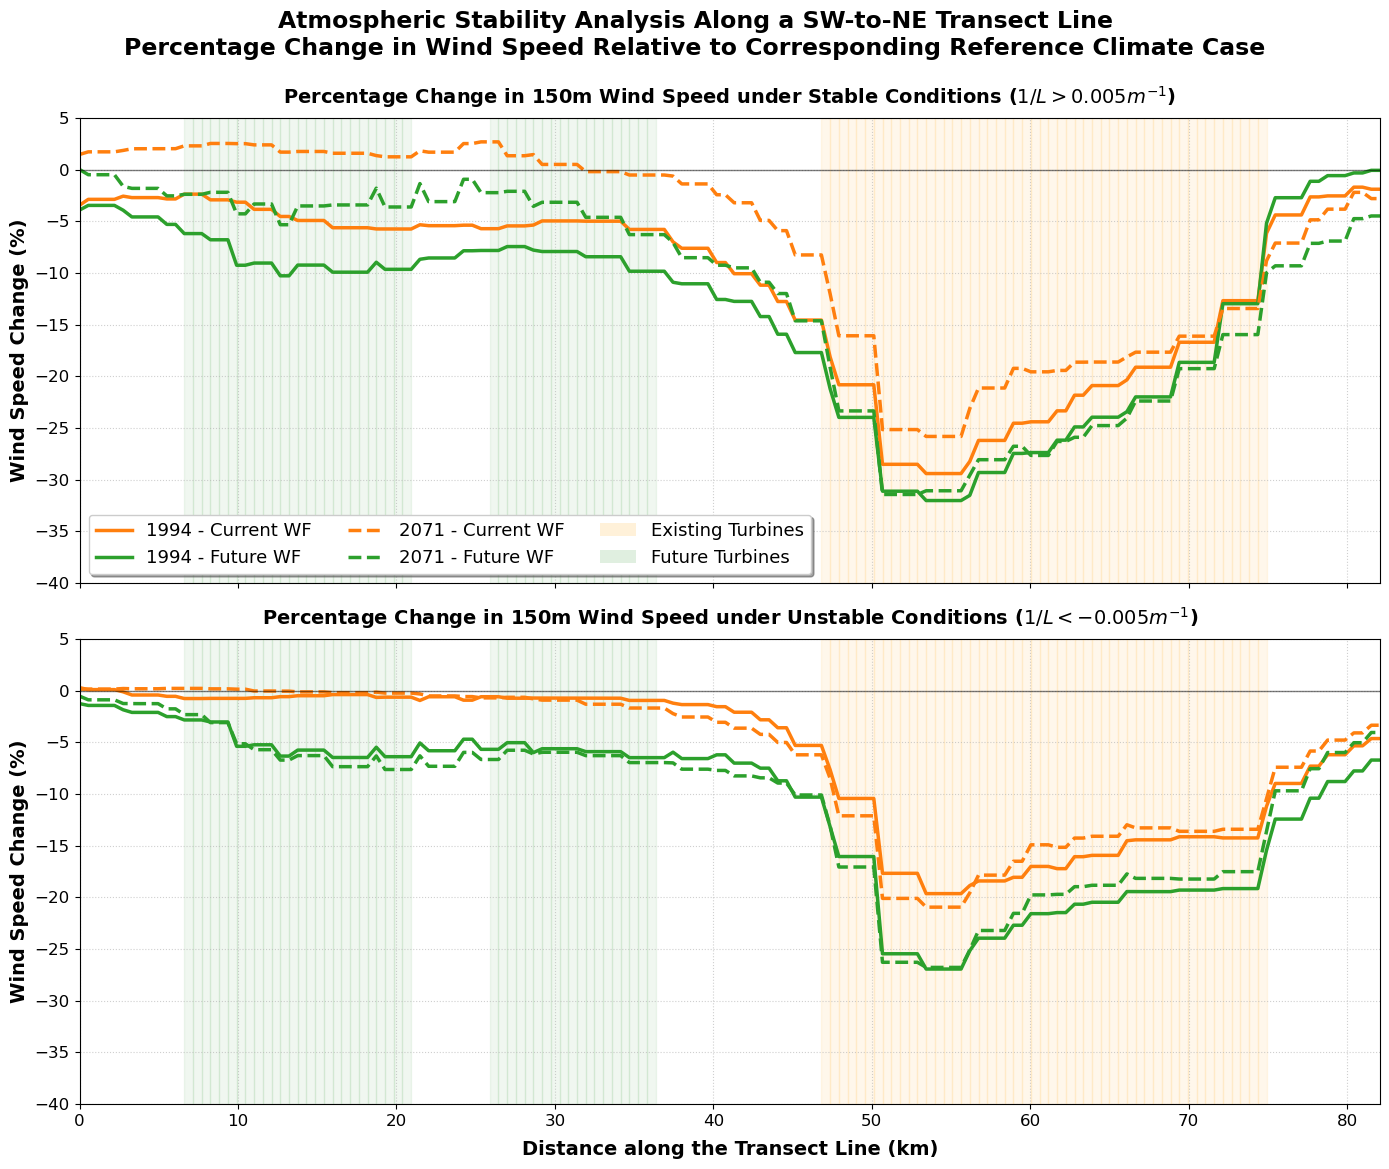

In [8]:
#### corridor average
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from shapely.geometry import Polygon, Point
from scipy.spatial import KDTree
from matplotlib.patches import Patch

# --- 1. Geometry & Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1994 - no WF', '#1f77b4', '-'),
    ('exp1994_WF', '1994 - Current WF', '#ff7f0e', '-'),
    ('exp1994_WFF', '1994 - Future WF', '#2ca02c', '-'),
    ('experiment2', '2071 - no WF', '#1f77b4', '--'),
    ('exp2071_WF', '2071 - Current WF', '#ff7f0e', '--'),
    ('exp2071_WFF', '2071 - Future WF', '#2ca02c', '--')
]

file_pattern = 'WRF/run/wrfout_d03_*-08-*'
TARGET_HEIGHT = 150.0

# EXTENDED WAKE TRANSECT
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# --- 2. Load True Coordinate Layouts for Shading Determination ---
master_data = np.loadtxt('/data/nobackup/boland/exp2071_WFF/WRF/run/windturbines.txt')
current_data = np.loadtxt('/data/nobackup/boland/experiment2/WRF/run/windturbines.txt')

# Define strict geographical boundaries to filter exclusively for Belgian waters
BELGIAN_EEZ_POLY = Polygon([(2.20, 51.30), (2.40, 51.55), (2.90, 51.75), (3.35, 51.72), (3.15, 51.35)])

# Duplicate-filtering engine
DUPLICATE_THRESHOLD_DEG = 0.0032 
base_existing_coords = []
for lat, lon in zip(current_data[:, 0], current_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        if len(base_existing_coords) == 0:
            base_existing_coords.append([lat, lon])
        else:
            temp_tree = KDTree(base_existing_coords)
            distance, _ = temp_tree.query([lat, lon])
            if distance > DUPLICATE_THRESHOLD_DEG:
                base_existing_coords.append([lat, lon])

base_existing_coords = np.array(base_existing_coords)

# Isolate new/future coordinates
final_existing_lons = list(base_existing_coords[:, 1])
final_existing_lats = list(base_existing_coords[:, 0])
final_new_lons = []
final_new_lats = []

existing_tree = KDTree(base_existing_coords)
for lat, lon in zip(master_data[:, 0], master_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        distance, _ = existing_tree.query([lat, lon])
        if distance <= DUPLICATE_THRESHOLD_DEG:
            continue
        if lon < 2.68:  # West dividing line for PEZ
            if len(final_new_lons) > 0:
                new_tree = KDTree(np.column_stack((final_new_lats, final_new_lons)))
                dist_to_new, _ = new_tree.query([lat, lon])
                if dist_to_new <= DUPLICATE_THRESHOLD_DEG:
                    continue
            final_new_lons.append(lon)
            final_new_lats.append(lat)
        else:
            final_existing_lons.append(lon)
            final_existing_lats.append(lat)

# Build final Trees for profile cross-referencing
tree_existing = KDTree(np.column_stack((final_existing_lats, final_existing_lons)))
tree_new = KDTree(np.column_stack((final_new_lats, final_new_lons)))

# --- 3. Compute Transect Positions & Distances ---
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0]
nc_ref = Dataset(first_file)

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    # FIXED: ll_to_xy returns (x_idx, y_idx)
    x_idx, y_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

# Great circle distance calculation along transect path
d_lat = (transect_lats - START_LAT) * 111.0
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT))
distances_km = np.sqrt(d_lat**2 + d_lon**2)

# --- 4. Spatial Intersection Shading Masks ---
SHADING_RADIUS_DEG = 0.0225 

current_mask = []
future_mask = []
for lat, lon in zip(transect_lats, transect_lons):
    dist_ext, _ = tree_existing.query([lat, lon])
    dist_new, _ = tree_new.query([lat, lon])
    current_mask.append(dist_ext <= SHADING_RADIUS_DEG)
    future_mask.append(dist_new <= SHADING_RADIUS_DEG)


# --- 5. Synchronized Hourly Processing & Stability Stratification ---
kappa = 0.40
g = 9.81
rho_cp = 1.225 * 1005.0

stable_profiles = {exp[0]: np.zeros(NUM_POINTS) for exp in experiments}
unstable_profiles = {exp[0]: np.zeros(NUM_POINTS) for exp in experiments}
stable_hours = {exp[0]: 0 for exp in experiments}
unstable_hours = {exp[0]: 0 for exp in experiments}

# 1. Map files strictly by Day of Month (01 to 31) regardless of Year
def get_day_mapped_files(folder_name):
    folder_files = sorted(glob.glob(f"{base_path}{folder_name}/{file_pattern}"))
    mapped = {}
    for f in folder_files:
        # Matches the day number (e.g., -08-01_) regardless of whether year is 1994 or 2071
        match = re.search(r'-08-(\d{2})_', f)
        if match:
            day_key = match.group(1) # e.g. "01", "02", ..., "31"
            mapped[day_key] = f
    return mapped

exp_file_maps = {exp[0]: get_day_mapped_files(exp[0]) for exp in experiments}

# Find common days of the month across ALL experiments
common_days = set(exp_file_maps['exp1994'].keys())
for folder, _, _, _ in experiments:
    common_days = common_days.intersection(set(exp_file_maps[folder].keys()))

print(f"Found {len(common_days)} matching daily files across all experiments.")

x_arr = np.array(x_indices, dtype=int)
y_arr = np.array(y_indices, dtype=int)

total_processed_hours = 0

# Loop through each DAY OF THE MONTH ("01", "02", ...)
for day_key in sorted(list(common_days)):
    
    # Check how many time steps exist in this daily file
    nc_ref_1994_file = Dataset(exp_file_maps['exp1994'][day_key])
    num_timesteps = nc_ref_1994_file.dimensions['Time'].size
    nc_ref_1994_file.close()

    # Loop through EVERY HOUR (t_idx) in the daily file
    for t_idx in range(num_timesteps):
        total_processed_hours += 1
        
        # --- Step 1: 1994 Master Stability ---
        nc_ref_1994 = Dataset(exp_file_maps['exp1994'][day_key])
        hfx_94 = getvar(nc_ref_1994, "HFX", timeidx=t_idx).values
        th2_94 = getvar(nc_ref_1994, "TH2", timeidx=t_idx).values
        ust_94 = getvar(nc_ref_1994, "UST", timeidx=t_idx).values
        nc_ref_1994.close()

        y_max_94, x_max_94 = hfx_94.shape
        y_safe_94, x_safe_94 = np.clip(y_arr, 0, y_max_94 - 1), np.clip(x_arr, 0, x_max_94 - 1)

        # Correct formula with minus sign
        inv_L_94 = -(kappa * g * hfx_94) / (rho_cp * th2_94 * (np.maximum(ust_94, 1e-3)**3))
        mean_inv_L_94 = np.mean(inv_L_94[y_safe_94, x_safe_94])

        # --- Step 2: 2071 Master Stability ---
        nc_ref_2071 = Dataset(exp_file_maps['experiment2'][day_key])
        hfx_71 = getvar(nc_ref_2071, "HFX", timeidx=t_idx).values
        th2_71 = getvar(nc_ref_2071, "TH2", timeidx=t_idx).values
        ust_71 = getvar(nc_ref_2071, "UST", timeidx=t_idx).values
        nc_ref_2071.close()

        y_max_71, x_max_71 = hfx_71.shape
        y_safe_71, x_safe_71 = np.clip(y_arr, 0, y_max_71 - 1), np.clip(x_arr, 0, x_max_71 - 1)

        inv_L_71 = -(kappa * g * hfx_71) / (rho_cp * th2_71 * (np.maximum(ust_71, 1e-3)**3))
        mean_inv_L_71 = np.mean(inv_L_71[y_safe_71, x_safe_71])

        # --- Step 3: Accumulate Wind Speeds for All Experiments ---
        for folder, _, _, _ in experiments:
            current_mean_inv_L = mean_inv_L_94 if '1994' in folder else mean_inv_L_71
            
            regime = None
            if current_mean_inv_L > 0.005:      # True Stable
                regime = 'stable'
            elif current_mean_inv_L < -0.005:   # True Unstable
                regime = 'unstable'
                
            if regime:
                nc_exp = Dataset(exp_file_maps[folder][day_key])
                u = getvar(nc_exp, "ua", timeidx=t_idx, units="m s-1")
                v = getvar(nc_exp, "va", timeidx=t_idx, units="m s-1")
                height = getvar(nc_exp, "height_agl", timeidx=t_idx, units="m")
                
                wspd_150m = interplevel(np.sqrt(u**2 + v**2), height, TARGET_HEIGHT).values
                nc_exp.close()
                
                y_max_w, x_max_w = wspd_150m.shape
                y_safe_w, x_safe_w = np.clip(y_arr, 0, y_max_w - 1), np.clip(x_arr, 0, x_max_w - 1)
                
                transect_wspd = wspd_150m[y_safe_w, x_safe_w]
                
                if regime == 'stable':
                    stable_profiles[folder] += transect_wspd
                    stable_hours[folder] += 1
                elif regime == 'unstable':
                    unstable_profiles[folder] += transect_wspd
                    unstable_hours[folder] += 1

print(f"\nSuccessfully processed {total_processed_hours} total hourly timestamps!")

# --- Step 4: Final Averaging ---
final_stable = {}
final_unstable = {}
for folder, _, _, _ in experiments:
    print(f"Folder: {folder:12s} | Stable Hours: {stable_hours[folder]:3d} | Unstable Hours: {unstable_hours[folder]:3d}")
    if stable_hours[folder] > 0:
        final_stable[folder] = stable_profiles[folder] / stable_hours[folder]
    if unstable_hours[folder] > 0:
        final_unstable[folder] = unstable_profiles[folder] / unstable_hours[folder]

# --- 6. Plotting Two Panels ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

zone_handles = [
    Patch(facecolor='orange', alpha=0.15, label='Existing Turbines'),
    Patch(facecolor='green', alpha=0.12, label='Future Turbines')
]

stable_line_handles = []

stable_ref_1994 = final_stable.get('exp1994')
stable_ref_2071 = final_stable.get('experiment2')
unstable_ref_1994 = final_unstable.get('exp1994')
unstable_ref_2071 = final_unstable.get('experiment2')

for folder, label, color, linestyle in experiments:
    if folder in ['exp1994', 'experiment2']:
        continue
        
    # Top Panel: STABLE WAKES
    if folder in final_stable:
        st_ref = stable_ref_1994 if '1994' in folder else stable_ref_2071
        if st_ref is not None:
            stable_diff = ((final_stable[folder] - st_ref) / st_ref) * 100
            line, = ax1.plot(distances_km, stable_diff, label=label, color=color, linestyle=linestyle, linewidth=2.5)
            stable_line_handles.append(line)
            
    # Bottom Panel: UNSTABLE WAKES
    if folder in final_unstable:
        unst_ref = unstable_ref_1994 if '1994' in folder else unstable_ref_2071
        if unst_ref is not None:
            unstable_diff = ((final_unstable[folder] - unst_ref) / unst_ref) * 100
            ax2.plot(distances_km, unstable_diff, color=color, linestyle=linestyle, linewidth=2.5)

# Style & Format BOTH panels
for ax in [ax1, ax2]:
    ax.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    ax.set_ylabel("Wind Speed Change (%)", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(0, max(distances_km))
    ax.set_ylim(-40.0, 5.0)  
    ax.tick_params(labelsize=12)

# Panel Annotations
ax1.set_title("Percentage Change in 150m Wind Speed under Stable Conditions ($1/L > 0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_title("Percentage Change in 150m Wind Speed under Unstable Conditions ($1/L < -0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=14, fontweight='bold', labelpad=8)

ax1.legend(handles=stable_line_handles + zone_handles, loc='lower left', fontsize=13, frameon=True, ncol=3, shadow=True, facecolor='white')

# --- 7. Dynamic Shading Implementation ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
    if current_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')

plt.suptitle("Atmospheric Stability Analysis Along a SW-to-NE Transect Line\n"
             "Percentage Change in Wind Speed Relative to Corresponding Reference Climate Case", fontsize=17, fontweight='bold', y=0.97)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig(f"{base_path}transect_stability_stratified_wakes.png", dpi=300)
plt.show()

/tmp/ipykernel_2209694/1282849159.py:54: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2209694/1282849159.py:55: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2209694/1282849159.py:57: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
/tmp/ipykernel_2209694/1282849159.py:58: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')


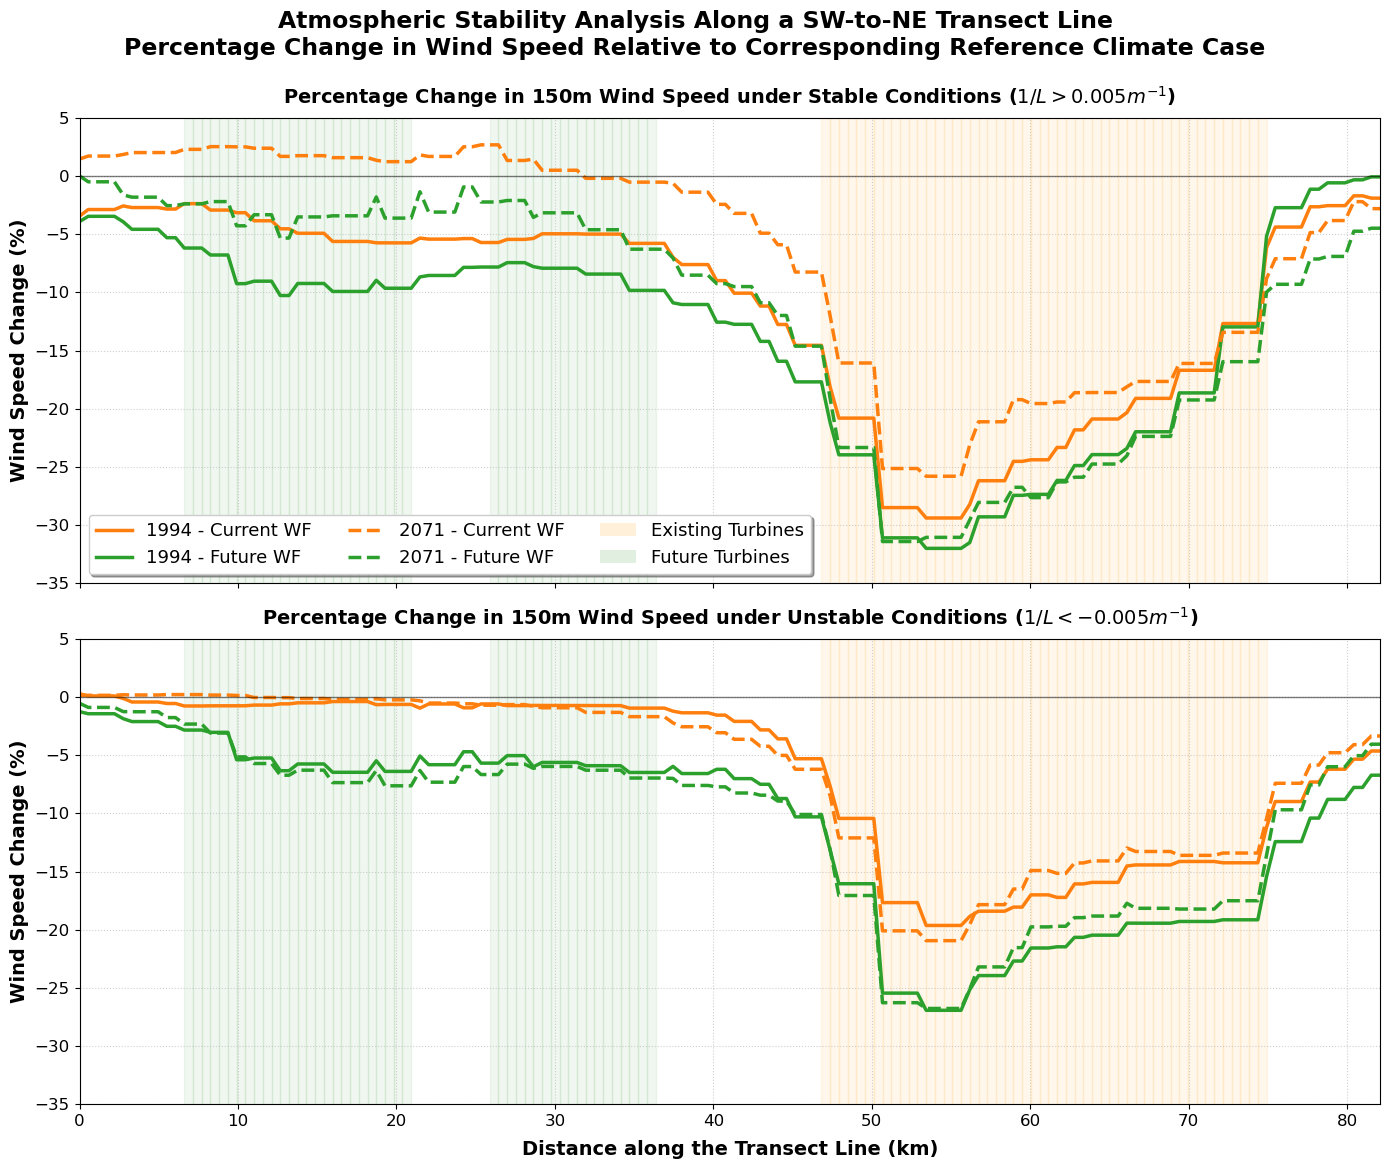

In [9]:
# --- 6. Plotting Two Panels ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

zone_handles = [
    Patch(facecolor='orange', alpha=0.15, label='Existing Turbines'),
    Patch(facecolor='green', alpha=0.12, label='Future Turbines')
]

stable_line_handles = []

stable_ref_1994 = final_stable.get('exp1994')
stable_ref_2071 = final_stable.get('experiment2')
unstable_ref_1994 = final_unstable.get('exp1994')
unstable_ref_2071 = final_unstable.get('experiment2')

for folder, label, color, linestyle in experiments:
    if folder in ['exp1994', 'experiment2']:
        continue
        
    # Top Panel: STABLE WAKES
    if folder in final_stable:
        st_ref = stable_ref_1994 if '1994' in folder else stable_ref_2071
        if st_ref is not None:
            stable_diff = ((final_stable[folder] - st_ref) / st_ref) * 100
            line, = ax1.plot(distances_km, stable_diff, label=label, color=color, linestyle=linestyle, linewidth=2.5)
            stable_line_handles.append(line)
            
    # Bottom Panel: UNSTABLE WAKES
    if folder in final_unstable:
        unst_ref = unstable_ref_1994 if '1994' in folder else unstable_ref_2071
        if unst_ref is not None:
            unstable_diff = ((final_unstable[folder] - unst_ref) / unst_ref) * 100
            ax2.plot(distances_km, unstable_diff, color=color, linestyle=linestyle, linewidth=2.5)

# Style & Format BOTH panels
for ax in [ax1, ax2]:
    ax.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    ax.set_ylabel("Wind Speed Change (%)", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(0, max(distances_km))
    ax.set_ylim(-35.0, 5.0)  
    ax.tick_params(labelsize=12)

# Panel Annotations
ax1.set_title("Percentage Change in 150m Wind Speed under Stable Conditions ($1/L > 0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_title("Percentage Change in 150m Wind Speed under Unstable Conditions ($1/L < -0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=14, fontweight='bold', labelpad=8)

ax1.legend(handles=stable_line_handles + zone_handles, loc='lower left', fontsize=13, frameon=True, ncol=3, shadow=True, facecolor='white')

# --- 7. Dynamic Shading Implementation ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
    if current_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')

plt.suptitle("Atmospheric Stability Analysis Along a SW-to-NE Transect Line\n"
             "Percentage Change in Wind Speed Relative to Corresponding Reference Climate Case", fontsize=17, fontweight='bold', y=0.97)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig(f"{base_path}transect_stability_stratified_wakes.png", dpi=300)
plt.show()

In [2]:
print(f"{'File / Hour':<25} | {'Start 1/L (km 0)':<18} | {'End 1/L (km Max)':<18} | {'Delta (End - Start)':<20} | {'Shift Detected?'}")
print("-" * 95)

# Run a quick check on your first few files to see the raw values
for f in files[:20]:  # Checking the first 3 files as a test sample
    nc = Dataset(f)
    
    ust = getvar(nc, "UST", timeidx=None, meta=False)
    hfx = getvar(nc, "HFX", timeidx=None, meta=False)
    th2 = getvar(nc, "TH2", timeidx=None, meta=False)
    
    if ust.ndim == 2:  # Single hour file
        ust, hfx, th2 = np.expand_dims(ust, 0), np.expand_dims(hfx, 0), np.expand_dims(th2, 0)
        
    num_times = ust.shape[0]
    file_short_name = f.split('/')[-1]
    
    for t in range(num_times):
        hfx_t = hfx[t, :, :]
        ust_t = ust[t, :, :]
        th2_t = th2[t, :, :]
        
        hfx_safe = np.where(hfx_t == 0.0, 1e-5, hfx_t)
        inv_L = (kappa * g * hfx_safe) / (rho_cp * th2_t * (ust_t**3 + 1e-6))
        
        # Pull the complete stability profile for this specific hour
        transect_inv_L = np.array([inv_L[y, x] for y, x in zip(y_indices, x_indices)])
        
        start_val = transect_inv_L[0]   # SW end (Coastal/Inshore)
        end_val = transect_inv_L[-1]    # NE end (Open Sea)
        delta = end_val - start_val
        
        # A shift means the conditions at the start and end cross zero or change dramatically
        # e.g., one side is stable (> 0.005) and the other is unstable (< -0.005)
        if (start_val > 0.005 and end_val < -0.005) or (start_val < -0.005 and end_val > 0.005):
            shift_status = "⚠️ YES (Regime Cross)"
        elif abs(delta) > 0.01:
            shift_status = "👀 YES (Strong Gradient)"
        else:
            shift_status = "Uniform"
            
        print(f"{file_short_name+' (h='+str(t)+')':<25} | {start_val:18.6f} | {end_val:18.6f} | {delta:20.6f} | {shift_status}")
        
    nc.close()

File / Hour               | Start 1/L (km 0)   | End 1/L (km Max)   | Delta (End - Start)  | Shift Detected?
-----------------------------------------------------------------------------------------------
wrfout_d03_2071-08-01_00:00:00 (h=0) |           0.000110 |           0.000110 |             0.000000 | Uniform
wrfout_d03_2071-08-01_00:00:00 (h=1) |          -0.635651 |          -1.428840 |            -0.793189 | 👀 YES (Strong Gradient)
wrfout_d03_2071-08-01_00:00:00 (h=2) |          -0.502585 |          -1.215796 |            -0.713210 | 👀 YES (Strong Gradient)
wrfout_d03_2071-08-01_00:00:00 (h=3) |          -0.384335 |          -0.844853 |            -0.460518 | 👀 YES (Strong Gradient)
wrfout_d03_2071-08-01_00:00:00 (h=4) |          -0.353996 |          -0.765257 |            -0.411260 | 👀 YES (Strong Gradient)
wrfout_d03_2071-08-01_00:00:00 (h=5) |          -0.059396 |          -0.183265 |            -0.123868 | 👀 YES (Strong Gradient)
wrfout_d03_2071-08-01_00:00:00 (h=6) |     

Found 31 matching daily files across all experiments.

Successfully processed 721 total hourly timestamps!


/tmp/ipykernel_2503045/2053011576.py:275: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2503045/2053011576.py:276: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2503045/2053011576.py:278: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
/tmp/ipykernel_2503045/2053011576.py:279: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')


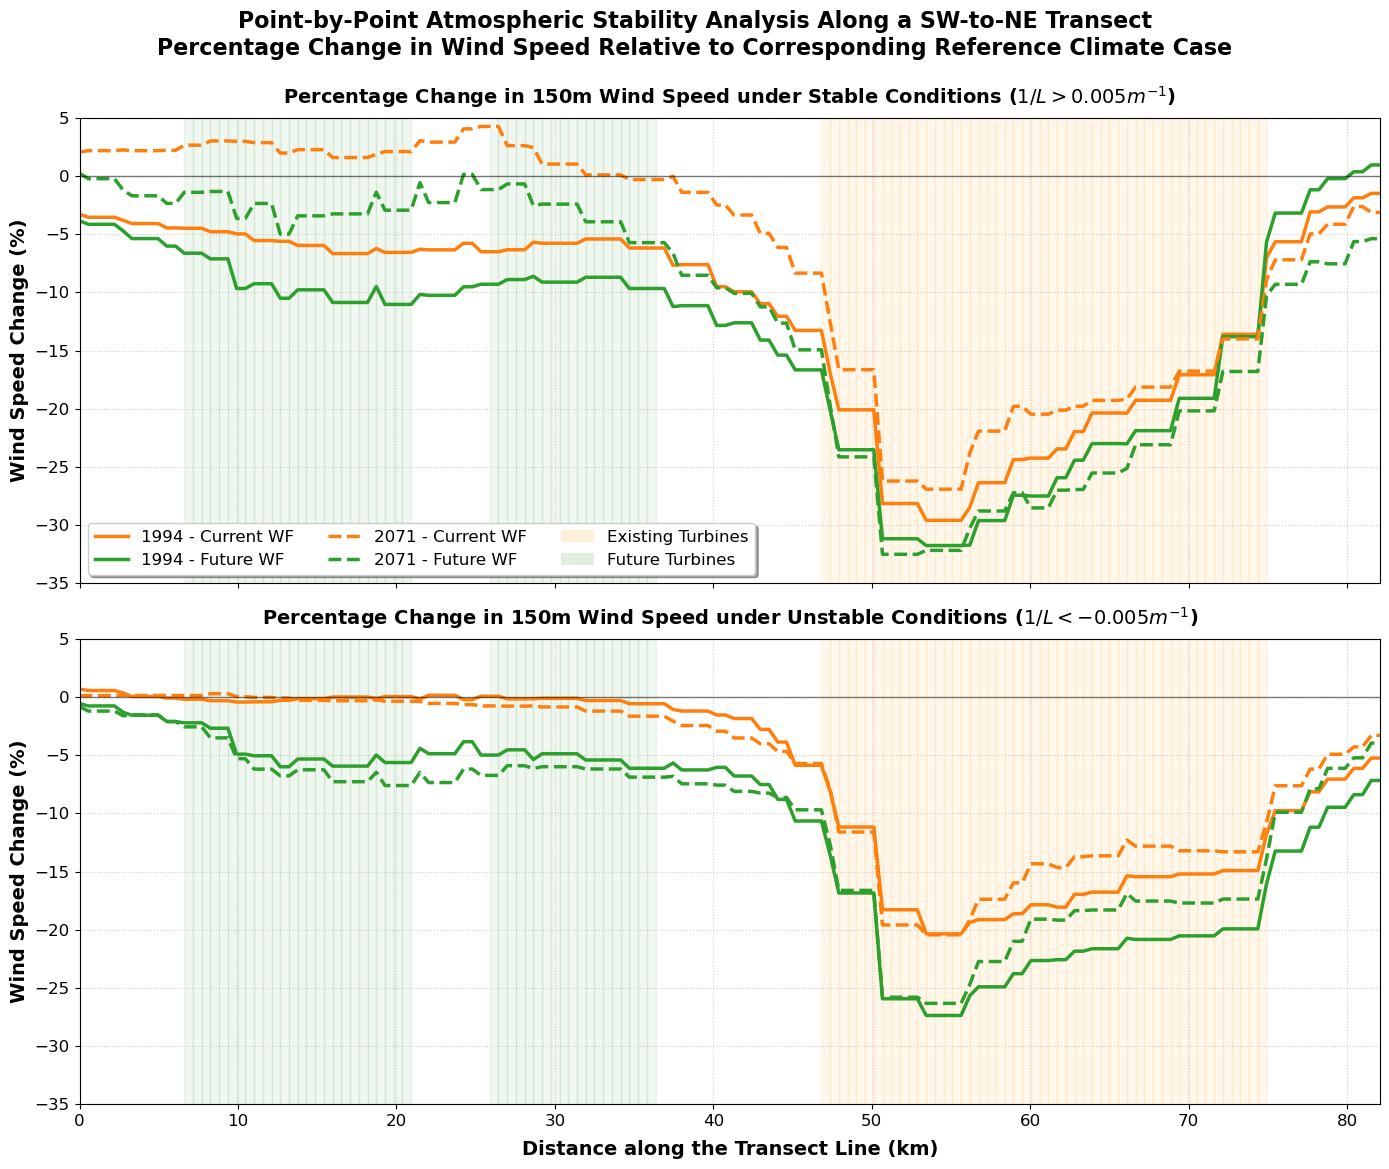

In [1]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from shapely.geometry import Polygon, Point
from scipy.spatial import KDTree
from matplotlib.patches import Patch

# --- 1. Geometry & Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1994 - no WF', '#1f77b4', '-'),
    ('exp1994_WF', '1994 - Current WF', '#ff7f0e', '-'),
    ('exp1994_WFF', '1994 - Future WF', '#2ca02c', '-'),
    ('experiment2', '2071 - no WF', '#1f77b4', '--'),
    ('exp2071_WF', '2071 - Current WF', '#ff7f0e', '--'),
    ('exp2071_WFF', '2071 - Future WF', '#2ca02c', '--')
]

file_pattern = 'WRF/run/wrfout_d03_*-08-*'
TARGET_HEIGHT = 150.0

# EXTENDED WAKE TRANSECT
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# --- 2. Load True Coordinate Layouts for Shading Determination ---
master_data = np.loadtxt('/data/nobackup/boland/exp2071_WFF/WRF/run/windturbines.txt')
current_data = np.loadtxt('/data/nobackup/boland/experiment2/WRF/run/windturbines.txt')

# Define strict geographical boundaries to filter exclusively for Belgian waters
BELGIAN_EEZ_POLY = Polygon([(2.20, 51.30), (2.40, 51.55), (2.90, 51.75), (3.35, 51.72), (3.15, 51.35)])

# Use the duplicate-filtering engine from the map script
DUPLICATE_THRESHOLD_DEG = 0.0032 
base_existing_coords = []
for lat, lon in zip(current_data[:, 0], current_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        if len(base_existing_coords) == 0:
            base_existing_coords.append([lat, lon])
        else:
            temp_tree = KDTree(base_existing_coords)
            distance, _ = temp_tree.query([lat, lon])
            if distance > DUPLICATE_THRESHOLD_DEG:
                base_existing_coords.append([lat, lon])

base_existing_coords = np.array(base_existing_coords)

# Isolate new/future coordinates
final_existing_lons = list(base_existing_coords[:, 1])
final_existing_lats = list(base_existing_coords[:, 0])
final_new_lons = []
final_new_lats = []

existing_tree = KDTree(base_existing_coords)
for lat, lon in zip(master_data[:, 0], master_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        distance, _ = existing_tree.query([lat, lon])
        if distance <= DUPLICATE_THRESHOLD_DEG:
            continue
        if lon < 2.68:  # West dividing line for PEZ
            if len(final_new_lons) > 0:
                new_tree = KDTree(np.column_stack((final_new_lats, final_new_lons)))
                dist_to_new, _ = new_tree.query([lat, lon])
                if dist_to_new <= DUPLICATE_THRESHOLD_DEG:
                    continue
            final_new_lons.append(lon)
            final_new_lats.append(lat)
        else:
            final_existing_lons.append(lon)
            final_existing_lats.append(lat)

# Build final Trees for profile cross-referencing
tree_existing = KDTree(np.column_stack((final_existing_lats, final_existing_lons)))
tree_new = KDTree(np.column_stack((final_new_lats, final_new_lons)))

# --- 3. Compute Transect Positions & Distances ---
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0]
nc_ref = Dataset(first_file)

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    x_idx, y_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

# Great circle distance calculation along transect path
d_lat = (transect_lats - START_LAT) * 111.0
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT))
distances_km = np.sqrt(d_lat**2 + d_lon**2)

# --- 4. Spatial Intersection Shading Masks ---
SHADING_RADIUS_DEG = 0.0225 

current_mask = []
future_mask = []
for lat, lon in zip(transect_lats, transect_lons):
    dist_ext, _ = tree_existing.query([lat, lon])
    dist_new, _ = tree_new.query([lat, lon])
    current_mask.append(dist_ext <= SHADING_RADIUS_DEG)
    future_mask.append(dist_new <= SHADING_RADIUS_DEG)

# --- 5. Hourly Synchronized Processing & Point-by-Point Stratification ---
kappa = 0.40
g = 9.81
rho_cp = 1.225 * 1005.0

# Arrays to accumulate wind speed and hour counts at each point along transect (150 points)
stable_wspd_sum = {exp[0]: np.zeros(NUM_POINTS) for exp in experiments}
stable_point_hours = {exp[0]: np.zeros(NUM_POINTS) for exp in experiments}

unstable_wspd_sum = {exp[0]: np.zeros(NUM_POINTS) for exp in experiments}
unstable_point_hours = {exp[0]: np.zeros(NUM_POINTS) for exp in experiments}

# Convert list indices to NumPy arrays for fast 2D slicing
x_arr = np.array(x_indices, dtype=int)
y_arr = np.array(y_indices, dtype=int)

# Map files strictly by Day of Month (01 to 31) regardless of Year in file name
def get_day_mapped_files(folder_name):
    folder_files = sorted(glob.glob(f"{base_path}{folder_name}/{file_pattern}"))
    mapped = {}
    for f in folder_files:
        match = re.search(r'-08-(\d{2})_', f)
        if match:
            day_key = match.group(1) # e.g., "01", "02", ..., "31"
            mapped[day_key] = f
    return mapped

exp_file_maps = {exp[0]: get_day_mapped_files(exp[0]) for exp in experiments}

# Find common days of the month across ALL experiments
common_days = set(exp_file_maps['exp1994'].keys())
for folder, _, _, _ in experiments:
    common_days = common_days.intersection(set(exp_file_maps[folder].keys()))

print(f"Found {len(common_days)} matching daily files across all experiments.")

total_processed_hours = 0

# Loop through each DAY OF THE MONTH ("01", "02", ..., "31")
for day_key in sorted(list(common_days)):
    
    # Check how many time steps exist in this daily file (usually 24)
    nc_ref_1994 = Dataset(exp_file_maps['exp1994'][day_key])
    num_timesteps = nc_ref_1994.dimensions['Time'].size
    nc_ref_1994.close()

    # Loop through EVERY HOUR (t_idx) in the daily file
    for t_idx in range(num_timesteps):
        total_processed_hours += 1
        
        # 1. Load Data for ALL 6 Experiments at this exact timestamp (t_idx)
        wspd_transect_dict = {}
        inv_L_transect_dict = {}
        
        for folder, _, _, _ in experiments:
            nc_exp = Dataset(exp_file_maps[folder][day_key])
            
            # Wind speed at 150m
            u = getvar(nc_exp, "ua", timeidx=t_idx, units="m s-1", meta=False)
            v = getvar(nc_exp, "va", timeidx=t_idx, units="m s-1", meta=False)
            height = getvar(nc_exp, "height_agl", timeidx=t_idx, units="m", meta=False)
            wspd_3d = np.sqrt(u**2 + v**2)
            wspd_150m = interplevel(wspd_3d, height, TARGET_HEIGHT, meta=False)
            
            # Surface stability variables
            ust = getvar(nc_exp, "UST", timeidx=t_idx, meta=False)
            hfx = getvar(nc_exp, "HFX", timeidx=t_idx, meta=False)
            th2 = getvar(nc_exp, "TH2", timeidx=t_idx, meta=False)
            nc_exp.close()
            
            # Obukhov Length (1/L) field
            ust_safe = np.maximum(ust, 1e-3)
            inv_L = -(kappa * g * hfx) / (rho_cp * th2 * (ust_safe**3))
            
            # Slice transect points dynamically
            wspd_transect_dict[folder] = wspd_150m[y_arr, x_arr]
            inv_L_transect_dict[folder] = inv_L[y_arr, x_arr]

        # 2. Accumulate Point-by-Point Stratified Data for Each Experiment
        for folder, _, _, _ in experiments:
            # Determine which climate reference stability field to use for stratification
            ref_folder = 'exp1994' if '1994' in folder else 'experiment2'
            transect_inv_L = inv_L_transect_dict[ref_folder] # Point-by-point stability of corresponding control
            
            transect_wspd = wspd_transect_dict[folder]
            
            # Point-by-Point Masks along transect
            stable_mask = transect_inv_L > 0.005
            unstable_mask = transect_inv_L < -0.005
            
            # Accumulate sum and hour counts per point
            stable_wspd_sum[folder][stable_mask] += transect_wspd[stable_mask]
            stable_point_hours[folder][stable_mask] += 1
            
            unstable_wspd_sum[folder][unstable_mask] += transect_wspd[unstable_mask]
            unstable_point_hours[folder][unstable_mask] += 1

print(f"\nSuccessfully processed {total_processed_hours} total hourly timestamps!")

# --- Compute Final Mean Profiles ---
stable_profiles = {}
unstable_profiles = {}

for folder, _, _, _ in experiments:
    with np.errstate(divide='ignore', invalid='ignore'):
        stable_profiles[folder] = np.where(
            stable_point_hours[folder] > 0, 
            stable_wspd_sum[folder] / stable_point_hours[folder], 
            np.nan
        )
        unstable_profiles[folder] = np.where(
            unstable_point_hours[folder] > 0, 
            unstable_wspd_sum[folder] / unstable_point_hours[folder], 
            np.nan
        )

# --- 6. Plotting Two Panels ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Custom legend proxies for turbine zones
zone_handles = [
    Patch(facecolor='orange', alpha=0.15, label='Existing Turbines'),
    Patch(facecolor='green', alpha=0.12, label='Future Turbines')
]

stable_line_handles = []

# Baseline references
stable_ref_1994 = stable_profiles.get('exp1994')
stable_ref_2071 = stable_profiles.get('experiment2')
unstable_ref_1994 = unstable_profiles.get('exp1994')
unstable_ref_2071 = unstable_profiles.get('experiment2')

for folder, label, color, linestyle in experiments:
    # Skip plotting the control baselines directly
    if folder in ['exp1994', 'experiment2']:
        continue
        
    # 1. Top Panel: STABLE WAKES
    if folder in stable_profiles:
        st_ref = stable_ref_1994 if '1994' in folder else stable_ref_2071
        if st_ref is not None:
            stable_diff = ((stable_profiles[folder] - st_ref) / st_ref) * 100
            line, = ax1.plot(distances_km, stable_diff, label=label, color=color, linestyle=linestyle, linewidth=2.5)
            stable_line_handles.append(line)
            
    # 2. Bottom Panel: UNSTABLE WAKES
    if folder in unstable_profiles:
        unst_ref = unstable_ref_1994 if '1994' in folder else unstable_ref_2071
        if unst_ref is not None:
            unstable_diff = ((unstable_profiles[folder] - unst_ref) / unst_ref) * 100
            ax2.plot(distances_km, unstable_diff, color=color, linestyle=linestyle, linewidth=2.5)

# Style & Format BOTH panels dynamically
for ax in [ax1, ax2]:
    ax.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    ax.set_ylabel("Wind Speed Change (%)", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(0, max(distances_km))
    ax.set_ylim(-35, 5)  # Enforces a matching identical scale across both profiles
    ax.tick_params(labelsize=12)

# Dynamic Shading Implementation for Turbines
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
    if current_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')

# Panel Annotations
ax1.set_title("Percentage Change in 150m Wind Speed under Stable Conditions ($1/L > 0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_title("Percentage Change in 150m Wind Speed under Unstable Conditions ($1/L < -0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=14, fontweight='bold', labelpad=8)

# Unified Legend
ax1.legend(handles=stable_line_handles + zone_handles, loc='lower left', fontsize=12, frameon=True, ncol=3, shadow=True, facecolor='white')

# Master Title Block
plt.suptitle("Point-by-Point Atmospheric Stability Analysis Along a SW-to-NE Transect\n"
             "Percentage Change in Wind Speed Relative to Corresponding Reference Climate Case", fontsize=16, fontweight='bold', y=0.97)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig(f"{base_path}transect_point_by_point_stratified_wakes.png", dpi=300)
plt.show()

In [13]:
print("\n=== TRANSECT STABILITY DISTRIBUTION SUMMARY ===")
print(f"{'Distance (km)':<15} | {'Stable (hrs)':<12} | {'Unstable (hrs)':<14} | {'Neutral (hrs)':<12} | {'Stable %':<10}")
print("-" * 72)

# Sample 5 representative locations along the 150 points
indices_to_show = [0, 37, 74, 111, 149]

for idx in indices_to_show:
    km = distances_km[idx]
    st = stable_point_hours['exp1994'][idx]
    unst = unstable_point_hours['exp1994'][idx]
    neu = total_processed_hours - (st + unst)
    st_pct = (st / total_processed_hours) * 100
    
    print(f"{km:<15.1f} | {st:<12.0f} | {unst:<14.0f} | {neu:<12.0f} | {st_pct:<10.1f}%")


=== TRANSECT STABILITY DISTRIBUTION SUMMARY ===
Distance (km)   | Stable (hrs) | Unstable (hrs) | Neutral (hrs) | Stable %  
------------------------------------------------------------------------
0.0             | 116          | 321            | 284          | 16.1      %
20.4            | 102          | 328            | 291          | 14.1      %
40.8            | 92           | 364            | 265          | 12.8      %
61.1            | 93           | 386            | 242          | 12.9      %
82.1            | 85           | 392            | 244          | 11.8      %


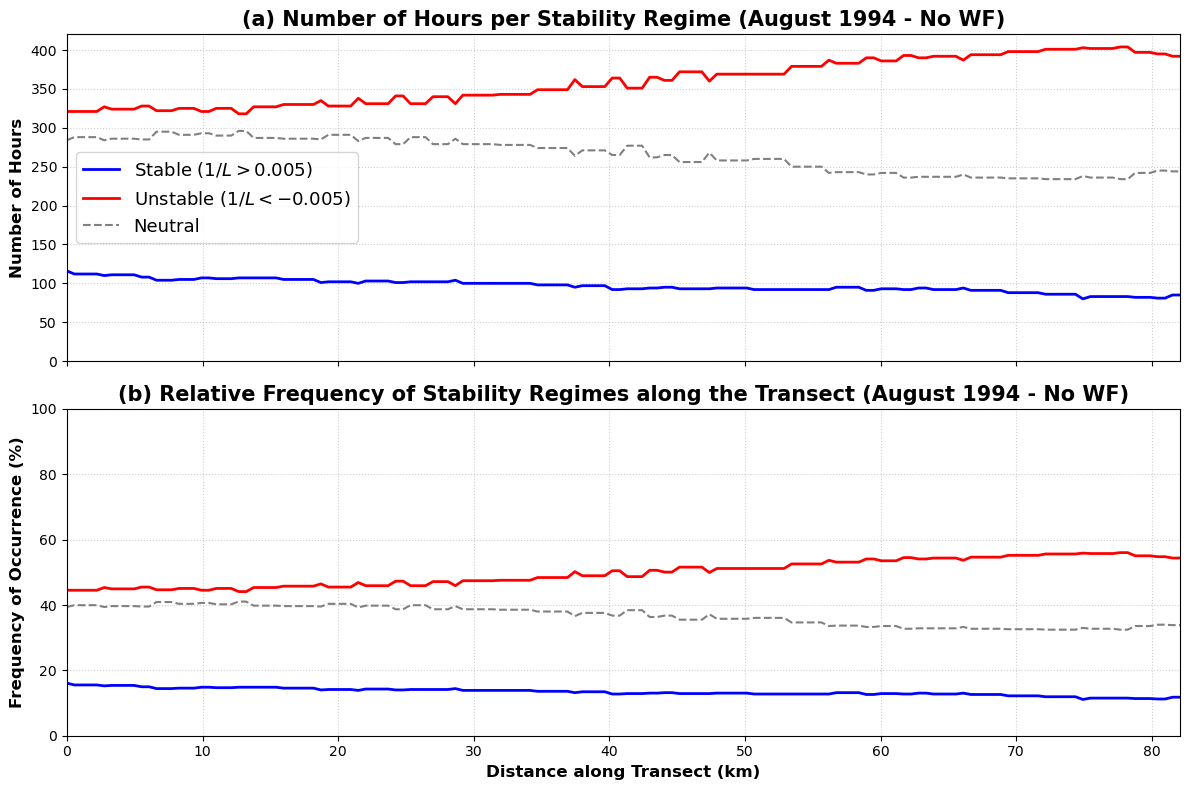

In [13]:
# Create a dedicated diagnostic figure for your thesis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Calculate neutral hours as the remaining hours
# Assuming ref_folder 'exp1994' for baseline stability counts
total_hours = total_processed_hours
st_hours = stable_point_hours['exp1994']
unst_hours = unstable_point_hours['exp1994']
neu_hours = total_hours - (st_hours + unst_hours)

# Panel 1: Absolute Hours Count
ax1.plot(distances_km, st_hours, color='blue', linewidth=2, label='Stable ($1/L > 0.005$)')
ax1.plot(distances_km, unst_hours, color='red', linewidth=2, label='Unstable ($1/L < -0.005$)')
ax1.plot(distances_km, neu_hours, color='gray', linestyle='--', linewidth=1.5, label='Neutral')

ax1.set_ylabel("Number of Hours", fontsize=12, fontweight='bold')
ax1.set_title("(a) Number of Hours per Stability Regime (August 1994 - No WF)", fontsize=15, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='center left', frameon=True, fontsize=13)

# Panel 2: Percentage Occurrence
ax2.plot(distances_km, (st_hours / total_hours) * 100, color='blue', linewidth=2, label='Stable %')
ax2.plot(distances_km, (unst_hours / total_hours) * 100, color='red', linewidth=2, label='Unstable %')
ax2.plot(distances_km, (neu_hours / total_hours) * 100, color='gray', linestyle='--', linewidth=1.5, label='Neutral %')

ax2.set_ylabel("Frequency of Occurrence (%)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Distance along Transect (km)", fontsize=12, fontweight='bold')
ax2.set_title("(b) Relative Frequency of Stability Regimes along the Transect (August 1994 - No WF)", fontsize=15, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

# --- AXIS OFFSET FIX ---
# 1. Force X-axis to start exactly at 0 km and end at the max distance
ax1.set_xlim(left=0, right=max(distances_km))  # Applies to ax2 automatically because sharex=True

# 2. Force Y-axes to start at 0
ax1.set_ylim(bottom=0)                         # Let top scale dynamically to maximum hours
ax2.set_ylim(bottom=0, top=100)               # Hard-code 0% to 100%

plt.tight_layout()
plt.savefig(f"{base_path}transect_stability_sample_sizes.png", dpi=300)
plt.show()

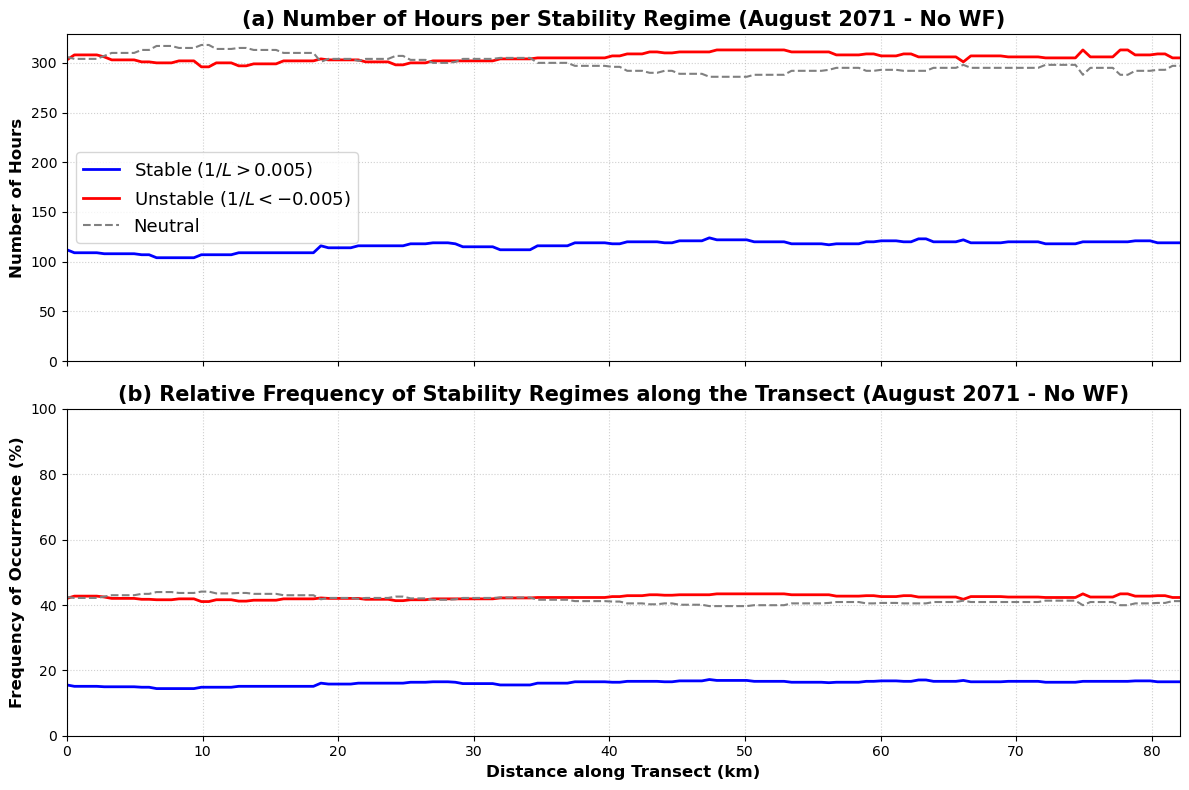

In [11]:
# Create a dedicated diagnostic figure for your thesis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Calculate neutral hours as the remaining hours
# Assuming ref_folder 'exp1994' for baseline stability counts
total_hours = total_processed_hours
st_hours = stable_point_hours['experiment2']
unst_hours = unstable_point_hours['experiment2']
neu_hours = total_hours - (st_hours + unst_hours)

# Panel 1: Absolute Hours Count
ax1.plot(distances_km, st_hours, color='blue', linewidth=2, label='Stable ($1/L > 0.005$)')
ax1.plot(distances_km, unst_hours, color='red', linewidth=2, label='Unstable ($1/L < -0.005$)')
ax1.plot(distances_km, neu_hours, color='gray', linestyle='--', linewidth=1.5, label='Neutral')

ax1.set_ylabel("Number of Hours", fontsize=12, fontweight='bold')
ax1.set_title("(a) Number of Hours per Stability Regime (August 2071 - No WF)", fontsize=15, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='center left', frameon=True, fontsize=13)

# Panel 2: Percentage Occurrence
ax2.plot(distances_km, (st_hours / total_hours) * 100, color='blue', linewidth=2, label='Stable %')
ax2.plot(distances_km, (unst_hours / total_hours) * 100, color='red', linewidth=2, label='Unstable %')
ax2.plot(distances_km, (neu_hours / total_hours) * 100, color='gray', linestyle='--', linewidth=1.5, label='Neutral %')

ax2.set_ylabel("Frequency of Occurrence (%)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Distance along Transect (km)", fontsize=12, fontweight='bold')
ax2.set_title("(b) Relative Frequency of Stability Regimes along the Transect (August 2071 - No WF)", fontsize=15, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

# --- AXIS OFFSET FIX ---
# 1. Force X-axis to start exactly at 0 km and end at the max distance
ax1.set_xlim(left=0, right=max(distances_km))  # Applies to ax2 automatically because sharex=True

# 2. Force Y-axes to start at 0
ax1.set_ylim(bottom=0)                         # Let top scale dynamically to maximum hours
ax2.set_ylim(bottom=0, top=100)               # Hard-code 0% to 100%

plt.tight_layout()
plt.savefig(f"{base_path}transect_stability_sample_sizes.png", dpi=300)
plt.show()

Stratifying data point-by-point for: 1994 - no WF...
Stratifying data point-by-point for: 1994 - Current WF...
Stratifying data point-by-point for: 1994 - Future WF...
Stratifying data point-by-point for: 2071 - no WF...
Stratifying data point-by-point for: 2071 - Current WF...
Stratifying data point-by-point for: 2071 - Future WF...


/tmp/ipykernel_2668489/3797827030.py:227: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2668489/3797827030.py:228: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2668489/3797827030.py:230: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
/tmp/ipykernel_2668489/3797827030.py:231: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')


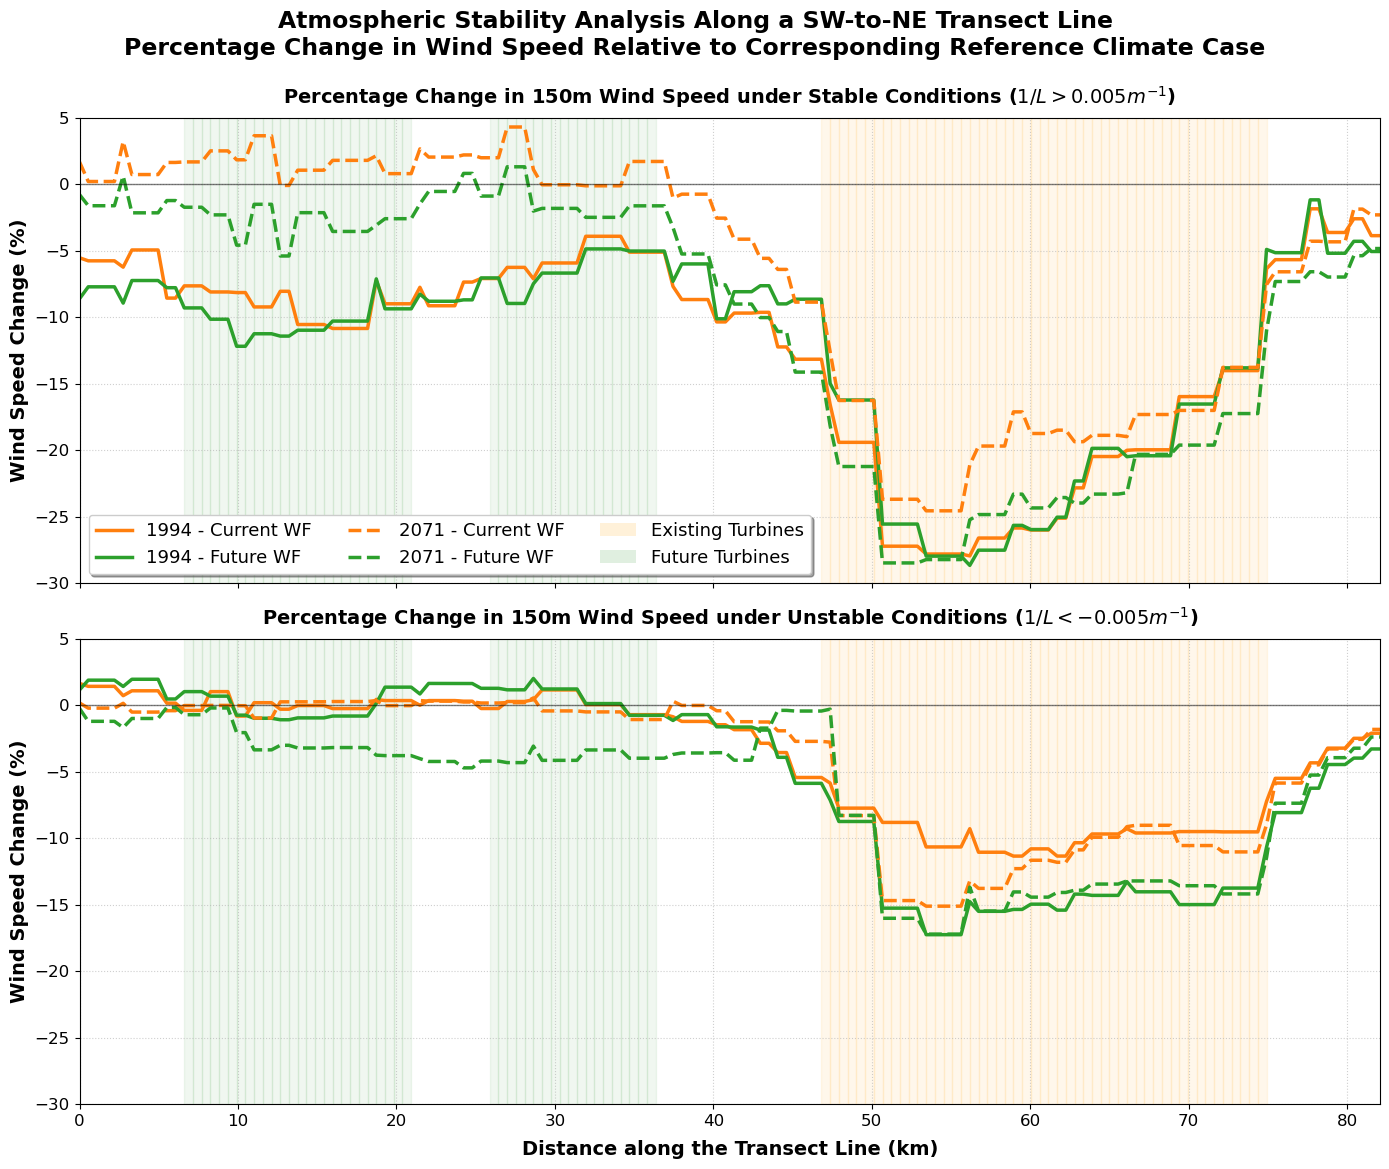

In [2]:
import glob 
import re 
import numpy as np 
import matplotlib.pyplot as plt 
from netCDF4 import Dataset 
from wrf import getvar, interplevel, ll_to_xy 
from shapely.geometry import Polygon, Point 
from scipy.spatial import KDTree 
from matplotlib.patches import Patch 

# --- 1. Geometry & Configuration --- 
base_path = '/data/nobackup/boland/' 
experiments = [ 
    ('exp1994', '1994 - no WF', '#1f77b4', '-'), 
    ('exp1994_WF', '1994 - Current WF', '#ff7f0e', '-'), 
    ('exp1994_WFF', '1994 - Future WF', '#2ca02c', '-'), 
    ('experiment2', '2071 - no WF', '#1f77b4', '--'), 
    ('exp2071_WF', '2071 - Current WF', '#ff7f0e', '--'), 
    ('exp2071_WFF', '2071 - Future WF', '#2ca02c', '--') 
] 

file_pattern = 'WRF/run/wrfout_d03_*-08-*' 
TARGET_HEIGHT = 150.0 

# EXTENDED WAKE TRANSECT 
START_LAT, START_LON = 51.32, 2.30 
END_LAT, END_LON = 51.80, 3.20 
NUM_POINTS = 150 

# --- 2. Load True Coordinate Layouts for Shading Determination --- 
master_data = np.loadtxt('/data/nobackup/boland/exp2071_WFF/WRF/run/windturbines.txt') 
current_data = np.loadtxt('/data/nobackup/boland/experiment2/WRF/run/windturbines.txt') 

# Define strict geographical boundaries to filter exclusively for Belgian waters 
BELGIAN_EEZ_POLY = Polygon([(2.20, 51.30), (2.40, 51.55), (2.90, 51.75), (3.35, 51.72), (3.15, 51.35)]) 

# Use the duplicate-filtering engine from the map script 
DUPLICATE_THRESHOLD_DEG = 0.0032 
base_existing_coords = [] 
for lat, lon in zip(current_data[:, 0], current_data[:, 1]): 
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)): 
        if len(base_existing_coords) == 0: 
            base_existing_coords.append([lat, lon]) 
        else: 
            temp_tree = KDTree(base_existing_coords) 
            distance, _ = temp_tree.query([lat, lon]) 
            if distance > DUPLICATE_THRESHOLD_DEG: 
                base_existing_coords.append([lat, lon]) 

base_existing_coords = np.array(base_existing_coords) 

# Isolate new/future coordinates 
final_existing_lons = list(base_existing_coords[:, 1]) 
final_existing_lats = list(base_existing_coords[:, 0]) 
final_new_lons = [] 
final_new_lats = [] 

existing_tree = KDTree(base_existing_coords) 
for lat, lon in zip(master_data[:, 0], master_data[:, 1]): 
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)): 
        distance, _ = existing_tree.query([lat, lon]) 
        if distance <= DUPLICATE_THRESHOLD_DEG: 
            continue 
        if lon < 2.68:  # West dividing line for PEZ 
            if len(final_new_lons) > 0: 
                new_tree = KDTree(np.column_stack((final_new_lats, final_new_lons))) 
                dist_to_new, _ = new_tree.query([lat, lon]) 
                if dist_to_new <= DUPLICATE_THRESHOLD_DEG: 
                    continue 
            final_new_lons.append(lon) 
            final_new_lats.append(lat) 
        else: 
            final_existing_lons.append(lon) 
            final_existing_lats.append(lat) 

# Build final Trees for profile cross-referencing 
tree_existing = KDTree(np.column_stack((final_existing_lats, final_existing_lons))) 
tree_new = KDTree(np.column_stack((final_new_lats, final_new_lons))) 

# --- 3. Compute Transect Positions & Distances --- 
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0] 
nc_ref = Dataset(first_file) 

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS) 
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS) 

x_indices, y_indices = [], [] 
for lat, lon in zip(transect_lats, transect_lons): 
    x_idx, y_idx = ll_to_xy(nc_ref, lat, lon) 
    x_indices.append(int(x_idx)) 
    y_indices.append(int(y_idx)) 
nc_ref.close() 

# Great circle distance calculation along transect path 
d_lat = (transect_lats - START_LAT) * 111.0 
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT)) 
distances_km = np.sqrt(d_lat**2 + d_lon**2) 

# --- 4. Spatial Intersection Shading Masks --- 
SHADING_RADIUS_DEG = 0.0225 

current_mask = [] 
future_mask = [] 
for lat, lon in zip(transect_lats, transect_lons): 
    dist_ext, _ = tree_existing.query([lat, lon]) 
    dist_new, _ = tree_new.query([lat, lon]) 
    current_mask.append(dist_ext <= SHADING_RADIUS_DEG) 
    future_mask.append(dist_new <= SHADING_RADIUS_DEG) 

# --- 5. Hourly Processing & Point-by-Point Stability Stratification --- 
kappa = 0.40 
g = 9.81 
rho_cp = 1.225 * 1005.0 

stable_profiles = {} 
unstable_profiles = {} 

# Convert list indices to NumPy arrays for fast 2D slicing 
x_arr = np.array(x_indices, dtype=int) 
y_arr = np.array(y_indices, dtype=int) 

for folder, label, color, linestyle in experiments: 
    all_august_files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}")) 
    files = [f for f in all_august_files if int(f.split('_')[-2].split('-')[-1]) <= 30] 
    if not files: 
        continue 
    print(f"Stratifying data point-by-point for: {label}...") 
    stable_wspd_sum = np.zeros(NUM_POINTS) 
    stable_point_hours = np.zeros(NUM_POINTS) 
    unstable_wspd_sum = np.zeros(NUM_POINTS) 
    unstable_point_hours = np.zeros(NUM_POINTS) 
    for f in files: 
        nc = Dataset(f) 
        u = getvar(nc, "ua", timeidx=None, units="m s-1", meta=False) 
        v = getvar(nc, "va", timeidx=None, units="m s-1", meta=False) 
        height = getvar(nc, "height_agl", timeidx=None, units="m", meta=False) 
        wspd_3d = np.sqrt(u**2 + v**2) 
        wspd_150m = interplevel(wspd_3d, height, TARGET_HEIGHT, meta=False) 
        ust = getvar(nc, "UST", timeidx=None, meta=False) 
        hfx = getvar(nc, "HFX", timeidx=None, meta=False) 
        th2 = getvar(nc, "TH2", timeidx=None, meta=False) 
        if wspd_150m.ndim == 2: 
            wspd_150m = np.expand_dims(wspd_150m, axis=0) 
            ust = np.expand_dims(ust, axis=0) 
            hfx = np.expand_dims(hfx, axis=0) 
            th2 = np.expand_dims(th2, axis=0) 
        num_times = wspd_150m.shape[0] 
        for t in range(num_times): 
            wspd_t = wspd_150m[t, :, :] 
            ust_t = ust[t, :, :] 
            hfx_t = hfx[t, :, :] 
            th2_t = th2[t, :, :] 
            # --- FIXED OBUKHOV LENGTH FORMULA --- 
            ust_safe = np.maximum(ust_t, 1e-3) 
            inv_L = -(kappa * g * hfx_t) / (rho_cp * th2_t * (ust_safe**3)) 
            # Vectorized point extraction along transect 
            transect_wspd = wspd_t[y_arr, x_arr] 
            transect_inv_L = inv_L[y_arr, x_arr] 
            # Point-by-Point Masks 
            stable_mask = transect_inv_L > 0.005 
            unstable_mask = transect_inv_L < -0.005 
            stable_wspd_sum[stable_mask] += transect_wspd[stable_mask] 
            stable_point_hours[stable_mask] += 1 
            unstable_wspd_sum[unstable_mask] += transect_wspd[unstable_mask] 
            unstable_point_hours[unstable_mask] += 1 
        nc.close() 
    with np.errstate(divide='ignore', invalid='ignore'): 
        stable_profiles[folder] = np.where(stable_point_hours > 0, stable_wspd_sum / stable_point_hours, np.nan) 
        unstable_profiles[folder] = np.where(unstable_point_hours > 0, unstable_wspd_sum / unstable_point_hours, np.nan) 

# --- 6. Plotting Two Panels --- 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True) 

# Define custom legend proxies for the background turbine zones 
zone_handles = [ 
    Patch(facecolor='orange', alpha=0.15, label='Existing Turbines'), 
    Patch(facecolor='green', alpha=0.12, label='Future Turbines') 
] 

stable_line_handles = [] 

# Map baseline references 
stable_ref_1994 = stable_profiles.get('exp1994') 
stable_ref_2071 = stable_profiles.get('experiment2') 
unstable_ref_1994 = unstable_profiles.get('exp1994') 
unstable_ref_2071 = unstable_profiles.get('experiment2') 

for folder, label, color, linestyle in experiments: 
    # Skip plotting the flat control baselines (removes blue lines) 
    if folder in ['exp1994', 'experiment2']: 
        continue 
    # 1. Top Panel: STABLE WAKES 
    if folder in stable_profiles: 
        st_ref = stable_ref_1994 if '1994' in folder else stable_ref_2071 
        if st_ref is not None: 
            stable_diff = ((stable_profiles[folder] - st_ref) / st_ref) * 100 
            st_label = f"{label}" if '1994' in folder else f"{label}" 
            line, = ax1.plot(distances_km, stable_diff, label=st_label, color=color, linestyle=linestyle, linewidth=2.5) 
            stable_line_handles.append(line) 
    # 2. Bottom Panel: UNSTABLE WAKES 
    if folder in unstable_profiles: 
        unst_ref = unstable_ref_1994 if '1994' in folder else unstable_ref_2071 
        if unst_ref is not None: 
            unstable_diff = ((unstable_profiles[folder] - unst_ref) / unst_ref) * 100 
            ax2.plot(distances_km, unstable_diff, color=color, linestyle=linestyle, linewidth=2.5) 

# Style & Format BOTH panels dynamically 
for ax in [ax1, ax2]: 
    ax.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1) 
    ax.set_ylabel("Wind Speed Change (%)", fontsize=14, fontweight='bold') 
    ax.grid(True, linestyle=':', alpha=0.6) 
    ax.set_xlim(0, max(distances_km)) 
    ax.set_ylim(-30, 5)  # Enforces a matching identical scale across both profiles 
    ax.tick_params(labelsize=12) 

# Specific Panel Annotations 
ax1.set_title("Percentage Change in 150m Wind Speed under Stable Conditions ($1/L > 0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10) 
ax2.set_title("Percentage Change in 150m Wind Speed under Unstable Conditions ($1/L < -0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10) 
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=14, fontweight='bold', labelpad=8) 

# Unified Legend Placement (Upper Right shifts it clear from crashing with profile curves) 
ax1.legend(handles=stable_line_handles + zone_handles, loc='lower left', fontsize=13, frameon=True, ncol=3, shadow=True, facecolor='white') 

# --- 7. Dynamic Shading Implementation --- 
for i in range(len(distances_km) - 1): 
    if future_mask[i]: 
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none') 
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none') 
    if current_mask[i]: 
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none') 
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none') 

# Master Title Block Formatting 
plt.suptitle("Atmospheric Stability Analysis Along a SW-to-NE Transect Line\n" 
             "Percentage Change in Wind Speed Relative to Corresponding Reference Climate Case", fontsize=17, fontweight='bold', y=0.97) 

plt.tight_layout() 
plt.subplots_adjust(top=0.88) 
plt.savefig(f"{base_path}transect_stability_stratified_wakes.png", dpi=300) 
plt.show()

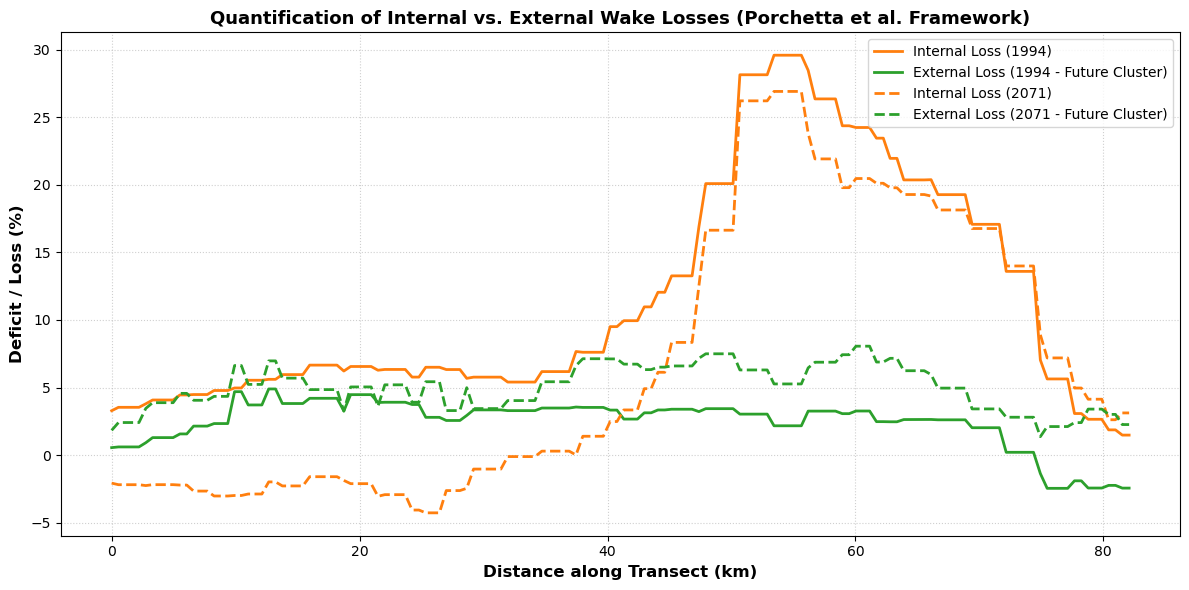

In [15]:
# --- Calculate Internal, External, and Total Wake Losses (%) ---
# Using wind speed or power array extracted along your transect (150 points)

def calculate_wake_breakdown(no_wf, current_wf, future_wf):
    """
    Computes wake loss metrics following Porchetta et al. (2024)
    Can accept wind speed (m/s) or converted power (MW)
    """
    # Internal Loss: Existing turbines vs No WF baseline
    loss_internal = ((no_wf - current_wf) / no_wf) * 100.0
    
    # Combined Loss: Future layout vs No WF baseline
    loss_total = ((no_wf - future_wf) / no_wf) * 100.0
    
    # External Loss: Additional loss caused ONLY by the new expansion cluster
    loss_external = loss_total - loss_internal
    
    return loss_internal, loss_external, loss_total

# Example for 1994 Stable Profiles:
int_1994, ext_1994, tot_1994 = calculate_wake_breakdown(
    stable_profiles['exp1994'], 
    stable_profiles['exp1994_WF'], 
    stable_profiles['exp1994_WFF']
)

# Example for 2071 Stable Profiles:
int_2071, ext_2071, tot_2071 = calculate_wake_breakdown(
    stable_profiles['experiment2'], 
    stable_profiles['exp2071_WF'], 
    stable_profiles['exp2071_WFF']
)

# --- Plotting External vs. Internal Breakdown ---
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(distances_km, int_1994, color='#ff7f0e', linestyle='-', linewidth=2, label='Internal Loss (1994)')
ax.plot(distances_km, ext_1994, color='#2ca02c', linestyle='-', linewidth=2, label='External Loss (1994 - Future Cluster)')

ax.plot(distances_km, int_2071, color='#ff7f0e', linestyle='--', linewidth=2, label='Internal Loss (2071)')
ax.plot(distances_km, ext_2071, color='#2ca02c', linestyle='--', linewidth=2, label='External Loss (2071 - Future Cluster)')

ax.set_ylabel("Deficit / Loss (%)", fontsize=12, fontweight='bold')
ax.set_xlabel("Distance along Transect (km)", fontsize=12, fontweight='bold')
ax.set_title("Quantification of Internal vs. External Wake Losses (Porchetta et al. Framework)", fontsize=13, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

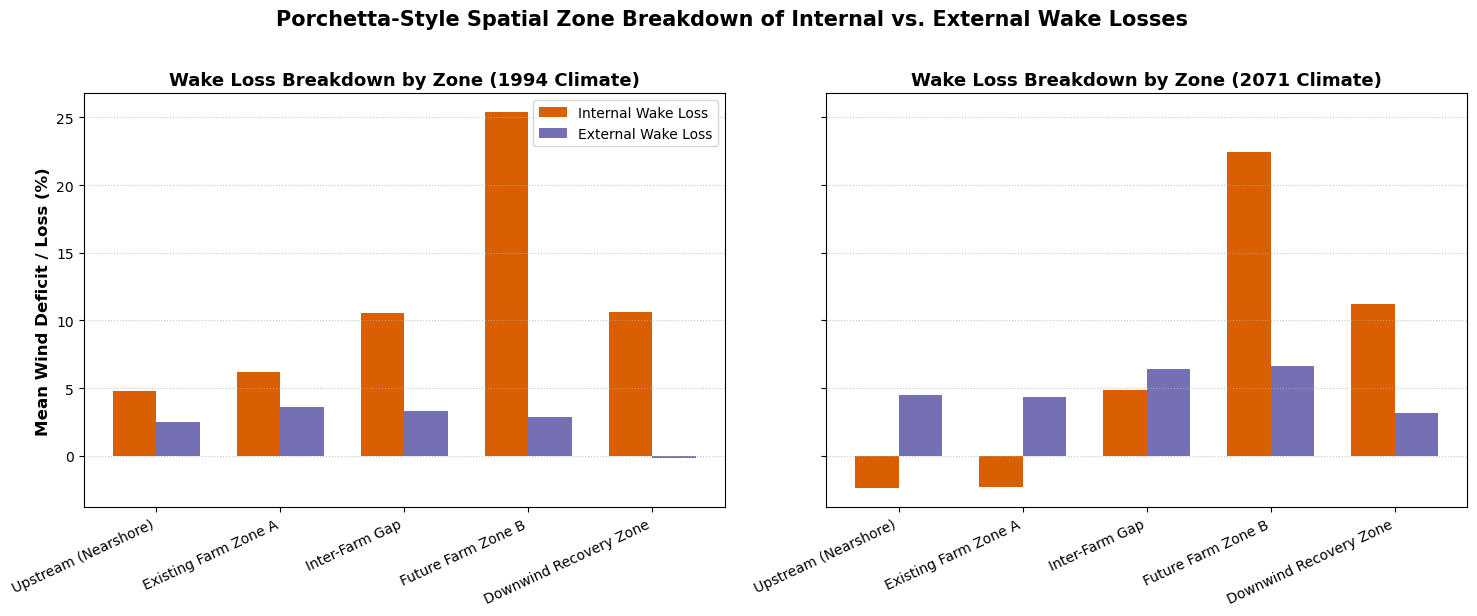

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Spatial Zones (e.g., Farm A, Farm B, Inter-farm Gap, Farm C) ---
# Instead of 150 individual points, group transect points into meaningful clusters/farms
zones = {
    'Upstream (Nearshore)': (0, 30),       # Transect points 0 to 30
    'Existing Farm Zone A': (31, 60),      # Existing turbines
    'Inter-Farm Gap': (61, 90),            # Space between clusters
    'Future Farm Zone B': (91, 120),       # New expansion area
    'Downwind Recovery Zone': (121, 149)   # Downwind wake area
}

zone_names = list(zones.keys())
int_loss_1994, ext_loss_1994 = [], []
int_loss_2071, ext_loss_2071 = [], []

# --- 2. Calculate Mean Losses per Zone ---
# Using the stable profiles calculated from your WRF dataset
for zone, (start_idx, end_idx) in zones.items():
    # 1994 Epoch
    no_wf_94 = np.nanmean(stable_profiles['exp1994'][start_idx:end_idx])
    cur_wf_94 = np.nanmean(stable_profiles['exp1994_WF'][start_idx:end_idx])
    fut_wf_94 = np.nanmean(stable_profiles['exp1994_WFF'][start_idx:end_idx])
    
    internal_94 = ((no_wf_94 - cur_wf_94) / no_wf_94) * 100.0
    external_94 = ((cur_wf_94 - fut_wf_94) / no_wf_94) * 100.0
    int_loss_1994.append(internal_94)
    ext_loss_1994.append(external_94)

    # 2071 Epoch
    no_wf_71 = np.nanmean(stable_profiles['experiment2'][start_idx:end_idx])
    cur_wf_71 = np.nanmean(stable_profiles['exp2071_WF'][start_idx:end_idx])
    fut_wf_71 = np.nanmean(stable_profiles['exp2071_WFF'][start_idx:end_idx])
    
    internal_71 = ((no_wf_71 - cur_wf_71) / no_wf_71) * 100.0
    external_71 = ((cur_wf_71 - fut_wf_71) / no_wf_71) * 100.0
    int_loss_2071.append(internal_71)
    ext_loss_2071.append(external_71)

# --- 3. Plot Porchetta-Style Grouped Bar Diagram ---
x = np.arange(len(zone_names))
width = 0.35  # Bar width

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Panel 1: 1994 Baseline Climate
ax1.bar(x - width/2, int_loss_1994, width, label='Internal Wake Loss', color='#d95f02')
ax1.bar(x + width/2, ext_loss_1994, width, label='External Wake Loss', color='#7570b3')
ax1.set_title("Wake Loss Breakdown by Zone (1994 Climate)", fontsize=13, fontweight='bold')
ax1.set_ylabel("Mean Wind Deficit / Loss (%)", fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(zone_names, rotation=25, ha='right')
ax1.grid(axis='y', linestyle=':', alpha=0.7)
ax1.legend()

# Panel 2: 2071 Future Climate
ax2.bar(x - width/2, int_loss_2071, width, label='Internal Wake Loss', color='#d95f02')
ax2.bar(x + width/2, ext_loss_2071, width, label='External Wake Loss', color='#7570b3')
ax2.set_title("Wake Loss Breakdown by Zone (2071 Climate)", fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(zone_names, rotation=25, ha='right')
ax2.grid(axis='y', linestyle=':', alpha=0.7)

plt.suptitle("Porchetta-Style Spatial Zone Breakdown of Internal vs. External Wake Losses", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{base_path}porchetta_style_bar_diagrams.png", dpi=300, bbox_inches='tight')
plt.show()

In [17]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- 1. Load 2D WRF Data at Hub Height (e.g., 100m or 150m) ---
# Assuming netCDF files with variables 'XLONG', 'XLAT', and hub-height wind speed 'U_hub'
ds_no_wf  = xr.open_dataset('wrf_out_exp1994_monthly_avg.nc')
ds_cur_wf = xr.open_dataset('wrf_out_exp1994_WF_monthly_avg.nc')
ds_fut_wf = xr.open_dataset('wrf_out_exp1994_WFF_monthly_avg.nc')

lons = ds_no_wf['XLONG'].values
lats = ds_no_wf['XLAT'].values

# Time-averaged horizontal wind speed fields
u_no  = ds_no_wf['U_hub'].mean(dim='time').values
u_cur = ds_cur_wf['U_hub'].mean(dim='time').values
u_fut = ds_fut_wf['U_hub'].mean(dim='time').values

# --- 2. Compute Porchetta 2D Deficits (%) ---
internal_loss_2d = ((u_no - u_cur) / u_no) * 100.0
external_loss_2d = ((u_cur - u_fut) / u_no) * 100.0

# Mask out negative noise or tiny fluctuations (< 0.1%)
internal_loss_2d = np.where(internal_loss_2d < 0.1, np.nan, internal_loss_2d)
external_loss_2d = np.where(external_loss_2d < 0.1, np.nan, external_loss_2d)

# --- 3. Plotting the 2D Spatial Maps ---
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 7), 
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Set map geographic extent (Adjust coordinates to your North Sea domain)
lon_min, lon_max = 1.5, 4.5
lat_min, lat_max = 51.0, 52.8

for ax in [ax1, ax2]:
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1, edgecolor='black')
    ax.add_feature(cfeature.LAND, facecolor='#e0e0e0')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    
    # Gridlines
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

# --- Map 1: Internal Wake Loss ---
c1 = ax1.pcolormesh(
    lons, lats, internal_loss_2d, 
    cmap='YlOrRd', vmin=0, vmax=15, 
    transform=ccrs.PlateCarree(), shading='auto'
)
ax1.set_title("(a) Internal Wake Loss ($\mathrm{Loss_{internal}}$)", fontsize=13, fontweight='bold')
cb1 = fig.colorbar(c1, ax=ax1, orientation='horizontal', pad=0.08, shrink=0.8)
cb1.set_label("Wind Deficit (%)", fontsize=11)

# --- Map 2: External Wake Loss ---
c2 = ax2.pcolormesh(
    lons, lats, external_loss_2d, 
    cmap='PuBuGn', vmin=0, vmax=8, 
    transform=ccrs.PlateCarree(), shading='auto'
)
ax2.set_title("(b) External Wake Loss ($\mathrm{Loss_{external}}$)", fontsize=13, fontweight='bold')
cb2 = fig.colorbar(c2, ax=ax2, orientation='horizontal', pad=0.08, shrink=0.8)
cb2.set_label("Wind Deficit (%)", fontsize=11)

# --- 4. Overlay Your Transect Line (Optional Context) ---
# If you want to show where your 150-point transect lies on the 2D map:
# ax1.plot(transect_lons, transect_lats, color='blue', linewidth=2, linestyle='--', transform=ccrs.PlateCarree())

plt.suptitle("2D Spatial Distribution of Wake Losses (Porchetta et al. Style)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("porchetta_2d_wake_loss_maps.png", dpi=300, bbox_inches='tight')
plt.show()

<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:67: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:67: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2209694/2990413241.py:57: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title("(a) Internal Wake Loss ($\mathrm{Loss_{internal}}$)", fontsize=13, fontweight='bold')
/tmp/ipykernel_2209694/2990413241.py:67: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_title("(b) External Wake Loss ($\mathrm{Loss_{external}}$)", fontsize=13, fontweight='bold')


FileNotFoundError: [Errno 2] No such file or directory: '/data/nobackup/boland/exp2071_WF/WRF/run/wrf_out_exp1994_monthly_avg.nc'

Extracting directional vectors across files...


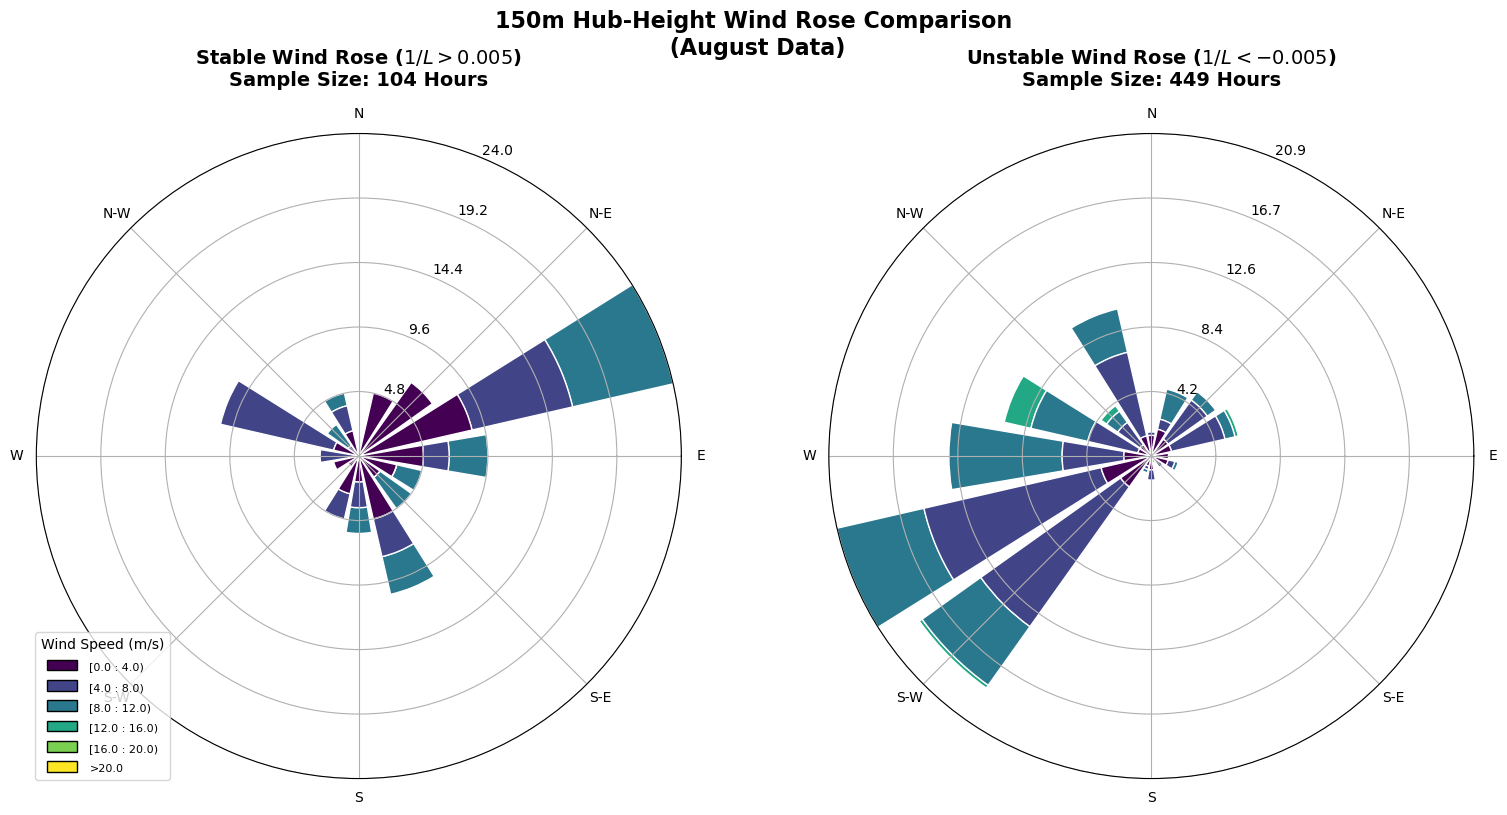

In [2]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from windrose import WindroseAxes
import matplotlib.cm as cm

# --- 1. Configuration & Geometry ---
base_path = '/data/nobackup/boland/'
# We typically pull the wind rose from a wake experiment to see the true operational layout
target_folder = 'exp1994_WFF'  
file_pattern = 'WRF/run/wrfout_d03_*-08-*'
TARGET_HEIGHT = 150.0

# Explicitly load your transect points to sample the local corridor wind climate
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

kappa = 0.40
g = 9.81
rho_cp = 1.225 * 1005.0

# --- 2. Build Transect Grid Indexes ---
all_files = sorted(glob.glob(f"{base_path}{target_folder}/{file_pattern}"))
files = [f for f in all_files if int(f.split('_')[-2].split('-')[-1]) <= 31]

nc_ref = Dataset(files[0])
transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    x_idx, y_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

# Lists to collect chronological hourly data instances
stable_wspds = []
stable_wdirs = []
unstable_wspds = []
unstable_wdirs = []

# --- 3. Extract and Regulate Stability-Stratified Vectors ---
print("Extracting directional vectors across files...")
for f in files:
    nc = Dataset(f)
    
    u_3d = getvar(nc, "ua", timeidx=None, units="m s-1", meta=False)
    v_3d = getvar(nc, "va", timeidx=None, units="m s-1", meta=False)
    height = getvar(nc, "height_agl", timeidx=None, units="m", meta=False)
    
    ust = getvar(nc, "UST", timeidx=None, meta=False)
    hfx = getvar(nc, "HFX", timeidx=None, meta=False)
    th2 = getvar(nc, "TH2", timeidx=None, meta=False)
    
    u_150m = interplevel(u_3d, height, TARGET_HEIGHT, meta=False)
    v_150m = interplevel(v_3d, height, TARGET_HEIGHT, meta=False)
    if u_150m.ndim == 2:
        u_150m = np.expand_dims(u_150m, axis=0)
        v_150m = np.expand_dims(v_150m, axis=0)
        ust = np.expand_dims(ust, axis=0)
        hfx = np.expand_dims(hfx, axis=0)
        th2 = np.expand_dims(th2, axis=0)
        
    num_times = u_150m.shape[0]
    
    for t in range(num_times):
        hfx_t = hfx[t, :, :]
        ust_t = ust[t, :, :]
        th2_t = th2[t, :, :]
        
        # Calculate hourly stability fields (1/L > 0 is STABLE)
        hfx_safe = np.where(hfx_t == 0.0, 1e-5, hfx_t)
        inv_L = -(kappa * g * hfx_safe) / (rho_cp * th2_t * (ust_t**3 + 1e-6))
        
        # Consistent sampling across transect
        transect_inv_L = np.array([inv_L[y, x] for y, x in zip(y_indices, x_indices)])
        mean_corridor_inv_L = np.mean(transect_inv_L)
        
        if mean_corridor_inv_L > 0.005 or mean_corridor_inv_L < -0.005:
            u_t = u_150m[t, :, :]
            v_t = v_150m[t, :, :]
            
            transect_u = np.array([u_t[y, x] for y, x in zip(y_indices, x_indices)])
            transect_v = np.array([v_t[y, x] for y, x in zip(y_indices, x_indices)])
            
            mean_u = np.mean(transect_u)
            mean_v = np.mean(transect_v)
            
            wspd_scalar = np.sqrt(mean_u**2 + mean_v**2)
            
            # Correct meteorological wind direction calculation
            wdir_deg = (270.0 - np.degrees(np.arctan2(mean_v, mean_u))) % 360.0
            
            if mean_corridor_inv_L > 0.005:
                stable_wspds.append(wspd_scalar)
                stable_wdirs.append(wdir_deg)
            elif mean_corridor_inv_L < -0.005:
                unstable_wspds.append(wspd_scalar)
                unstable_wdirs.append(wdir_deg)
                
    nc.close()

# --- 4. Plot Side-by-Side Binned Wind Roses ---
fig = plt.figure(figsize=(16, 8))

# Define matching, normalized wind speed bins for fair visual comparison
speed_bins = np.arange(0, 24, 4)

# Left Panel: Stable Regime Wind Rose
ax1 = fig.add_subplot(121, projection="windrose")
if len(stable_wdirs) > 0:
    ax1.bar(stable_wdirs, stable_wspds, bins=speed_bins, normed=True, opening=0.85, edgecolor='white', cmap=cm.viridis)
    ax1.set_title(f"Stable Wind Rose ($1/L > 0.005$)\nSample Size: {len(stable_wdirs)} Hours", fontsize=14, fontweight='bold', pad=15)
    ax1.set_legend(loc='lower left', bbox_transform=fig.transFigure, title="Wind Speed (m/s)", fontsize=11)
else:
    ax1.text(0.5, 0.5, "No Stable Hours Logged", transform=ax1.transAxes, ha="center")

# Right Panel: Unstable Regime Wind Rose
ax2 = fig.add_subplot(122, projection="windrose")
if len(unstable_wdirs) > 0:
    ax2.bar(unstable_wdirs, unstable_wspds, bins=speed_bins, normed=True, opening=0.85, edgecolor='white', cmap=cm.viridis)
    ax2.set_title(f"Unstable Wind Rose ($1/L < -0.005$)\nSample Size: {len(unstable_wdirs)} Hours", fontsize=14, fontweight='bold', pad=15)
else:
    ax2.text(0.5, 0.5, "No Unstable Hours Logged", transform=ax2.transAxes, ha="center")

plt.suptitle(f"150m Hub-Height Wind Rose Comparison\n (August Data)", 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig(f"{base_path}transect_stability_stratified_windroses.png", dpi=300)
plt.show()

Point by point stratification

In [ ]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from shapely.geometry import Polygon, Point
from scipy.spatial import KDTree
from matplotlib.patches import Patch

# --- 1. Geometry & Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1994 - no WF', '#1f77b4', '-'),
    ('exp1994_WF', '1994 - Current WF', '#ff7f0e', '-'),
    ('exp1994_WFF', '1994 - Future WF', '#2ca02c', '-'),
    ('experiment2', '2071 - no WF', '#1f77b4', '--'),
    ('exp2071_WF', '2071 - Current WF', '#ff7f0e', '--'),
    ('exp2071_WFF', '2071 - Future WF', '#2ca02c', '--')
]

file_pattern = 'WRF/run/wrfout_d03_*-08-*'
TARGET_HEIGHT = 150.0

# EXTENDED WAKE TRANSECT
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# --- 2. Load True Coordinate Layouts for Shading Determination ---
master_data = np.loadtxt('/data/nobackup/boland/exp2071_WFF/WRF/run/windturbines.txt')
current_data = np.loadtxt('/data/nobackup/boland/experiment2/WRF/run/windturbines.txt')

# Define strict geographical boundaries to filter exclusively for Belgian waters
BELGIAN_EEZ_POLY = Polygon([(2.20, 51.30), (2.40, 51.55), (2.90, 51.75), (3.35, 51.72), (3.15, 51.35)])

# Use the duplicate-filtering engine from the map script
DUPLICATE_THRESHOLD_DEG = 0.0032 
base_existing_coords = []
for lat, lon in zip(current_data[:, 0], current_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        if len(base_existing_coords) == 0:
            base_existing_coords.append([lat, lon])
        else:
            temp_tree = KDTree(base_existing_coords)
            distance, _ = temp_tree.query([lat, lon])
            if distance > DUPLICATE_THRESHOLD_DEG:
                base_existing_coords.append([lat, lon])

base_existing_coords = np.array(base_existing_coords)

# Isolate new/future coordinates
final_existing_lons = list(base_existing_coords[:, 1])
final_existing_lats = list(base_existing_coords[:, 0])
final_new_lons = []
final_new_lats = []

existing_tree = KDTree(base_existing_coords)
for lat, lon in zip(master_data[:, 0], master_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        distance, _ = existing_tree.query([lat, lon])
        if distance <= DUPLICATE_THRESHOLD_DEG:
            continue
        if lon < 2.68:  # West dividing line for PEZ
            if len(final_new_lons) > 0:
                new_tree = KDTree(np.column_stack((final_new_lats, final_new_lons)))
                dist_to_new, _ = new_tree.query([lat, lon])
                if dist_to_new <= DUPLICATE_THRESHOLD_DEG:
                    continue
            final_new_lons.append(lon)
            final_new_lats.append(lat)
        else:
            final_existing_lons.append(lon)
            final_existing_lats.append(lat)

# Build final Trees for profile cross-referencing
tree_existing = KDTree(np.column_stack((final_existing_lats, final_existing_lons)))
tree_new = KDTree(np.column_stack((final_new_lats, final_new_lons)))

# --- 3. Compute Transect Positions & Distances ---
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0]
nc_ref = Dataset(first_file)

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    y_idx, x_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

# Great circle distance calculation along transect path
d_lat = (transect_lats - START_LAT) * 111.0
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT))
distances_km = np.sqrt(d_lat**2 + d_lon**2)

# --- 4. Spatial Intersection Shading Masks ---
SHADING_RADIUS_DEG = 0.0225 

current_mask = []
future_mask = []
for lat, lon in zip(transect_lats, transect_lons):
    dist_ext, _ = tree_existing.query([lat, lon])
    dist_new, _ = tree_new.query([lat, lon])
    current_mask.append(dist_ext <= SHADING_RADIUS_DEG)
    future_mask.append(dist_new <= SHADING_RADIUS_DEG)

# --- 5. Hourly Processing & Point-by-Point Stability Stratification ---
kappa = 0.40
g = 9.81
rho_cp = 1.225 * 1005.0

# Store profiles as both a running sum array AND a sample-count array for each point
stable_profiles = {}
unstable_profiles = {}

for folder, label, color, linestyle in experiments:
    all_august_files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    files = [f for f in all_august_files if int(f.split('_')[-2].split('-')[-1]) <= 30]
    if not files: 
        continue
    
    print(f"Stratifying data point-by-point for: {label}...")
    
    # Track sums and hours independently for each of the 150 points
    stable_wspd_sum = np.zeros(NUM_POINTS)
    stable_point_hours = np.zeros(NUM_POINTS)   # Count array for denominator
    
    unstable_wspd_sum = np.zeros(NUM_POINTS)
    unstable_point_hours = np.zeros(NUM_POINTS) # Count array for denominator
    
    for f in files:
        nc = Dataset(f)
        
        # Pull 3D Wind parameters and interpolate to Hub Height (150m)
        u = getvar(nc, "ua", timeidx=None, units="m s-1", meta=False)
        v = getvar(nc, "va", timeidx=None, units="m s-1", meta=False)
        height = getvar(nc, "height_agl", timeidx=None, units="m", meta=False)
        wspd_3d = np.sqrt(u**2 + v**2)
        wspd_150m = interplevel(wspd_3d, height, TARGET_HEIGHT, meta=False)
        
        # Pull Surface Variables for Hourly Stability Assessment
        ust = getvar(nc, "UST", timeidx=None, meta=False)
        hfx = getvar(nc, "HFX", timeidx=None, meta=False)
        th2 = getvar(nc, "TH2", timeidx=None, meta=False)
        
        # Force 3D structure if only 1 hour exists
        if wspd_150m.ndim == 2:
            wspd_150m = np.expand_dims(wspd_150m, axis=0)
            ust = np.expand_dims(ust, axis=0)
            hfx = np.expand_dims(hfx, axis=0)
            th2 = np.expand_dims(th2, axis=0)
            
        num_times = wspd_150m.shape[0]
        
        for t in range(num_times):
            wspd_t = wspd_150m[t, :, :]
            ust_t = ust[t, :, :]
            hfx_t = hfx[t, :, :]
            th2_t = th2[t, :, :]
            
            # Calculate 2D Inverse Obukhov Length (1/L) for the whole grid
            hfx_safe = np.where(hfx_t == 0.0, 1e-5, hfx_t)
            inv_L = (kappa * g * hfx_safe) / (rho_cp * th2_t * (ust_t**3 + 1e-6))
            
            # Extract 1D profiles along the transect line for this specific hour
            transect_wspd = np.array([wspd_t[y, x] for y, x in zip(y_indices, x_indices)])
            transect_inv_L = np.array([inv_L[y, x] for y, x in zip(y_indices, x_indices)])
            
            # --- THE KEY FIX: CRITERIA EVALUATED PER POINT ---
            stable_mask = transect_inv_L > 0.005
            unstable_mask = transect_inv_L < -0.005
            
            # Accumulate values only at the specific points meeting the criteria
            stable_wspd_sum[stable_mask] += transect_wspd[stable_mask]
            stable_point_hours[stable_mask] += 1
            
            unstable_wspd_sum[unstable_mask] += transect_wspd[unstable_mask]
            unstable_point_hours[unstable_mask] += 1
                
        nc.close()
        
    # Divide element-by-element using safe arrays to prevent 0 division errors
    # If a point never saw a stable hour, it defaults to NaN (won't plot)
    with np.errstate(divide='ignore', invalid='ignore'):
        stable_profiles[folder] = np.where(stable_point_hours > 0, stable_wspd_sum / stable_point_hours, np.nan)
        unstable_profiles[folder] = np.where(unstable_point_hours > 0, unstable_wspd_sum / unstable_point_hours, np.nan)

# --- 6. Plotting Two Panels ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Define custom legend proxies for the background turbine zones
zone_handles = [
    Patch(facecolor='orange', alpha=0.15, label='Existing Turbines'),
    Patch(facecolor='green', alpha=0.12, label='Future Turbines')
]

stable_line_handles = []

# Map baseline references
stable_ref_1994 = stable_profiles.get('exp1994')
stable_ref_2071 = stable_profiles.get('experiment2')
unstable_ref_1994 = unstable_profiles.get('exp1994')
unstable_ref_2071 = unstable_profiles.get('experiment2')

for folder, label, color, linestyle in experiments:
    # Skip plotting the flat control baselines (removes blue lines)
    if folder in ['exp1994', 'experiment2']:
        continue
        
    # 1. Top Panel: STABLE WAKES
    if folder in stable_profiles:
        st_ref = stable_ref_1994 if '1994' in folder else stable_ref_2071
        if st_ref is not None:
            stable_diff = ((stable_profiles[folder] - st_ref) / st_ref) * 100
            st_label = f"{label}" if '1994' in folder else f"{label}"
            line, = ax1.plot(distances_km, stable_diff, label=st_label, color=color, linestyle=linestyle, linewidth=2.5)
            stable_line_handles.append(line)
            
    # 2. Bottom Panel: UNSTABLE WAKES
    if folder in unstable_profiles:
        unst_ref = unstable_ref_1994 if '1994' in folder else unstable_ref_2071
        if unst_ref is not None:
            unstable_diff = ((unstable_profiles[folder] - unst_ref) / unst_ref) * 100
            ax2.plot(distances_km, unstable_diff, color=color, linestyle=linestyle, linewidth=2.5)

# Style & Format BOTH panels dynamically
for ax in [ax1, ax2]:
    ax.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    ax.set_ylabel("Wind Speed Change (%)", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(0, max(distances_km))
    ax.set_ylim(-5, 5)  # Enforces a matching identical scale across both profiles
    ax.tick_params(labelsize=12)

# Specific Panel Annotations
ax1.set_title("Percentage Change in 150m Wind Speed under Stable Conditions ($1/L > 0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_title("Percentage Change in 150m Wind Speed under Unstable Conditions ($1/L < -0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=14, fontweight='bold', labelpad=8)

# Unified Legend Placement (Upper Right shifts it clear from crashing with profile curves)
ax1.legend(handles=stable_line_handles + zone_handles, loc='upper left', fontsize=13, frameon=True, ncol=3, shadow=True, facecolor='white')

# --- 7. Dynamic Shading Implementation ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
    if current_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')

# Master Title Block Formatting
plt.suptitle("Atmospheric Stability Analysis Along a SW-to-NE Transect Line\n"
             "Percentage Change in Wind Speed Relative to Corresponding Reference Climate Case", fontsize=17, fontweight='bold', y=0.97)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig(f"{base_path}transect_stability_stratified_wakes.png", dpi=300)
plt.show()

Extracting wind vectors specifically at Transect Point Index 75...


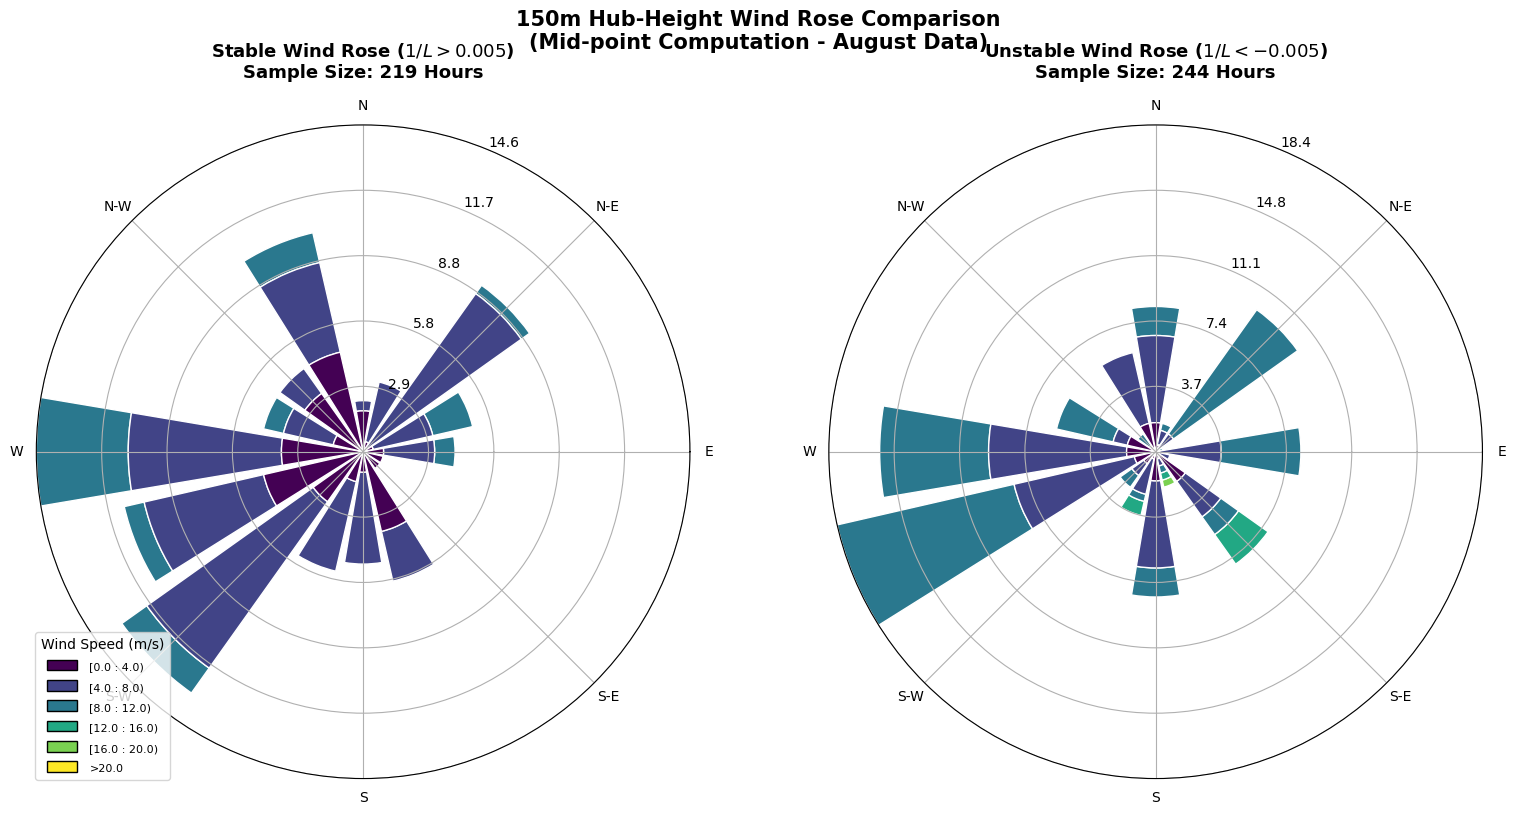

In [ ]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from windrose import WindroseAxes
import matplotlib.cm as cm

# --- 1. Configuration & Target Selection ---
base_path = '/data/nobackup/boland/'
# We'll use one representative run to sample the background wind climate
target_folder = 'exp1994_WFF'  
file_pattern = 'WRF/run/wrfout_d03_*-08-*'
TARGET_HEIGHT = 150.0

# Define your transect line (exactly matching your main script)
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# CHOOSE AN ANCHOR INDEX TO SAMPLE (e.g., index 75 is the center of the transect)
# This point sits right in the marine zone where stability transitions occur
ANCHOR_POINT_INDEX = 75

kappa = 0.40
g = 9.81
rho_cp = 1.225 * 1005.0

# --- 2. Build Grid Map ---
all_files = sorted(glob.glob(f"{base_path}{target_folder}/{file_pattern}"))
files = [f for f in all_files if int(f.split('_')[-2].split('-')[-1]) <= 30]

nc_ref = Dataset(files[0])
transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    y_idx, x_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

# Isolate the precise grid coordinate for our anchor point
anchor_x = x_indices[ANCHOR_POINT_INDEX]
anchor_y = y_indices[ANCHOR_POINT_INDEX]

# Arrays to gather historical data instances matching criteria at this point
stable_wspds = []
stable_wdirs = []
unstable_wspds = []
unstable_wdirs = []

# --- 3. Run Point-Specific Chronological Extraction ---
print(f"Extracting wind vectors specifically at Transect Point Index {ANCHOR_POINT_INDEX}...")

for f in files:
    nc = Dataset(f)
    
    u_3d = getvar(nc, "ua", timeidx=None, units="m s-1", meta=False)
    v_3d = getvar(nc, "va", timeidx=None, units="m s-1", meta=False)
    height = getvar(nc, "height_agl", timeidx=None, units="m", meta=False)
    
    ust = getvar(nc, "UST", timeidx=None, meta=False)
    hfx = getvar(nc, "HFX", timeidx=None, meta=False)
    th2 = getvar(nc, "TH2", timeidx=None, meta=False)
    
    u_150m = interplevel(u_3d, height, TARGET_HEIGHT, meta=False)
    v_150m = interplevel(v_3d, height, TARGET_HEIGHT, meta=False)
    
    if u_150m.ndim == 2:
        u_150m = np.expand_dims(u_150m, axis=0)
        v_150m = np.expand_dims(v_150m, axis=0)
        ust = np.expand_dims(ust, axis=0)
        hfx = np.expand_dims(hfx, axis=0)
        th2 = np.expand_dims(th2, axis=0)
        
    num_times = u_150m.shape[0]
    
    for t in range(num_times):
        # Extract surface parameters at our exact anchor grid cell
        hfx_cell = hfx[t, anchor_y, anchor_x]
        ust_cell = ust[t, anchor_y, anchor_x]
        th2_cell = th2[t, anchor_y, anchor_x]
        
        # Calculate local stability parameter
        hfx_safe = 1e-5 if hfx_cell == 0.0 else hfx_cell
        inv_L_cell = (kappa * g * hfx_safe) / (rho_cp * th2_cell * (ust_cell**3 + 1e-6))
        
        # Check if the local cell meets the criteria for stable or unstable
        if inv_L_cell > 0.005 or inv_L_cell < -0.005:
            u_val = u_150m[t, anchor_y, anchor_x]
            v_val = v_150m[t, anchor_y, anchor_x]
            
            # Calculate wind speed magnitude
            wspd = np.sqrt(u_val**2 + v_val**2)
            
            # Convert vectors to standard meteorological wind direction degrees (0 = North)
            wdir = np.degrees(np.arctan2(u_val, v_val)) + 180.0
            wdir = wdir % 360.0
            
            if inv_L_cell > 0.005:
                stable_wspds.append(wspd)
                stable_wdirs.append(wdir)
            else:
                unstable_wspds.append(wspd)
                unstable_wdirs.append(wdir)
                
    nc.close()

# --- 4. Plot Side-by-Side Normalized Wind Roses ---
fig = plt.figure(figsize=(16, 8))
speed_bins = np.arange(0, 24, 4) # Standardized wind speed color categories

# Left Panel: Stable
ax1 = fig.add_subplot(121, projection="windrose")
if stable_wdirs:
    ax1.bar(stable_wdirs, stable_wspds, bins=speed_bins, normed=True, opening=0.85, edgecolor='white', cmap=cm.viridis)
    ax1.set_title(f"Stable Wind Rose ($1/L > 0.005$)\nSample Size: {len(stable_wdirs)} Hours", fontsize=13, fontweight='bold', pad=15)
    # Global legend positioning
    ax1.set_legend(loc='lower left', bbox_transform=fig.transFigure, title="Wind Speed (m/s)", fontsize=11)
else:
    ax1.text(0.5, 0.5, "No Stable Hours at Anchor Point", transform=ax1.transAxes, ha="center")

# Right Panel: Unstable
ax2 = fig.add_subplot(122, projection="windrose")
if unstable_wdirs:
    ax2.bar(unstable_wdirs, unstable_wspds, bins=speed_bins, normed=True, opening=0.85, edgecolor='white', cmap=cm.viridis)
    ax2.set_title(f"Unstable Wind Rose ($1/L < -0.005$)\nSample Size: {len(unstable_wdirs)} Hours", fontsize=13, fontweight='bold', pad=15)
else:
    ax2.text(0.5, 0.5, "No Unstable Hours at Anchor Point", transform=ax2.transAxes, ha="center")

plt.suptitle(f"150m Hub-Height Wind Rose Comparison\n"
             f"(Midpoint Computation - August Data)", 
             fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig(f"{base_path}transect_point_stratified_windroses.png", dpi=300)
plt.show()

Extracting wind vectors specifically at Transect Point Index 75...


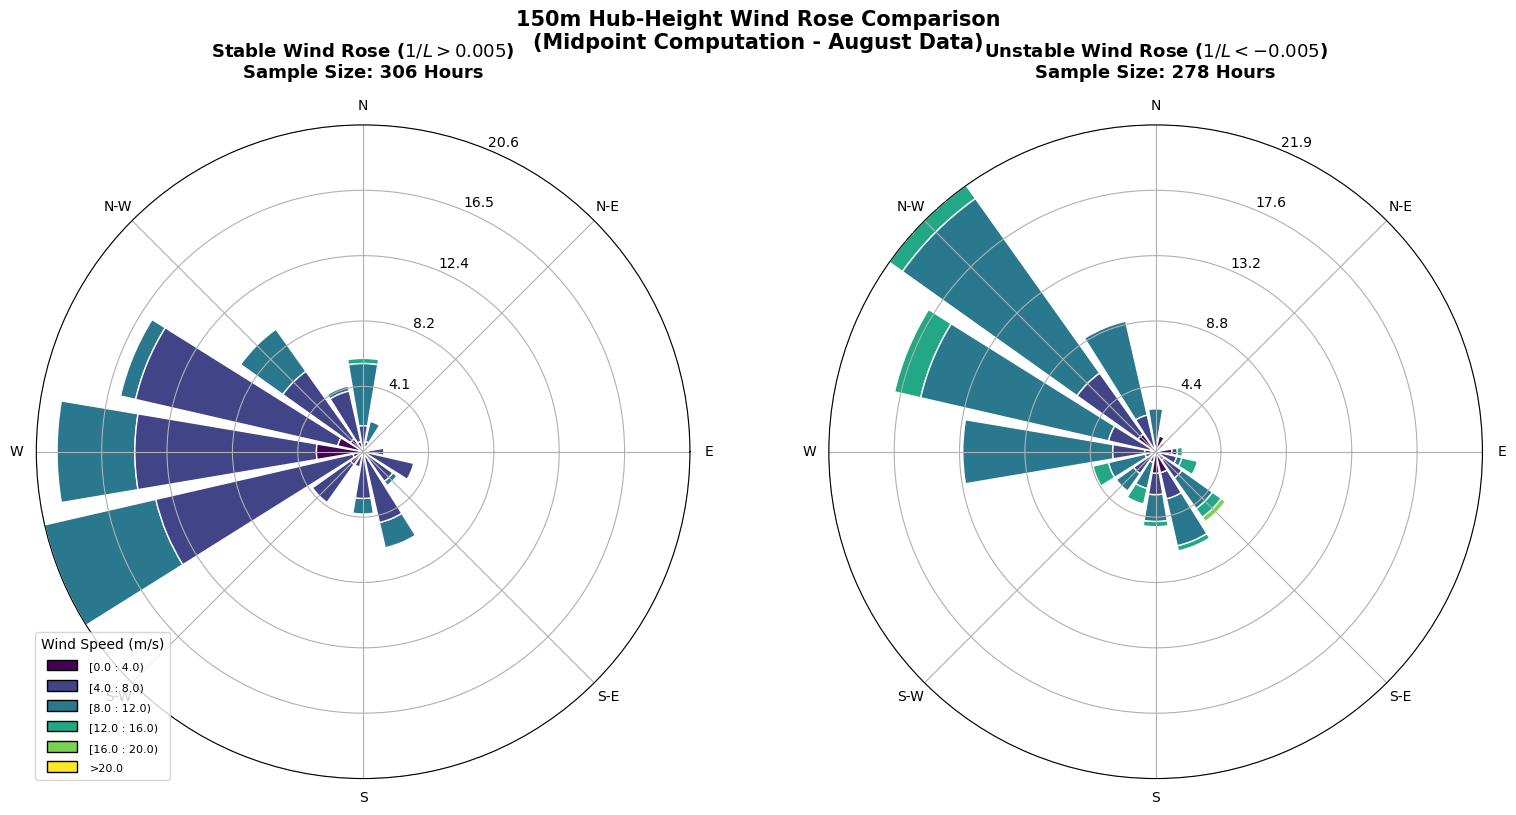

In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from windrose import WindroseAxes
import matplotlib.cm as cm

# --- 1. Configuration & Target Selection ---
base_path = '/data/nobackup/boland/'
# We'll use one representative run to sample the background wind climate
target_folder = 'exp2071_WFF'  
file_pattern = 'WRF/run/wrfout_d03_*-08-*'
TARGET_HEIGHT = 150.0

# Define your transect line (exactly matching your main script)
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# CHOOSE AN ANCHOR INDEX TO SAMPLE (e.g., index 75 is the center of the transect)
# This point sits right in the marine zone where stability transitions occur
ANCHOR_POINT_INDEX = 75

kappa = 0.40
g = 9.81
rho_cp = 1.225 * 1005.0

# --- 2. Build Grid Map ---
all_files = sorted(glob.glob(f"{base_path}{target_folder}/{file_pattern}"))
files = [f for f in all_files if int(f.split('_')[-2].split('-')[-1]) <= 30]

nc_ref = Dataset(files[0])
transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    y_idx, x_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

# Isolate the precise grid coordinate for our anchor point
anchor_x = x_indices[ANCHOR_POINT_INDEX]
anchor_y = y_indices[ANCHOR_POINT_INDEX]

# Arrays to gather historical data instances matching criteria at this point
stable_wspds = []
stable_wdirs = []
unstable_wspds = []
unstable_wdirs = []

# --- 3. Run Point-Specific Chronological Extraction ---
print(f"Extracting wind vectors specifically at Transect Point Index {ANCHOR_POINT_INDEX}...")

for f in files:
    nc = Dataset(f)
    
    u_3d = getvar(nc, "ua", timeidx=None, units="m s-1", meta=False)
    v_3d = getvar(nc, "va", timeidx=None, units="m s-1", meta=False)
    height = getvar(nc, "height_agl", timeidx=None, units="m", meta=False)
    
    ust = getvar(nc, "UST", timeidx=None, meta=False)
    hfx = getvar(nc, "HFX", timeidx=None, meta=False)
    th2 = getvar(nc, "TH2", timeidx=None, meta=False)
    
    u_150m = interplevel(u_3d, height, TARGET_HEIGHT, meta=False)
    v_150m = interplevel(v_3d, height, TARGET_HEIGHT, meta=False)
    
    if u_150m.ndim == 2:
        u_150m = np.expand_dims(u_150m, axis=0)
        v_150m = np.expand_dims(v_150m, axis=0)
        ust = np.expand_dims(ust, axis=0)
        hfx = np.expand_dims(hfx, axis=0)
        th2 = np.expand_dims(th2, axis=0)
        
    num_times = u_150m.shape[0]
    
    for t in range(num_times):
        # Extract surface parameters at our exact anchor grid cell
        hfx_cell = hfx[t, anchor_y, anchor_x]
        ust_cell = ust[t, anchor_y, anchor_x]
        th2_cell = th2[t, anchor_y, anchor_x]
        
        # Calculate local stability parameter
        hfx_safe = 1e-5 if hfx_cell == 0.0 else hfx_cell
        inv_L_cell = (kappa * g * hfx_safe) / (rho_cp * th2_cell * (ust_cell**3 + 1e-6))
        
        # Check if the local cell meets the criteria for stable or unstable
        if inv_L_cell > 0.005 or inv_L_cell < -0.005:
            u_val = u_150m[t, anchor_y, anchor_x]
            v_val = v_150m[t, anchor_y, anchor_x]
            
            # Calculate wind speed magnitude
            wspd = np.sqrt(u_val**2 + v_val**2)
            
            # Convert vectors to standard meteorological wind direction degrees (0 = North)
            wdir = np.degrees(np.arctan2(u_val, v_val)) + 180.0
            wdir = wdir % 360.0
            
            if inv_L_cell > 0.005:
                stable_wspds.append(wspd)
                stable_wdirs.append(wdir)
            else:
                unstable_wspds.append(wspd)
                unstable_wdirs.append(wdir)
                
    nc.close()

# --- 4. Plot Side-by-Side Normalized Wind Roses ---
fig = plt.figure(figsize=(16, 8))
speed_bins = np.arange(0, 24, 4) # Standardized wind speed color categories

# Left Panel: Stable
ax1 = fig.add_subplot(121, projection="windrose")
if stable_wdirs:
    ax1.bar(stable_wdirs, stable_wspds, bins=speed_bins, normed=True, opening=0.85, edgecolor='white', cmap=cm.viridis)
    ax1.set_title(f"Stable Wind Rose ($1/L > 0.005$)\nSample Size: {len(stable_wdirs)} Hours", fontsize=13, fontweight='bold', pad=15)
    # Global legend positioning
    ax1.set_legend(loc='lower left', bbox_transform=fig.transFigure, title="Wind Speed (m/s)", fontsize=11)
else:
    ax1.text(0.5, 0.5, "No Stable Hours at Anchor Point", transform=ax1.transAxes, ha="center")

# Right Panel: Unstable
ax2 = fig.add_subplot(122, projection="windrose")
if unstable_wdirs:
    ax2.bar(unstable_wdirs, unstable_wspds, bins=speed_bins, normed=True, opening=0.85, edgecolor='white', cmap=cm.viridis)
    ax2.set_title(f"Unstable Wind Rose ($1/L < -0.005$)\nSample Size: {len(unstable_wdirs)} Hours", fontsize=13, fontweight='bold', pad=15)
else:
    ax2.text(0.5, 0.5, "No Unstable Hours at Anchor Point", transform=ax2.transAxes, ha="center")

plt.suptitle(f"150m Hub-Height Wind Rose Comparison\n"
             f"(Midpoint Computation - August Data)", 
             fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig(f"{base_path}transect_point_stratified_windroses.png", dpi=300)
plt.show()

In [1]:
import glob
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from wrf import getvar, interplevel

# --- Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1994 - No wind farms'),
    ('exp1994_WF', '1994 - Current wind farms'),
    ('exp1994_WFF', '1994 - Future wind farms'),
    ('experiment2', '2071 - No wind farms'),
    ('exp2071_WF', '2071 - Current wind farms'),
    ('exp2071_WFF', '2071 - Future wind farms')
]

file_pattern = 'WRF/run/wrfout_d03_*-08-*'

BELGIAN_INDIVIDUAL_FARMS = {
    "C-Power": ([51.58, 2.90, 51.53, 3.03], 0.325),
    "Belwind": ([51.72, 2.78, 51.65, 2.84], 0.165),
    "Northwind": ([51.63, 2.86, 51.58, 2.93], 0.216),
    "Nobelwind": ([51.73, 2.82, 51.68, 2.87], 0.165),
    "Rentel": ([51.62, 2.76, 51.56, 2.84], 0.309),
    "Norther": ([51.55, 3.00, 51.49, 3.08], 0.370),
    "SeaMade-Seastar": ([51.65, 2.71, 51.60, 2.77], 0.252),
    "SeaMade-Mermaid": ([51.74, 2.72, 51.69, 2.77], 0.260),
    "PEZ-Noordhinder Noord": ([51.54, 2.44, 51.46, 2.58], 0.700),
    "PEZ-Noordhinder Zuid": ([51.47, 2.46, 51.37, 2.62], 1.400),
    "PEZ-Fairy Bank": ([51.44, 2.63, 51.36, 2.76], 1.400)
}

def wind_speed_to_capacity_factor(wspd):
    wspd_nodes = np.array([0.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 11.5, 25.0, 99.0])
    power_nodes = np.array([0.0, 0.0, 0.53, 1.17, 2.15, 3.54, 5.43, 7.91, 11.07, 14.12, 15.00, 15.00, 0.0])
    computed_power_mw = np.interp(wspd, wspd_nodes, power_nodes)
    cf = computed_power_mw / 15.0
    cf = np.where(wspd > 25.0, 0.0, cf)
    return np.clip(cf, 0.0, 1.0)

# Raw data storage for math operations
raw_energy = {farm: {} for farm in BELGIAN_INDIVIDUAL_FARMS.keys()}
raw_energy["NATIONAL TOTAL (GWh)"] = {}
raw_cf = {farm: {} for farm in BELGIAN_INDIVIDUAL_FARMS.keys()}

# --- Processing Loop ---
for folder, exp_name in experiments:
    files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    files = [f for f in files if int(f.split('_')[-2].split('-')[-1]) <= 30] # Keeping your 30-day index logic
    
    if not files:
        continue
    
    total_cf_accumulated = None
    total_hours = 0  

    for f in files:
        nc = Dataset(f)
        u = getvar(nc, "ua", timeidx=None, units="m s-1", meta=False)
        v = getvar(nc, "va", timeidx=None, units="m s-1", meta=False)
        height = getvar(nc, "height_agl", timeidx=None, units="m", meta=False)
        
        wspd = np.sqrt(u**2 + v**2)
        wspd_150m = interplevel(wspd, height, 150.0, meta=False)
        cf_snapshots = wind_speed_to_capacity_factor(wspd_150m)
        
        if cf_snapshots.ndim == 3:  
            hours_in_this_file = cf_snapshots.shape[0]
            cf_day_sum = np.sum(cf_snapshots, axis=0)
        else:  
            hours_in_this_file = 1
            cf_day_sum = cf_snapshots
            
        if total_cf_accumulated is None:
            total_cf_accumulated = cf_day_sum
            lats = getvar(nc, "XLAT", timeidx=0, meta=False)
            lons = getvar(nc, "XLONG", timeidx=0, meta=False)
        else:
            total_cf_accumulated += cf_day_sum
            
        total_hours += hours_in_this_file
        nc.close()
        
    mean_cf_grid = total_cf_accumulated / total_hours
    national_sum_gwh = 0.0

    for farm_name, (bbox, capacity_gw) in BELGIAN_INDIVIDUAL_FARMS.items():
        north, west, south, east = bbox
        spatial_mask = (lats >= south) & (lats <= north) & (lons >= west) & (lons <= east)
        
        if np.any(spatial_mask):
            farm_mean_cf = np.mean(mean_cf_grid[spatial_mask])
            farm_energy_gwh = farm_mean_cf * capacity_gw * total_hours
            
            raw_energy[farm_name][exp_name] = farm_energy_gwh
            raw_cf[farm_name][exp_name] = farm_mean_cf
            national_sum_gwh += farm_energy_gwh
        else:
            raw_energy[farm_name][exp_name] = 0.0
            raw_cf[farm_name][exp_name] = 0.0
            
    raw_energy["NATIONAL TOTAL (GWh)"][exp_name] = national_sum_gwh

# --- Convert to DataFrames for easy vector math ---
df_energy = pd.DataFrame(raw_energy)
df_cf = pd.DataFrame(raw_cf)

# --- Wake Deficit / Percentage Difference Analysis ---
wake_analysis_energy = {}
wake_analysis_cf = {}

# Define your evaluation pairs (Baseline vs Target Case)
analysis_pairs = [
    ('1994 - No wind farms', '1994 - Current wind farms', '1994 Current Wake Deficit (%)'),
    ('1994 - No wind farms', '1994 - Future wind farms', '1994 Future Wake Deficit (%)'),
    ('2071 - No wind farms', '2071 - Current wind farms', '2071 Current Wake Deficit (%)'),
    ('2071 - No wind farms', '2071 - Future wind farms', '2071 Future Wake Deficit (%)')
]

for baseline, case, column_name in analysis_pairs:
    # Formula: ((Case - Baseline) / Baseline) * 100
    pct_diff_energy = ((df_energy.loc[case] - df_energy.loc[baseline]) / df_energy.loc[baseline]) * 100
    wake_analysis_energy[column_name] = pct_diff_energy.round(2)
    
    # Note: National Total is omitted for CF since it's a farm-by-farm spatial metric
    pct_diff_cf = ((df_cf.loc[case] - df_cf.loc[baseline]) / df_cf.loc[baseline]) * 100
    wake_analysis_cf[column_name] = pct_diff_cf.round(2)

# Convert analysis dictionaries back to DataFrames
df_wake_energy = pd.DataFrame(wake_analysis_energy)
df_wake_cf = pd.DataFrame(wake_analysis_cf)

# --- Output Final Wake Effect Tables ---
print("\n" + "="*30 + " WAKE EFFECT ANALYSIS: ENERGY OUTPUT % CHANGE " + "="*30)
print("> Negative values indicate energy lost to cluster wake effects.")
print(df_wake_energy.to_markdown())

print("\n" + "="*30 + " WAKE EFFECT ANALYSIS: CAPACITY FACTOR % CHANGE " + "="*30)
print("> Represents the relative loss in turbine operational aerodynamic efficiency.")
print(df_wake_cf.to_markdown())


============================== WAKE EFFECT ANALYSIS: ENERGY OUTPUT % CHANGE ==============================
> Negative values indicate energy lost to cluster wake effects.
|                       |   1994 Current Wake Deficit (%) |   1994 Future Wake Deficit (%) |   2071 Current Wake Deficit (%) |   2071 Future Wake Deficit (%) |
|:----------------------|--------------------------------:|-------------------------------:|--------------------------------:|-------------------------------:|
| C-Power               |                          -31.07 |                         -46.22 |                          -32.64 |                         -48.9  |
| Belwind               |                          -32.15 |                         -48.91 |                          -32.47 |                         -50.12 |
| Northwind             |                          -33.6  |                         -48.36 |                          -34.75 |                         -50.35 |
| Nobelwind             |   

In [1]:
import glob
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from wrf import getvar, interplevel

# --- Configuration ---
base_path = '/data/nobackup/boland/'

# Streamlined to ONLY the 4 target combinations you need
experiments = [
    ('exp1994_WF', 'Current Farms - Current Climate'),
    ('exp1994_WFF', 'Future Farms - Current Climate'),
    ('exp2071_WF', 'Current Farms - Future Climate'),
    ('exp2071_WFF', 'Future Farms - Future Climate')
]

file_pattern = 'WRF/run/wrfout_d03_*-08-*'

BELGIAN_INDIVIDUAL_FARMS = {
    "C-Power": ([51.58, 2.90, 51.53, 3.03], 0.325),
    "Belwind": ([51.72, 2.78, 51.65, 2.84], 0.165),
    "Northwind": ([51.63, 2.86, 51.58, 2.93], 0.216),
    "Nobelwind": ([51.73, 2.82, 51.68, 2.87], 0.165),
    "Rentel": ([51.62, 2.76, 51.56, 2.84], 0.309),
    "Norther": ([51.55, 3.00, 51.49, 3.08], 0.370),
    "SeaMade-Seastar": ([51.65, 2.71, 51.60, 2.77], 0.252),
    "SeaMade-Mermaid": ([51.74, 2.72, 51.69, 2.77], 0.260),
    "PEZ-Noordhinder Noord": ([51.54, 2.44, 51.46, 2.58], 0.700),
    "PEZ-Noordhinder Zuid": ([51.47, 2.46, 51.37, 2.62], 1.400),
    "PEZ-Fairy Bank": ([51.44, 2.63, 51.36, 2.76], 1.400)
}

def wind_speed_to_capacity_factor(wspd):
    wspd_nodes = np.array([0.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 11.5, 25.0, 99.0])
    power_nodes = np.array([0.0, 0.0, 0.53, 1.17, 2.15, 3.54, 5.43, 7.91, 11.07, 14.12, 15.00, 15.00, 0.0])
    computed_power_mw = np.interp(wspd, wspd_nodes, power_nodes)
    cf = computed_power_mw / 15.0
    cf = np.where(wspd > 25.0, 0.0, cf)
    return np.clip(cf, 0.0, 1.0)

# Dictionary for raw total energy values
raw_energy = {farm: {} for farm in BELGIAN_INDIVIDUAL_FARMS.keys()}
raw_energy["NATIONAL TOTAL (GWh)"] = {}

# --- Processing Loop ---
for folder, exp_name in experiments:
    files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    files = [f for f in files if int(f.split('_')[-2].split('-')[-1]) <= 30]
    
    if not files:
        print(f"Warning: No files found for {exp_name}")
        continue
    
    print(f"\nStarting extraction for: {exp_name} ({len(files)} files found)")
    
    total_cf_accumulated = None
    total_hours = 0  

    for i, f in enumerate(files, 1):
        # Progress indicator so you know the script hasn't frozen
        print(f"   [{i}/{len(files)}] Processing file: {f.split('/')[-1]}", end='\r')
        
        nc = Dataset(f)
        u = getvar(nc, "ua", timeidx=None, units="m s-1", meta=False)
        v = getvar(nc, "va", timeidx=None, units="m s-1", meta=False)
        height = getvar(nc, "height_agl", timeidx=None, units="m", meta=False)
        
        wspd = np.sqrt(u**2 + v**2)
        wspd_150m = interplevel(wspd, height, 150.0, meta=False)
        cf_snapshots = wind_speed_to_capacity_factor(wspd_150m)
        
        if cf_snapshots.ndim == 3:  
            hours_in_this_file = cf_snapshots.shape[0]
            cf_day_sum = np.sum(cf_snapshots, axis=0)
        else:  
            hours_in_this_file = 1
            cf_day_sum = cf_snapshots
            
        if total_cf_accumulated is None:
            total_cf_accumulated = cf_day_sum
            lats = getvar(nc, "XLAT", timeidx=0, meta=False)
            lons = getvar(nc, "XLONG", timeidx=0, meta=False)
        else:
            total_cf_accumulated += cf_day_sum
            
        total_hours += hours_in_this_file
        nc.close()
        
    print(f"\n   Finished combining grids for {exp_name}.")
    mean_cf_grid = total_cf_accumulated / total_hours
    national_sum_gwh = 0.0

    for farm_name, (bbox, capacity_gw) in BELGIAN_INDIVIDUAL_FARMS.items():
        north, west, south, east = bbox
        spatial_mask = (lats >= south) & (lats <= north) & (lons >= west) & (lons <= east)
        
        if np.any(spatial_mask):
            farm_mean_cf = np.mean(mean_cf_grid[spatial_mask])
            farm_energy_gwh = farm_mean_cf * capacity_gw * total_hours
            
            raw_energy[farm_name][exp_name] = farm_energy_gwh
            national_sum_gwh += farm_energy_gwh
        else:
            raw_energy[farm_name][exp_name] = 0.0
            
    raw_energy["NATIONAL TOTAL (GWh)"][exp_name] = national_sum_gwh

# --- Convert to DataFrames for easy vector math ---
# Given your storage structure, transposing (.T) helps map the keys cleanly
df_energy = pd.DataFrame(raw_energy).T

# --- Calculate Percentage Differences ---

# 1. Wind Farm Expansion Effect under Current Climate (Current -> Future layout)
if 'Future Farms - Current Climate' in df_energy.columns and 'Current Farms - Current Climate' in df_energy.columns:
    df_energy['Expansion Impact (Current Climate) %'] = (
        (df_energy['Future Farms - Current Climate'] - df_energy['Current Farms - Current Climate']) 
        / df_energy['Current Farms - Current Climate']
    ) * 100

# 2. Wind Farm Expansion Effect under Future Climate (Current -> Future layout)
if 'Future Farms - Future Climate' in df_energy.columns and 'Current Farms - Future Climate' in df_energy.columns:
    df_energy['Expansion Impact (Future Climate) %'] = (
        (df_energy['Future Farms - Future Climate'] - df_energy['Current Farms - Future Climate']) 
        / df_energy['Current Farms - Future Climate']
    ) * 100

# 3. Climate Change Impact on Current Wind Farms (Current -> Future climate)
if 'Current Farms - Future Climate' in df_energy.columns and 'Current Farms - Current Climate' in df_energy.columns:
    df_energy['Climate Delta (Current Farms) %'] = (
        (df_energy['Current Farms - Future Climate'] - df_energy['Current Farms - Current Climate']) 
        / df_energy['Current Farms - Current Climate']
    ) * 100

# 4. Climate Change Impact on Future Wind Farms (Current -> Future climate)
if 'Future Farms - Future Climate' in df_energy.columns and 'Future Farms - Current Climate' in df_energy.columns:
    df_energy['Climate Delta (Future Farms) %'] = (
        (df_energy['Future Farms - Future Climate'] - df_energy['Future Farms - Current Climate']) 
        / df_energy['Future Farms - Current Climate']
    ) * 100

# --- Output Final Combined Table ---
print("\n" + "="*45 + " COUPLING ANALYSIS: ENERGY & IMPACT PERCENTAGES " + "="*45)
print(df_energy.round(2).to_markdown())


Starting extraction for: Current Farms - Current Climate (30 files found)
   [30/30] Processing file: wrfout_d03_1994-08-30_00:00:00
   Finished combining grids for Current Farms - Current Climate.

Starting extraction for: Future Farms - Current Climate (30 files found)
   [30/30] Processing file: wrfout_d03_1994-08-30_00:00:00
   Finished combining grids for Future Farms - Current Climate.

Starting extraction for: Current Farms - Future Climate (30 files found)
   [30/30] Processing file: wrfout_d03_2071-08-30_00:00:00
   Finished combining grids for Current Farms - Future Climate.

Starting extraction for: Future Farms - Future Climate (30 files found)
   [30/30] Processing file: wrfout_d03_2071-08-30_00:00:00
   Finished combining grids for Future Farms - Future Climate.

============================================= COUPLING ANALYSIS: ENERGY & IMPACT PERCENTAGES =============================================
|                       |   Current Farms - Current Climate |   Future F

In [1]:
import glob
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from wrf import getvar, interplevel

# --- Configuration ---
base_path = '/data/nobackup/boland/'

experiments = [
    ('exp1994_WF', 'Current Farms - Current Climate'),
    ('exp1994_WFF', 'Future Farms - Current Climate'),
    ('exp2071_WF', 'Current Farms - Future Climate'),
    ('exp2071_WFF', 'Future Farms - Future Climate')
]

file_pattern = 'WRF/run/wrfout_d03_*-08-*'

BELGIAN_INDIVIDUAL_FARMS = {
    "C-Power": ([51.58, 2.90, 51.53, 3.03], 0.325),
    "Belwind": ([51.72, 2.78, 51.65, 2.84], 0.165),
    "Northwind": ([51.63, 2.86, 51.58, 2.93], 0.216),
    "Nobelwind": ([51.73, 2.82, 51.68, 2.87], 0.165),
    "Rentel": ([51.62, 2.76, 51.56, 2.84], 0.309),
    "Norther": ([51.55, 3.00, 51.49, 3.08], 0.370),
    "SeaMade-Seastar": ([51.65, 2.71, 51.60, 2.77], 0.252),
    "SeaMade-Mermaid": ([51.74, 2.72, 51.69, 2.77], 0.260),
    "PEZ-Noordhinder Noord": ([51.54, 2.44, 51.46, 2.58], 0.700),
    "PEZ-Noordhinder Zuid": ([51.47, 2.46, 51.37, 2.62], 1.400),
    "PEZ-Fairy Bank": ([51.44, 2.63, 51.36, 2.76], 1.400)
}

def wind_speed_to_capacity_factor(wspd):
    wspd_nodes = np.array([0.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 11.5, 25.0, 99.0])
    power_nodes = np.array([0.0, 0.0, 0.53, 1.17, 2.15, 3.54, 5.43, 7.91, 11.07, 14.12, 15.00, 15.00, 0.0])
    computed_power_mw = np.interp(wspd, wspd_nodes, power_nodes)
    cf = computed_power_mw / 15.0
    cf = np.where(wspd > 25.0, 0.0, cf)
    return np.clip(cf, 0.0, 1.0)

# Dictionary for raw total energy values
raw_energy = {farm: {} for farm in BELGIAN_INDIVIDUAL_FARMS.keys()}
raw_energy["NATIONAL TOTAL (GWh)"] = {}

# --- Processing Loop ---
for folder, exp_name in experiments:
    files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    # FIXED: Updated to <= 31 to include August 31st
    files = [f for f in files if int(f.split('_')[-2].split('-')[-1]) <= 31]
    
    if not files:
        print(f"Warning: No files found for {exp_name}")
        continue
    
    print(f"\nStarting extraction for: {exp_name} ({len(files)} files found)")
    
    total_cf_accumulated = None
    total_hours = 0  

    for i, f in enumerate(files, 1):
        print(f"   [{i}/{len(files)}] Processing file: {f.split('/')[-1]}", end='\r')
        
        nc = Dataset(f)
        u = getvar(nc, "ua", timeidx=None, units="m s-1", meta=False)
        v = getvar(nc, "va", timeidx=None, units="m s-1", meta=False)
        height = getvar(nc, "height_agl", timeidx=None, units="m", meta=False)
        
        wspd = np.sqrt(u**2 + v**2)
        wspd_150m = interplevel(wspd, height, 150.0, meta=False)
        cf_snapshots = wind_speed_to_capacity_factor(wspd_150m)
        
        if cf_snapshots.ndim == 3:  
            hours_in_this_file = cf_snapshots.shape[0]
            cf_day_sum = np.sum(cf_snapshots, axis=0)
        else:  
            hours_in_this_file = 1
            cf_day_sum = cf_snapshots
            
        if total_cf_accumulated is None:
            total_cf_accumulated = cf_day_sum
            lats = getvar(nc, "XLAT", timeidx=0, meta=False)
            lons = getvar(nc, "XLONG", timeidx=0, meta=False)
        else:
            total_cf_accumulated += cf_day_sum
            
        total_hours += hours_in_this_file
        nc.close()
        
    print(f"\n   Finished combining grids for {exp_name}.")
    mean_cf_grid = total_cf_accumulated / total_hours
    national_sum_gwh = 0.0

    for farm_name, (bbox, capacity_gw) in BELGIAN_INDIVIDUAL_FARMS.items():
        # DYNAMIC FILTER: Skip future PEZ zones if analyzing "Current Farms" scenarios
        if "Current Farms" in exp_name and farm_name.startswith("PEZ-"):
            raw_energy[farm_name][exp_name] = 0.0
            continue
            
        north, west, south, east = bbox
        spatial_mask = (lats >= south) & (lats <= north) & (lons >= west) & (lons <= east)
        
        if np.any(spatial_mask):
            farm_mean_cf = np.mean(mean_cf_grid[spatial_mask])
            farm_energy_gwh = farm_mean_cf * capacity_gw * total_hours
            
            raw_energy[farm_name][exp_name] = farm_energy_gwh
            national_sum_gwh += farm_energy_gwh
        else:
            raw_energy[farm_name][exp_name] = 0.0
            
    raw_energy["NATIONAL TOTAL (GWh)"][exp_name] = national_sum_gwh

# --- Convert to DataFrames for easy vector math ---
df_energy = pd.DataFrame(raw_energy).T

# --- Calculate Percentage Differences ---
if 'Future Farms - Current Climate' in df_energy.columns and 'Current Farms - Current Climate' in df_energy.columns:
    df_energy['Expansion Impact (Current Climate) %'] = (
        (df_energy['Future Farms - Current Climate'] - df_energy['Current Farms - Current Climate']) 
        / df_energy['Current Farms - Current Climate']
    ) * 100

if 'Future Farms - Future Climate' in df_energy.columns and 'Current Farms - Future Climate' in df_energy.columns:
    df_energy['Expansion Impact (Future Climate) %'] = (
        (df_energy['Future Farms - Future Climate'] - df_energy['Current Farms - Future Climate']) 
        / df_energy['Current Farms - Future Climate']
    ) * 100

if 'Current Farms - Future Climate' in df_energy.columns and 'Current Farms - Current Climate' in df_energy.columns:
    df_energy['Climate Delta (Current Farms) %'] = (
        (df_energy['Current Farms - Future Climate'] - df_energy['Current Farms - Current Climate']) 
        / df_energy['Current Farms - Current Climate']
    ) * 100

if 'Future Farms - Future Climate' in df_energy.columns and 'Future Farms - Current Climate' in df_energy.columns:
    df_energy['Climate Delta (Future Farms) %'] = (
        (df_energy['Future Farms - Future Climate'] - df_energy['Future Farms - Current Climate']) 
        / df_energy['Future Farms - Current Climate']
    ) * 100

# --- Output Final Combined Table ---
print("\n" + "="*45 + " COUPLING ANALYSIS: ENERGY & IMPACT PERCENTAGES " + "="*45)
print(df_energy.round(2).to_markdown())


Starting extraction for: Current Farms - Current Climate (31 files found)
   [31/31] Processing file: wrfout_d03_1994-08-31_00:00:00
   Finished combining grids for Current Farms - Current Climate.

Starting extraction for: Future Farms - Current Climate (31 files found)
   [31/31] Processing file: wrfout_d03_1994-08-31_00:00:00
   Finished combining grids for Future Farms - Current Climate.

Starting extraction for: Current Farms - Future Climate (31 files found)
   [31/31] Processing file: wrfout_d03_2071-08-31_00:00:00
   Finished combining grids for Current Farms - Future Climate.

Starting extraction for: Future Farms - Future Climate (31 files found)
   [31/31] Processing file: wrfout_d03_2071-08-31_00:00:00
   Finished combining grids for Future Farms - Future Climate.

============================================= COUPLING ANALYSIS: ENERGY & IMPACT PERCENTAGES =============================================
|                       |   Current Farms - Current Climate |   Future F